<a href="https://colab.research.google.com/github/ryunyoung19/rocketpunch-analysis/blob/main/%ED%95%98%EC%9D%B4%EC%96%B4%ED%86%A1%20%ED%94%8C%EB%9E%AB%ED%8F%BC%20%ED%99%9C%EC%84%B1%ED%99%94%20%EC%A0%84%EB%9E%B5%20%EC%A0%9C%EC%95%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분석환경 세팅


In [ ]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 작업 디렉토리 지정하기
import os

# 한글 폰트 설치
!pip install koreanize-matplotlib
# 한글 폰트 호출
import koreanize_matplotlib

# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A)유저 분석
import glob
import re

# B)기업 분석
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

# C)공고 분석
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# A)유저 분석

## 유저 테이블

In [ ]:
# =========================================================================
# [1단계] 데이터 로드 및 기본 전처리
# =========================================================================
files_22 = sorted([
    f for f in glob.glob('/content/drive/MyDrive/log_2022_clean/*.csv')
    if 'log_2022_09.csv' not in f
])
files_23 = sorted(glob.glob('/content/drive/MyDrive/log_2023_clean/*.csv'))

def safe_read_csv(f):
    try:
        return pd.read_csv(f, on_bad_lines='skip', low_memory=False)
    except:
        return pd.read_csv(f, on_bad_lines='skip', engine='python')

df22 = pd.concat([safe_read_csv(f) for f in files_22], ignore_index=True)
df23 = pd.concat([safe_read_csv(f) for f in files_23], ignore_index=True)
df = pd.concat([df22, df23], ignore_index=True)

df['timestamp'] = pd.to_datetime(
    df['timestamp'].str.replace('"', '', regex=False).str.replace(' UTC', '', regex=False),
    errors='coerce'
)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['url_clean'] = df['URL'].str.split('?').str[0].str.strip().str.lstrip('/')
df['year_month'] = df['timestamp'].dt.to_period('M')  # 이 줄 추가

##월별 유저 감소 추이

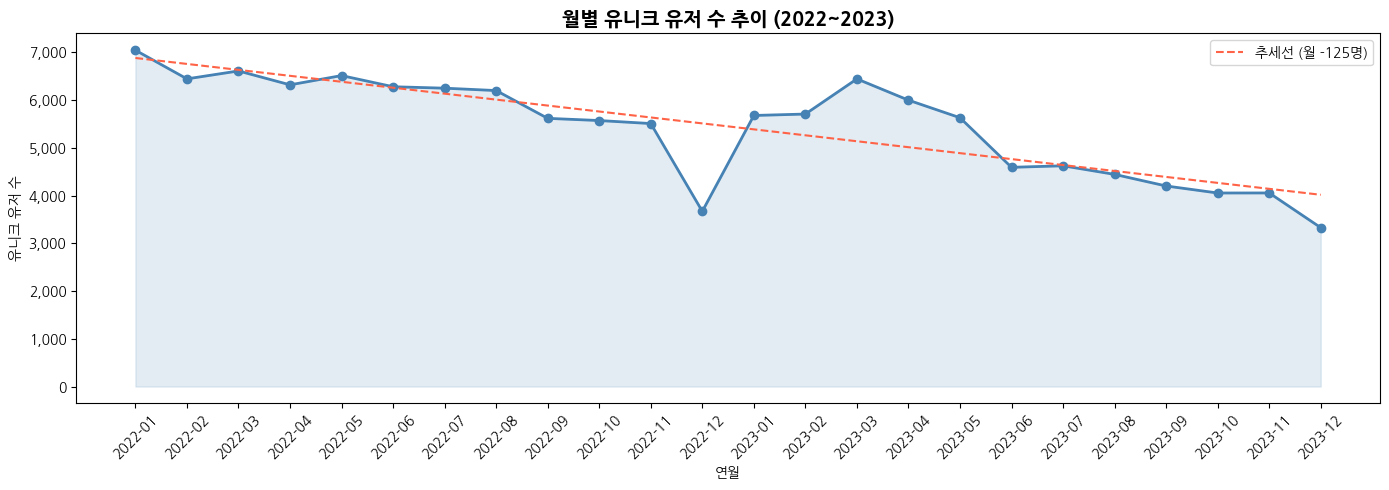

시작(2022-01): 7,046명
종료(2023-12): 3,329명
감소율: 52.8%


In [ ]:
monthly_users = df[df['timestamp'].dt.year >= 2022].groupby('year_month')['user_uuid'].nunique().reset_index()
monthly_users.columns = ['year_month', 'unique_users']
monthly_users['year_month_str'] = monthly_users['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_users['year_month_str'], monthly_users['unique_users'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_users['year_month_str'], monthly_users['unique_users'],
                alpha=0.15, color='steelblue')

import numpy as np
x = np.arange(len(monthly_users))
z = np.polyfit(x, monthly_users['unique_users'], 1)
p = np.poly1d(z)
ax.plot(monthly_users['year_month_str'], p(x),
        linestyle='--', color='tomato', linewidth=1.5, label=f'추세선 (월 {z[0]:+.0f}명)')

ax.set_title('월별 유니크 유저 수 추이 (2022~2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('연월')
ax.set_ylabel('유니크 유저 수')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"시작({monthly_users['year_month_str'].iloc[0]}): {monthly_users['unique_users'].iloc[0]:,}명")
print(f"종료({monthly_users['year_month_str'].iloc[-1]}): {monthly_users['unique_users'].iloc[-1]:,}명")
print(f"감소율: {(1 - monthly_users['unique_users'].iloc[-1] / monthly_users['unique_users'].iloc[0]) * 100:.1f}%")

## 유저 세그먼트

In [ ]:
# =========================================================================
# [2단계] URL 정규화 및 행동 분류
# =========================================================================

#19개
PASSIVE_NETWORK_URLS = {
    'people', 'search', 'suggest',
    'api/search/people/job_title', 'api/search/people/major', 'api/search/people/schools',
    'api/people/template',
    '@user_id', '@user_id/activities', '@user_id/preview',
    '@user_id/follower', '@user_id/following',
    'api/companies/company_id', 'api/companies/id',
    'api/companies/id/member_list', 'api/companies/id/reference_list',
    'api/companies/id/view',
    'api/post/id/template/viewers',
    '@user_id/notifications', 'api/users/notifications',
    'api/users/notifications/mark_read', 'api/users/notifications/mark_all_read',
    'companies/company_id', 'api/search/users', 'api/companies/id/bookmark',
}

#16개
ACTIVE_NETWORK_URLS = {
    'api/comapnies/id/follow_button', 'api/jobs/id/follow_button',
    'api/references', 'api/recommend_specialty',
    'api/companies/id/reference', 'api/companies/id/reference/id',
    'api/companies/id/reference/id/form',
    'api/users/id/request_button', 'api/users/id/reference/id/form',
    'api/users/id/reference/template',
    'api/users/id/friend_request_modal',
    '@user_id/job_offer/received', '@user_id/job_offer/sent',
    'api/job_offer/id/modal', 'api/job_offer/id/reject',
    'api/post/id', 'api/post/id/form',
}

#12개
PASSIVE_JOB_URLS = {
    'api/jobs/collections/template', 'api/jobs/id/other_jobs',
    'api/jobs/job_title', 'api/jobs/user_filter/id',
    'api/jobs/widget/widget_templates', 'api/search/people/job_title',
    'jobs/id/id_title', 'jobs', 'companies/company_id/jobs',
    'api/search/jobs/job_title', 'companies/company_id/jobs/job_title',
    'api/jobs/id/template_oneclick',
}

#11개
ACTIVE_JOB_URLS = {
    'api/jobs/id/apply/step1', 'api/jobs/id/apply/step2',
    'api/jobs/id/apply/step3', 'api/jobs/id/apply/step4',
    'api/jobs/id/bookmark', 'jobs/id/apply/step1',
    'jobs/id/apply/step2', 'jobs/id/apply/step3',
    'jobs/id/apply/step4', 'jobs/id/applications',
    'jobs/id/apply/complete',
}

def normalize_url(url):
    if not isinstance(url, str):
        return None
    u = url.lower().strip()
    u = re.sub(r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}', 'id', u)
    u = re.sub(r'(?<=/)\d+(?=/|$)', 'id', u)
    u = re.sub(r'^@[^/]+', '@user_id', u)
    return u

df['url_normalized'] = df['url_clean'].apply(normalize_url)
df['is_passive_network'] = df['url_normalized'].isin(PASSIVE_NETWORK_URLS)
df['is_active_network']  = df['url_normalized'].isin(ACTIVE_NETWORK_URLS)
df['is_passive_job']     = df['url_normalized'].isin(PASSIVE_JOB_URLS)
df['is_active_job']      = df['url_normalized'].isin(ACTIVE_JOB_URLS)

print(f"전체 로그: {len(df):,}행 / {df['user_uuid'].nunique():,}명")

# =========================================================================
# [3단계] 유저별 원본값 집계
# =========================================================================

analysis_date = pd.Timestamp('2023-12-31')

df_raw = (
    df.groupby('user_uuid')
    .agg(
        last_visit          = ('date', 'max'),
        passive_network_raw = ('is_passive_network', 'sum'),
        active_network_raw  = ('is_active_network',  'sum'),
        passive_job_raw     = ('is_passive_job',     'sum'),
        active_job_raw      = ('is_active_job',      'sum'),
    )
    .reset_index()
)

df_raw['R_raw'] = (analysis_date - df_raw['last_visit']).dt.days

print(f"유저 수: {len(df_raw):,}명")

# =========================================================================
# [4단계] 5분위 스코어링 (1~5점)
# =========================================================================

def make_score(series, ascending=True):
    labels = [1, 2, 3, 4, 5] if ascending else [5, 4, 3, 2, 1]
    return pd.qcut(series.rank(method='first'), q=5, labels=labels).astype(float)

df_raw['R_score']               = make_score(df_raw['R_raw'], ascending=False)
df_raw['passive_network_score'] = make_score(df_raw['passive_network_raw'])
df_raw['active_network_score']  = make_score(df_raw['active_network_raw'])
df_raw['passive_job_score']     = make_score(df_raw['passive_job_raw'])
df_raw['active_job_score']      = make_score(df_raw['active_job_raw'])

전체 로그: 15,235,505행 / 21,221명
유저 수: 21,221명


=== 네트워킹 세그먼트 분포 ===
                 count     %
network_segment             
1. 핵심 네트워킹        6539  30.8
2. 탐색 네트워킹        3076  14.5
3. 목적 네트워킹         255   1.2
4. 잠수 관찰자         2863  13.5
5. 휴면 유저          3329  15.7
6. 이탈 유저          5159  24.3

=== 세그먼트별 평균 점수 ===
                 R_score  passive_network_score  active_network_score
network_segment                                                      
1. 핵심 네트워킹          4.18                   4.36                  4.56
2. 탐색 네트워킹          3.91                   3.61                  2.56
3. 목적 네트워킹          3.84                   1.92                  4.10
4. 잠수 관찰자           3.71                   1.59                  1.80
5. 휴면 유저            1.65                   3.53                  3.41
6. 이탈 유저            1.40                   1.41                  1.64


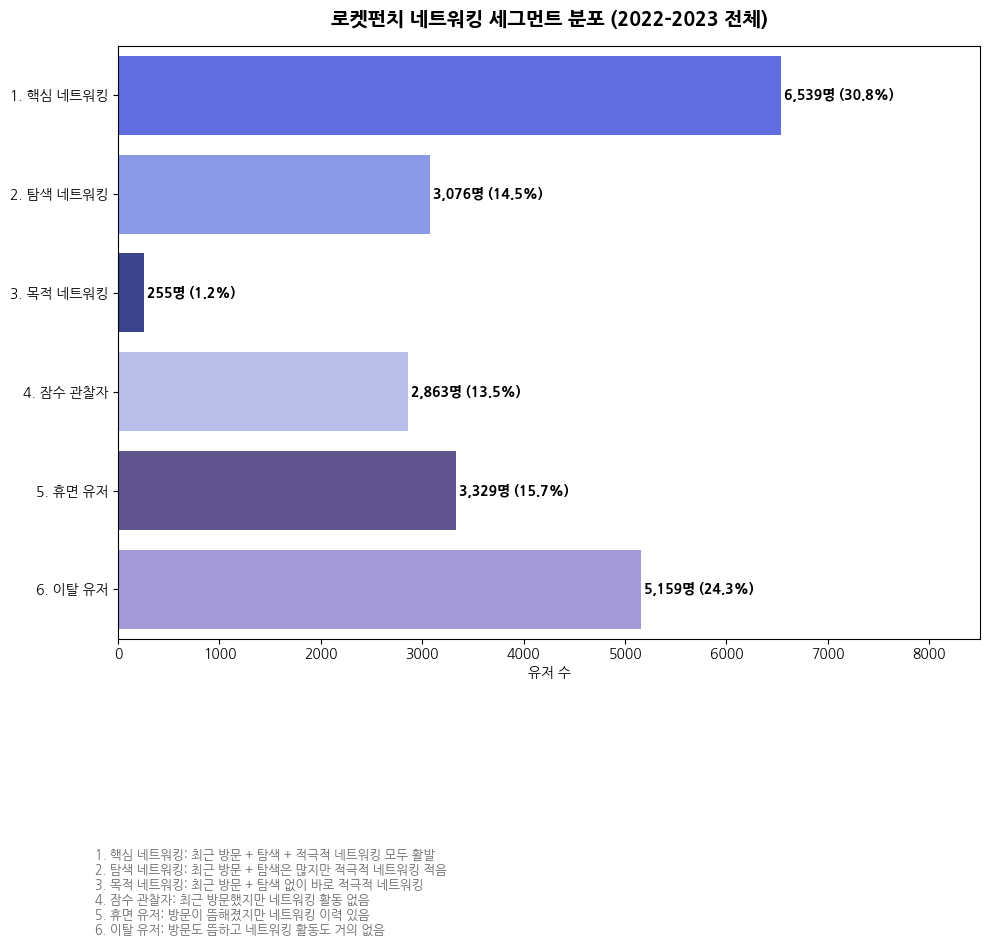

In [ ]:
# =========================================================================
# [5단계] 네트워킹 세그먼트 + 시각화
# =========================================================================

def assign_network_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_network_score'] >= 3.0
    is_high_active  = row['active_network_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 핵심 네트워킹'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색 네트워킹'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적 네트워킹'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 잠수 관찰자'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저'
    else:
        return '6. 이탈 유저'

df_raw['network_segment'] = df_raw.apply(assign_network_segment, axis=1)

net_counts = df_raw['network_segment'].value_counts().sort_index()
net_pct    = df_raw['network_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 네트워킹 세그먼트 분포 ===")
print(pd.DataFrame({'count': net_counts, '%': net_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('network_segment')[
    ['R_score', 'passive_network_score', 'active_network_score']
].mean().round(2))

color_map_net = {
    '1. 핵심 네트워킹':   '#4B5DF5',  # 메인 브랜드 블루
    '2. 탐색 네트워킹':   '#7B8FF7',  # 밝은 블루
    '3. 목적 네트워킹':   '#2E3A99',  # 진한 네이비
    '4. 잠수 관찰자':     '#B0B8F0',  # 연한 라벤더
    '5. 휴면 유저':       '#5B4B99',  # 블루-퍼플
    '6. 이탈 유저':       '#9C8FE0',  # 연한 퍼플
}

segment_desc_net = {
    '1. 핵심 네트워킹': '최근 방문 + 탐색 + 적극적 네트워킹 모두 활발',
    '2. 탐색 네트워킹':     '최근 방문 + 탐색은 많지만 적극적 네트워킹 적음',
    '3. 목적 네트워킹':  '최근 방문 + 탐색 없이 바로 적극적 네트워킹',
    '4. 잠수 관찰자':           '최근 방문했지만 네트워킹 활동 없음',
    '5. 휴면 유저':            '방문이 뜸해졌지만 네트워킹 이력 있음',
    '6. 이탈 유저':            '방문도 뜸하고 네트워킹 활동도 거의 없음',
}


fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=net_counts.values, y=net_counts.index,
            hue=net_counts.index, palette=color_map_net, legend=False, ax=ax)
total = net_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, net_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 네트워킹 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_net.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

=== 구직활동 세그먼트 분포 ===
             count     %
job_segment             
1. 핵심 구직자     6323  29.8
2. 탐색 구직자     3068  14.5
3. 목적 구직자      118   0.6
4. 잠수 관찰자     3224  15.2
5. 휴면 유저      3543  16.7
6. 이탈 유저      4945  23.3

=== 세그먼트별 평균 점수 ===
             R_score  passive_job_score  active_job_score
job_segment                                              
1. 핵심 구직자       4.15               4.38              4.56
2. 탐색 구직자       3.98               3.53              2.43
3. 목적 구직자       3.79               1.93              4.11
4. 잠수 관찰자       3.74               1.58              1.76
5. 휴면 유저        1.62               3.61              3.54
6. 이탈 유저        1.41               1.42              1.76


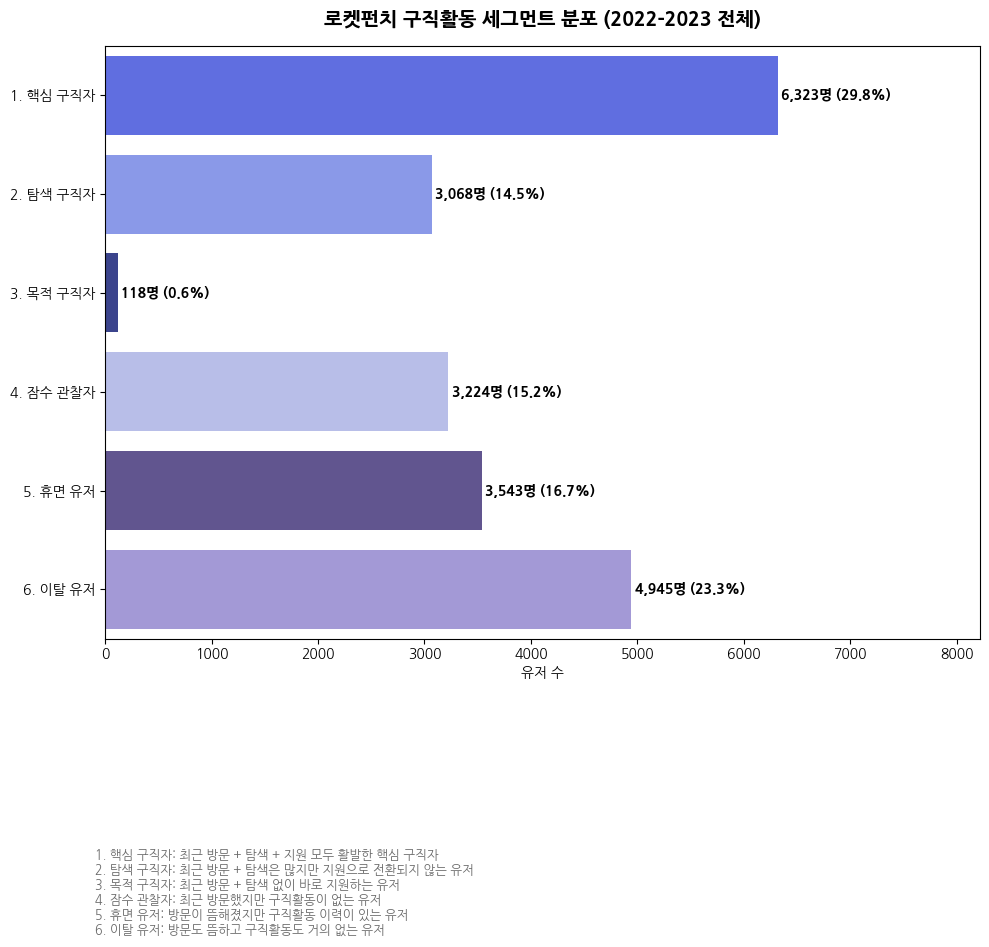

In [ ]:
# =========================================================================
# [6단계] 구직활동 세그먼트 + 시각화
# =========================================================================

def assign_job_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_job_score'] >= 3.0
    is_high_active  = row['active_job_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 핵심 구직자'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색 구직자'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적 구직자'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 잠수 관찰자'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저'
    else:
        return '6. 이탈 유저'

df_raw['job_segment'] = df_raw.apply(assign_job_segment, axis=1)

job_counts = df_raw['job_segment'].value_counts().sort_index()
job_pct    = df_raw['job_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 구직활동 세그먼트 분포 ===")
print(pd.DataFrame({'count': job_counts, '%': job_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('job_segment')[
    ['R_score', 'passive_job_score', 'active_job_score']
].mean().round(2))

color_map_job = {
    '1. 핵심 구직자':   '#4B5DF5',  # 메인 브랜드 블루
    '2. 탐색 구직자':   '#7B8FF7',  # 밝은 블루
    '3. 목적 구직자':   '#2E3A99',  # 진한 네이비
    '4. 잠수 관찰자':   '#B0B8F0',  # 연한 라벤더
    '5. 휴면 유저':     '#5B4B99',  # 블루-퍼플
    '6. 이탈 유저':     '#9C8FE0',  # 연한 퍼플
}

segment_desc_job = {
    '1. 핵심 구직자':      '최근 방문 + 탐색 + 지원 모두 활발한 핵심 구직자',
    '2. 탐색 구직자':     '최근 방문 + 탐색은 많지만 지원으로 전환되지 않는 유저',
    '3. 목적 구직자': '최근 방문 + 탐색 없이 바로 지원하는 유저',
    '4. 잠수 관찰자':        '최근 방문했지만 구직활동이 없는 유저',
    '5. 휴면 유저':         '방문이 뜸해졌지만 구직활동 이력이 있는 유저',
    '6. 이탈 유저':         '방문도 뜸하고 구직활동도 거의 없는 유저',
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=job_counts.values, y=job_counts.index,
            hue=job_counts.index, palette=color_map_job, legend=False, ax=ax)
total = job_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, job_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 구직활동 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_job.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

- 네트워킹·구직활동 세그먼트는 분류 기준이 동일해 분포가 유사한 것뿐 아니라, 마지막 네트워킹 활동일과 마지막 구직 활동일을 각각 기준으로 분리해 재분류했을 때도 분포가 거의 동일하게 나타났다. 이는 두 활동의 마지막 시점이 유저별로 거의 일치함을 의미하며, 유저들이 사이트 방문 시 네트워킹과 구직 탐색/지원을 한 세션 안에서 함께 수행하는 경향이 있음을 시사한다.
- 따라서 두 세그먼트의 실질적 차이는 최근성이 아닌 영역별 활동 강도(passive vs active)에서 발생한다.

## 세그먼트별 유지율

=== 네트워킹 세그먼트별 월별 잔류율 ===
                   1. 핵심 네트워킹  2. 탐색 네트워킹  3. 목적 네트워킹  4. 잠수 관찰자  5. 휴면 유저  \
months_since_join                                                            
0                       100.0       100.0       100.0      100.0     100.0   
1                        76.6        60.7        54.9       26.4      68.7   
2                        69.1        52.6        37.3       18.2      52.3   
3                        61.7        45.7        16.9       15.2      43.6   
4                        57.5        44.4        16.9       12.3      36.3   
5                        53.0        41.6        18.4       11.8      31.6   
6                        50.8        39.2        16.1       11.0      29.3   
7                        48.8        37.2        14.5        9.2      25.8   
8                        45.6        33.8        13.7        8.9      20.5   
9                        45.0        31.4        11.0        8.6      17.9   
10                       42.0        3

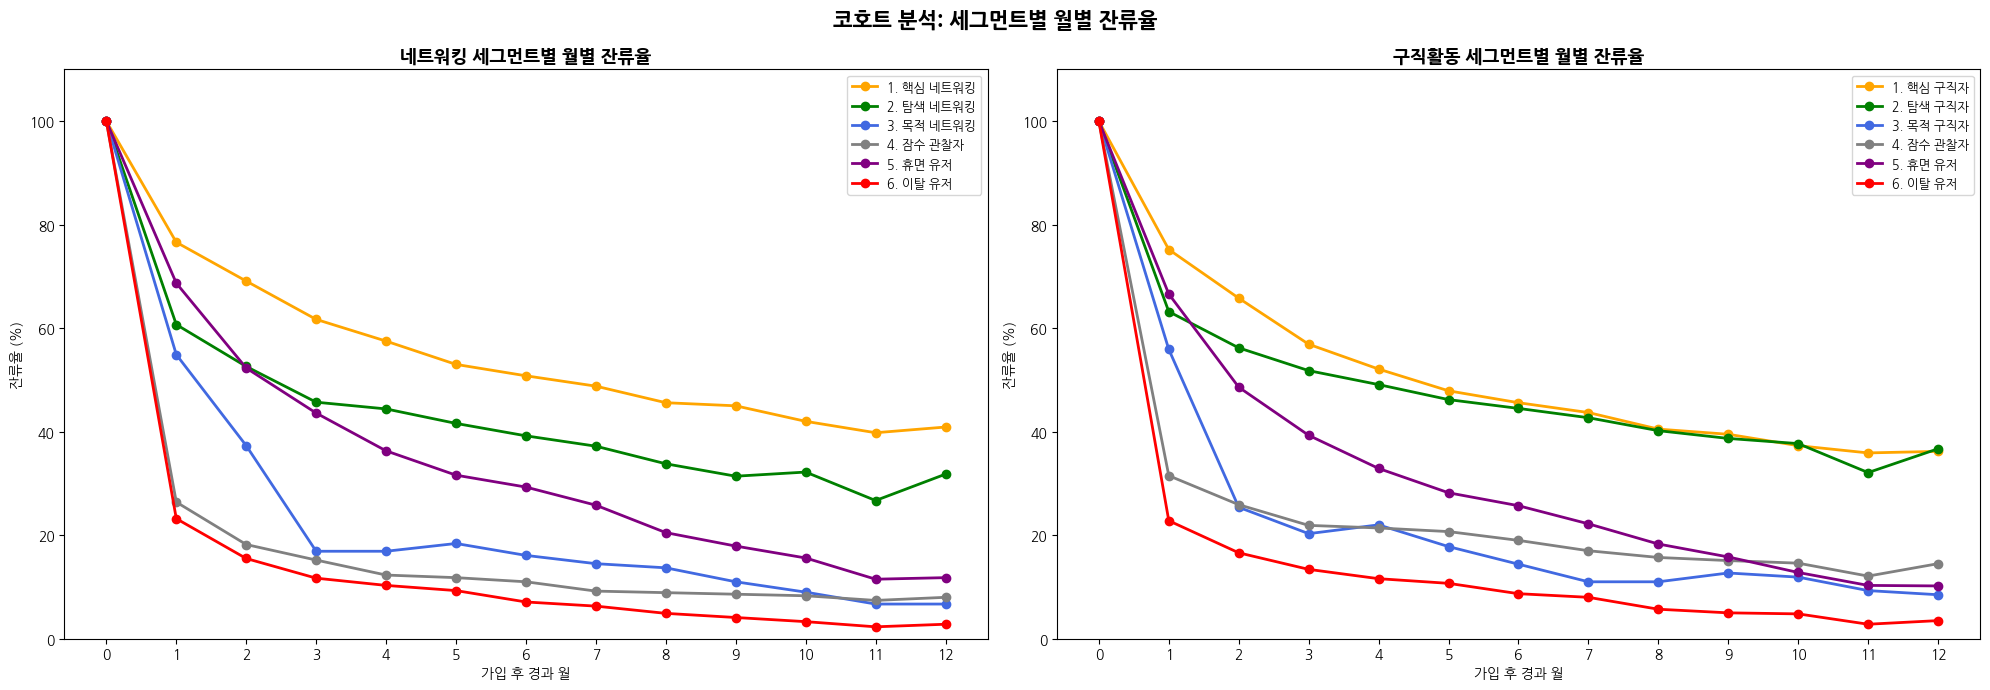

In [ ]:
# =========================================================================
# [코호트 분석] 세그먼트별 월별 잔류율
# =========================================================================

seg_df = df_raw[['user_uuid', 'network_segment', 'job_segment']].drop_duplicates('user_uuid')

# 유저별 첫 방문 월
first_visit = (
    df.groupby('user_uuid')['date']
    .min()
    .reset_index()
)
first_visit.columns = ['user_uuid', 'first_date']
first_visit['cohort_month'] = pd.to_datetime(first_visit['first_date']).dt.to_period('M')

# 유저별 월별 활동
user_monthly = (
    df.groupby(['user_uuid', df['date'].dt.to_period('M')])
    .size()
    .reset_index()
)
user_monthly.columns = ['user_uuid', 'activity_month', 'log_count']
user_monthly = user_monthly.merge(first_visit[['user_uuid', 'cohort_month']], on='user_uuid', how='left')
user_monthly = user_monthly.merge(seg_df, on='user_uuid', how='left')
user_monthly['months_since_join'] = (
    user_monthly['activity_month'] - user_monthly['cohort_month']
).apply(lambda x: x.n)
user_monthly = user_monthly[user_monthly['months_since_join'].between(0, 12)]

# 잔류율 계산 함수
def calc_monthly_retention(data, col, segments):
    ret = {}
    for label, seg in segments.items():
        group = data[data[col] == seg]
        total = group[group['months_since_join'] == 0]['user_uuid'].nunique()
        if total > 0:
            ret[label] = (
                group.groupby('months_since_join')['user_uuid']
                .nunique()
                .div(total)
                .mul(100)
                .round(1)
            )
    return pd.DataFrame(ret).fillna(0)

net_segments = {
    '1. 핵심 네트워킹': '1. 핵심 네트워킹',
    '2. 탐색 네트워킹': '2. 탐색 네트워킹',
    '3. 목적 네트워킹': '3. 목적 네트워킹',
    '4. 잠수 관찰자':   '4. 잠수 관찰자',
    '5. 휴면 유저':     '5. 휴면 유저',
    '6. 이탈 유저':     '6. 이탈 유저',
}

job_segments = {
    '1. 핵심 구직자': '1. 핵심 구직자',
    '2. 탐색 구직자': '2. 탐색 구직자',
    '3. 목적 구직자': '3. 목적 구직자',
    '4. 잠수 관찰자': '4. 잠수 관찰자',
    '5. 휴면 유저':   '5. 휴면 유저',
    '6. 이탈 유저':   '6. 이탈 유저',
}

net_ret_df = calc_monthly_retention(user_monthly, 'network_segment', net_segments)
job_ret_df = calc_monthly_retention(user_monthly, 'job_segment', job_segments)

print("=== 네트워킹 세그먼트별 월별 잔류율 ===")
print(net_ret_df)
print("\n=== 구직활동 세그먼트별 월별 잔류율 ===")
print(job_ret_df)

# 시각화
colors = ['orange', 'green', 'royalblue', 'gray', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for col, color in zip(net_ret_df.columns, colors):
    axes[0].plot(net_ret_df.index, net_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[0].set_title('네트워킹 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가입 후 경과 월')
axes[0].set_ylabel('잔류율 (%)')
axes[0].set_xticks(range(0, 13))
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

for col, color in zip(job_ret_df.columns, colors):
    axes[1].plot(job_ret_df.index, job_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[1].set_title('구직활동 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가입 후 경과 월')
axes[1].set_ylabel('잔류율 (%)')
axes[1].set_xticks(range(0, 13))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)

plt.suptitle('코호트 분석: 세그먼트별 월별 잔류율', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

=== 네트워킹 세그먼트별 월별 잔류율 ===
                   1. 핵심 네트워킹  2. 탐색 네트워킹  3. 목적 네트워킹  4. 잠수 관찰자  5. 휴면 유저  \
months_since_join                                                            
0                       100.0       100.0       100.0      100.0     100.0   
1                        73.8        59.2        49.5       28.4      68.6   
2                        69.1        54.7        40.6       24.3      53.7   
3                        65.4        49.5        20.8       20.8      45.7   
4                        64.5        50.0        26.7       17.8      38.3   
5                        61.5        47.6        30.7       17.7      33.3   
6                        60.3        45.4        28.7       17.3      30.9   
7                        59.2        43.3        28.7       15.2      27.2   
8                        56.5        39.7        25.7       15.9      21.6   
9                        57.1        37.1        21.8       15.1      18.9   
10                       54.2        3

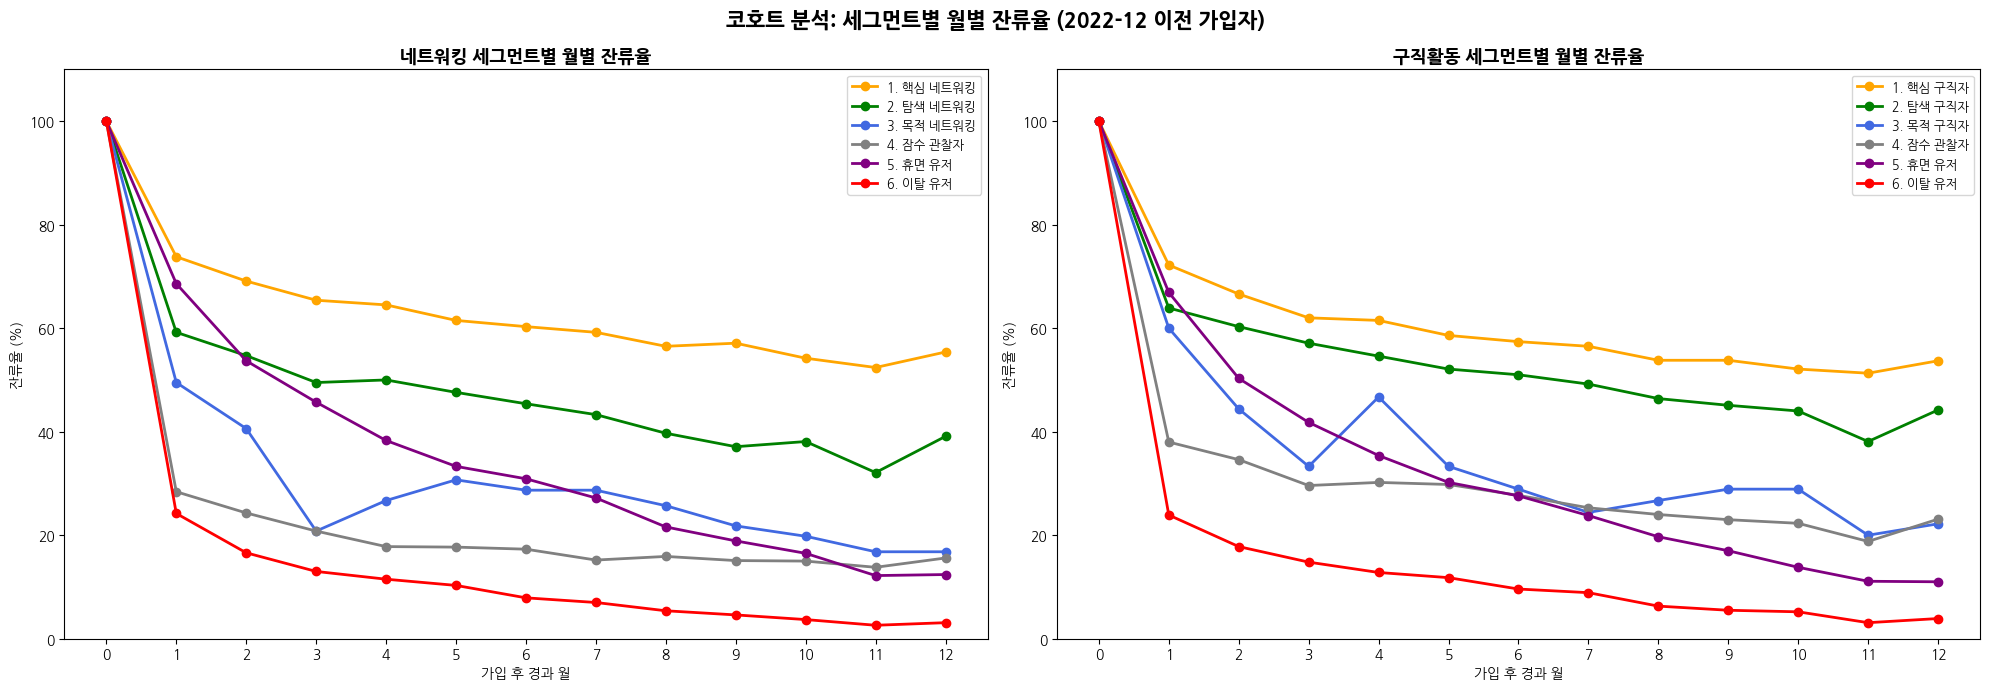

In [ ]:
# 12개월 추적 가능한 코호트만 사용 (2022-12 이전 가입자)
valid_cohorts = first_visit[
    first_visit['cohort_month'] <= pd.Period('2022-12', 'M')
]['user_uuid']

user_monthly_filtered = user_monthly[user_monthly['user_uuid'].isin(valid_cohorts)]

net_ret_df = calc_monthly_retention(user_monthly_filtered, 'network_segment', net_segments)
job_ret_df = calc_monthly_retention(user_monthly_filtered, 'job_segment', job_segments)

print("=== 네트워킹 세그먼트별 월별 잔류율 ===")
print(net_ret_df)
print("\n=== 구직활동 세그먼트별 월별 잔류율 ===")
print(job_ret_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

colors = ['orange', 'green', 'royalblue', 'gray', 'purple', 'red']

for col, color in zip(net_ret_df.columns, colors):
    axes[0].plot(net_ret_df.index, net_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[0].set_title('네트워킹 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가입 후 경과 월')
axes[0].set_ylabel('잔류율 (%)')
axes[0].set_xticks(range(0, 13))
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

for col, color in zip(job_ret_df.columns, colors):
    axes[1].plot(job_ret_df.index, job_ret_df[col],
                 marker='o', linewidth=2, color=color, label=col, markersize=6)
axes[1].set_title('구직활동 세그먼트별 월별 잔류율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가입 후 경과 월')
axes[1].set_ylabel('잔류율 (%)')
axes[1].set_xticks(range(0, 13))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)

plt.suptitle('코호트 분석: 세그먼트별 월별 잔류율 (2022-12 이전 가입자)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.네트워킹 & 구직활동 상관분석

=== 구직활동 × 네트워킹 세그먼트 교차표 ===


network_segment,1. 핵심 네트워킹,2. 탐색 네트워킹,3. 목적 네트워킹,4. 잠수 관찰자,5. 휴면 유저,6. 이탈 유저
job_segment,,,,,,
1. 핵심 구직자,5274,745,148,156,0,0
2. 탐색 구직자,1029,1482,36,521,0,0
3. 목적 구직자,27,21,26,44,0,0
4. 잠수 관찰자,209,828,45,2142,0,0
5. 휴면 유저,0,0,0,0,2634,909
6. 이탈 유저,0,0,0,0,695,4250


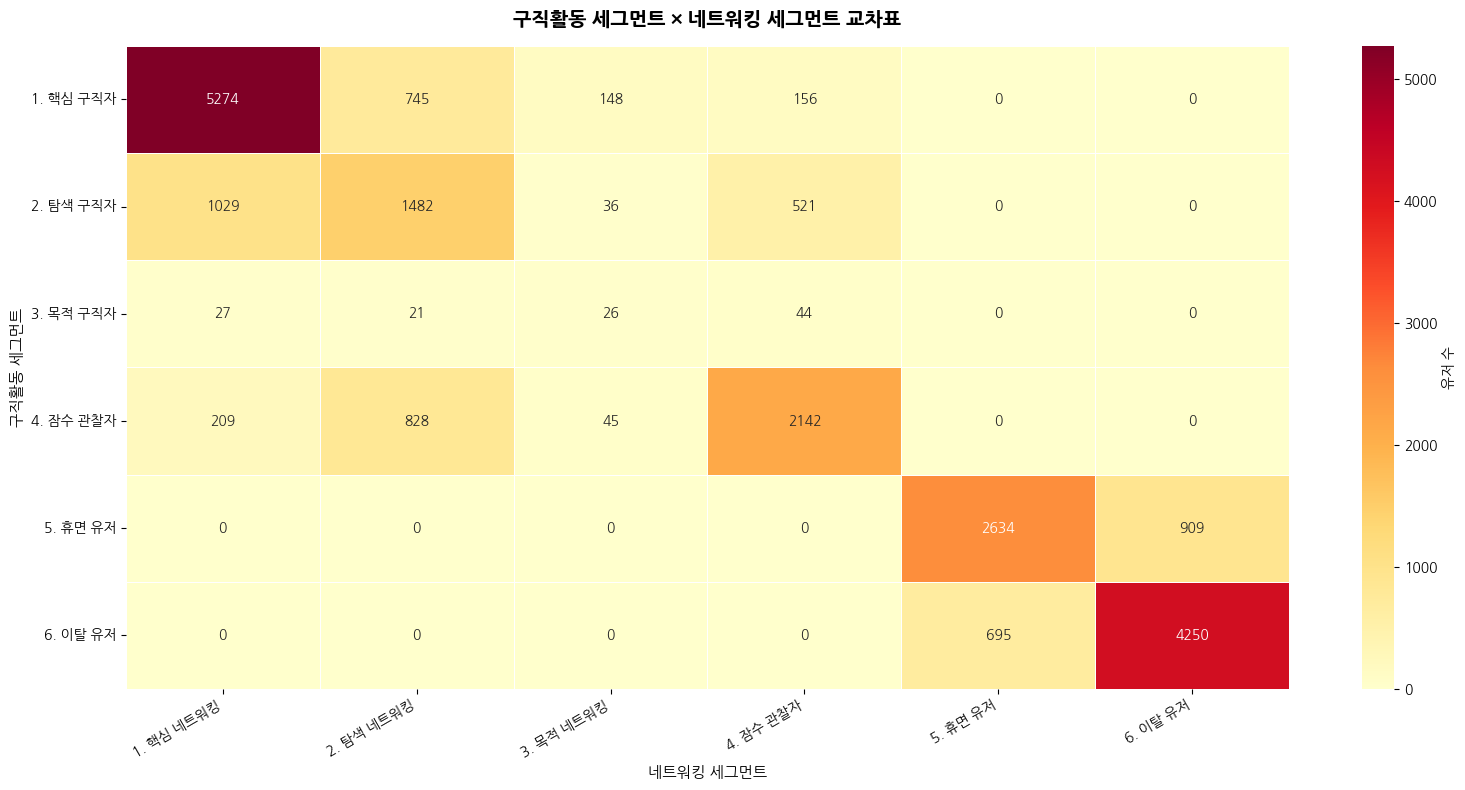

In [ ]:
# =========================================================================
# [7단계] 교차표 + 히트맵
# =========================================================================

print("=== 구직활동 × 네트워킹 세그먼트 교차표 ===")
cross = pd.crosstab(df_raw['job_segment'], df_raw['network_segment'])
display(cross)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '유저 수'}
)
plt.title('구직활동 세그먼트 × 네트워킹 세그먼트 교차표',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('네트워킹 세그먼트', fontsize=11)
plt.ylabel('구직활동 세그먼트', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##CRM 및 리텐션 전략

###타겟 세그먼트 1 : 전체 유저
###가설 : 가입 후 7일 이내 프로필 작성 여부가 이후 유저의 활동 패턴과 관련 있을 것이다.

- 프로필 작성은 초기 온보딩에서 유저를 핵심/이탈로 가르는 분기점으로 가정

has_profile
True     10744
False    10477
Name: count, dtype: int64
프로필 작성률 (가입 후 7일 이내): 50.6%

프로필 작성 유저: 10,744명
프로필 미작성 유저: 10,477명

=== 네트워킹 세그먼트 분포 비교 (%) ===
                 프로필 작성  프로필 미작성
network_segment                 
1. 핵심 네트워킹         39.9     21.5
2. 탐색 네트워킹         11.6     17.4
3. 목적 네트워킹          1.9      0.5
4. 잠수 관찰자           9.9     17.2
5. 휴면 유저           19.7     11.5
6. 이탈 유저           17.0     31.8

=== 구직활동 세그먼트 분포 비교 (%) ===
             프로필 작성  프로필 미작성
job_segment                 
1. 핵심 구직자      40.8     18.5
2. 탐색 구직자      11.6     17.4
3. 목적 구직자       0.9      0.2
4. 잠수 관찰자       9.9     20.6
5. 휴면 유저       21.8     11.5
6. 이탈 유저       15.0     31.9


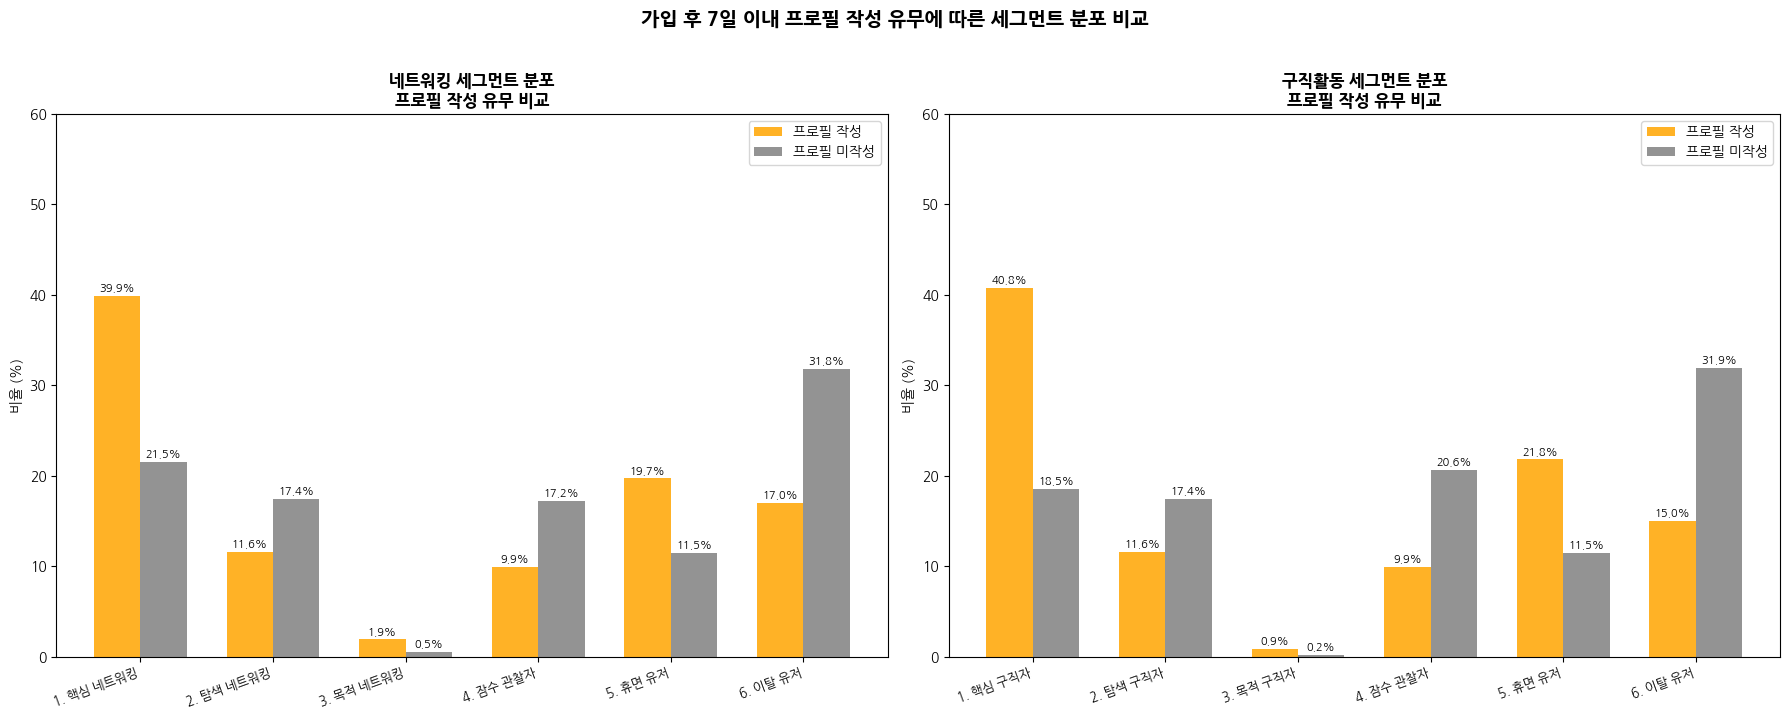


=== 핵심 유저 비율 비교 ===
핵심 네트워킹 비율 - 프로필 작성: 39.9% / 미작성: 21.5%
핵심 구직자 비율   - 프로필 작성: 40.8% / 미작성: 18.5%

프로필 작성 시 핵심 네트워킹 될 비율 차이: 18.5%p
프로필 작성 시 핵심 구직자 될 비율 차이:   22.3%p

[카이제곱 검정] 핵심 네트워킹 x 프로필 작성: chi2=847.31, p=0.0000
[카이제곱 검정] 핵심 구직자 x 프로필 작성: chi2=1261.76, p=0.0000


In [ ]:
PROFILE_URLS = {
    'api/users/email', 'api/users/id/award', 'api/users/id/career',
    'api/users/id/certification', 'api/users/id/education', 'api/users/id/language',
    'api/users/id/overview', 'api/users/id/phone/verify', 'api/users/id/profile_image',
    'api/users/id/profile_image/facebook', 'api/users/id/project', 'api/users/id/residence',
    'api/users/id/resume/step1', 'api/users/id/resume/step2', 'api/users/id/sns',
    'api/users/id/specialty', 'api/users/id/specialty/id/vote',
    'api/project/form_data/media', 'api/projects/id/media/add', 'api/users/id/experience/form',
    '@user_id/resume', 'api/users/id/career/template', 'api/users/id/project/template',
    'api/users/id/career/id/form', 'api/users/id/career/id', '@users/id/resume/step1',
    'api/users/id/project/id/form', 'api/users/id/project/id', '@users/id/resume/step2',
    'api/users/id/project', 'api/users/education/template', 'api/users/id/certification/template',
    'api/users/id/image', 'api/users/id/language/form', 'api/users/id/award/template',
    'api/users/id/specialty/template',
}

# 가입 후 7일 이내 프로필 작성 여부
first_log = df.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'first_date'})

profile_logs = df[df['url_normalized'].isin(PROFILE_URLS)]
profile_first = profile_logs.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'profile_date'})

early_behavior = df_raw.merge(first_log, on='user_uuid', how='left')
early_behavior = early_behavior.merge(profile_first, on='user_uuid', how='left')

early_behavior['days_to_profile'] = (early_behavior['profile_date'] - early_behavior['first_date']).dt.days
early_behavior['has_profile'] = (
    (early_behavior['days_to_profile'] >= 0) & (early_behavior['days_to_profile'] <= 7)
).fillna(False)

print(early_behavior['has_profile'].value_counts())
print(f"프로필 작성률 (가입 후 7일 이내): {early_behavior['has_profile'].mean():.1%}")


# =========================================================================
# 프로필 작성 유무에 따른 세그먼트 분포 비교
# =========================================================================

profile_yes = early_behavior[early_behavior['has_profile'] == True]
profile_no  = early_behavior[early_behavior['has_profile'] == False]

print(f"\n프로필 작성 유저: {len(profile_yes):,}명")
print(f"프로필 미작성 유저: {len(profile_no):,}명")

net_profile_yes = profile_yes['network_segment'].value_counts(normalize=True).mul(100).round(1)
net_profile_no  = profile_no['network_segment'].value_counts(normalize=True).mul(100).round(1)

net_compare = pd.DataFrame({
    '프로필 작성': net_profile_yes,
    '프로필 미작성': net_profile_no,
}).fillna(0).sort_index()

print("\n=== 네트워킹 세그먼트 분포 비교 (%) ===")
print(net_compare)

job_profile_yes = profile_yes['job_segment'].value_counts(normalize=True).mul(100).round(1)
job_profile_no  = profile_no['job_segment'].value_counts(normalize=True).mul(100).round(1)

job_compare = pd.DataFrame({
    '프로필 작성': job_profile_yes,
    '프로필 미작성': job_profile_no,
}).fillna(0).sort_index()

print("\n=== 구직활동 세그먼트 분포 비교 (%) ===")
print(job_compare)


# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

x = net_compare.index.tolist()
x_pos = range(len(x))
width = 0.35

bars1 = axes[0].bar([p - width/2 for p in x_pos], net_compare['프로필 작성'],
                     width=width, label='프로필 작성', color='orange', alpha=0.85)
bars2 = axes[0].bar([p + width/2 for p in x_pos], net_compare['프로필 미작성'],
                     width=width, label='프로필 미작성', color='gray', alpha=0.85)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([x.split('(')[0].strip() for x in net_compare.index],
                          rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('비율 (%)')
axes[0].set_ylim(0, 60)
axes[0].legend()
axes[0].set_title('네트워킹 세그먼트 분포\n프로필 작성 유무 비교', fontsize=12, fontweight='bold')

x2 = job_compare.index.tolist()
x_pos2 = range(len(x2))

bars3 = axes[1].bar([p - width/2 for p in x_pos2], job_compare['프로필 작성'],
                     width=width, label='프로필 작성', color='orange', alpha=0.85)
bars4 = axes[1].bar([p + width/2 for p in x_pos2], job_compare['프로필 미작성'],
                     width=width, label='프로필 미작성', color='gray', alpha=0.85)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels([x.split('(')[0].strip() for x in job_compare.index],
                          rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('비율 (%)')
axes[1].set_ylim(0, 60)
axes[1].legend()
axes[1].set_title('구직활동 세그먼트 분포\n프로필 작성 유무 비교', fontsize=12, fontweight='bold')

plt.suptitle('가입 후 7일 이내 프로필 작성 유무에 따른 세그먼트 분포 비교',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# =========================================================================
# 핵심 유저 비율 비교 + 통계 검정
# =========================================================================

from scipy.stats import chi2_contingency

core_profile_yes = (profile_yes['network_segment'] == '1. 핵심 네트워킹').mean() * 100
core_profile_no  = (profile_no['network_segment']  == '1. 핵심 네트워킹').mean() * 100

active_profile_yes = (profile_yes['job_segment'] == '1. 핵심 구직자').mean() * 100
active_profile_no  = (profile_no['job_segment']  == '1. 핵심 구직자').mean() * 100

print("\n=== 핵심 유저 비율 비교 ===")
print(f"핵심 네트워킹 비율 - 프로필 작성: {core_profile_yes:.1f}% / 미작성: {core_profile_no:.1f}%")
print(f"핵심 구직자 비율   - 프로필 작성: {active_profile_yes:.1f}% / 미작성: {active_profile_no:.1f}%")
print(f"\n프로필 작성 시 핵심 네트워킹 될 비율 차이: {core_profile_yes - core_profile_no:.1f}%p")
print(f"프로필 작성 시 핵심 구직자 될 비율 차이:   {active_profile_yes - active_profile_no:.1f}%p")

# 통계 검정
table_net = pd.crosstab(early_behavior['has_profile'], early_behavior['network_segment'] == '1. 핵심 네트워킹')
chi2_net, p_net, _, _ = chi2_contingency(table_net)
print(f"\n[카이제곱 검정] 핵심 네트워킹 x 프로필 작성: chi2={chi2_net:.2f}, p={p_net:.4f}")

table_job = pd.crosstab(early_behavior['has_profile'], early_behavior['job_segment'] == '1. 핵심 구직자')
chi2_job, p_job, _, _ = chi2_contingency(table_job)
print(f"[카이제곱 검정] 핵심 구직자 x 프로필 작성: chi2={chi2_job:.2f}, p={p_job:.4f}")

일치 유저 수: 15,808명
net_level
1    5274
2    1482
3      26
4    2142
5    2634
6    4250
Name: count, dtype: int64


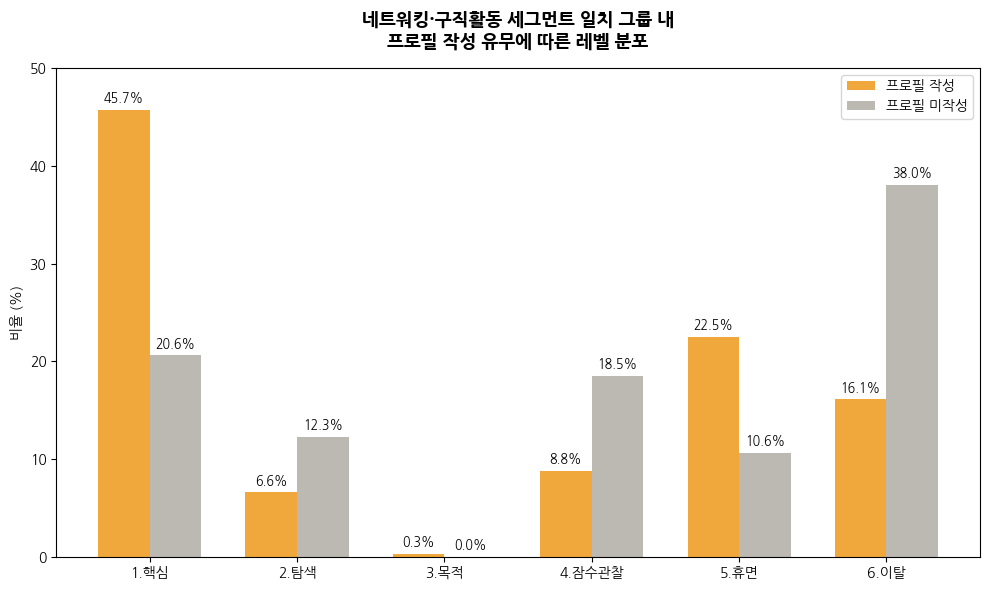


=== 일치 그룹 내 프로필 작성 유무에 따른 레벨 분포 (%) ===
           프로필 작성  프로필 미작성
net_level                 
1            45.7     20.6
2             6.6     12.3
3             0.3      0.0
4             8.8     18.5
5            22.5     10.6
6            16.1     38.0


In [ ]:
# 두 세그먼트가 동일한 "단계"인 유저만 추출
def get_level(seg):
    return seg.split('.')[0]  # '1', '2', ... 추출

df_raw['net_level'] = df_raw['network_segment'].apply(get_level)
df_raw['job_level'] = df_raw['job_segment'].apply(get_level)

# 두 세그먼트 레벨이 일치하는 유저만
aligned = df_raw[df_raw['net_level'] == df_raw['job_level']].copy()
print(f"일치 유저 수: {len(aligned):,}명")
print(aligned['net_level'].value_counts().sort_index())

# early_behavior와 merge해서 프로필 작성 여부 비교
aligned_with_profile = aligned.merge(
    early_behavior[['user_uuid', 'has_profile']], on='user_uuid', how='left'
)

# 일치 그룹 내에서, 프로필 작성 여부에 따른 "레벨" 분포 비교
profile_yes_aligned = aligned_with_profile[aligned_with_profile['has_profile']]
profile_no_aligned  = aligned_with_profile[~aligned_with_profile['has_profile']]

level_compare = pd.DataFrame({
    '프로필 작성': profile_yes_aligned['net_level'].value_counts(normalize=True).mul(100).round(1),
    '프로필 미작성': profile_no_aligned['net_level'].value_counts(normalize=True).mul(100).round(1),
}).fillna(0).sort_index()

# =========================================================================
# 시각화
# =========================================================================

level_labels = {
    '1': '1.핵심', '2': '2.탐색', '3': '3.목적',
    '4': '4.잠수관찰', '5': '5.휴면', '6': '6.이탈'
}

fig, ax = plt.subplots(figsize=(10, 6))

x = level_compare.index.tolist()
x_pos = range(len(x))
width = 0.35

bars1 = ax.bar([p - width/2 for p in x_pos], level_compare['프로필 작성'],
               width=width, label='프로필 작성', color='#EF9F27', alpha=0.9)
bars2 = ax.bar([p + width/2 for p in x_pos], level_compare['프로필 미작성'],
               width=width, label='프로필 미작성', color='#B4B2A9', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([level_labels[l] for l in x])
ax.set_ylabel('비율 (%)')
ax.set_ylim(0, 50)
ax.legend()
plt.title('네트워킹·구직활동 세그먼트 일치 그룹 내\n프로필 작성 유무에 따른 레벨 분포',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n=== 일치 그룹 내 프로필 작성 유무에 따른 레벨 분포 (%) ===")
print(level_compare)

In [ ]:
df_with_first = df.merge(first_log, on='user_uuid', how='left')
df_with_first['days_since_join'] = (df_with_first['date'] - df_with_first['first_date']).dt.days
early_7d = df_with_first[df_with_first['days_since_join'].between(0, 7)]

=== 세그먼트별 프로필 항목 작성률 (%) — 일치 그룹 ===
   경력  학력  프로젝트  자격증  언어  전문분야  이력서  SNS  개요  이미지
1  52  22    28   18  20    52   36   29  11   29
2  24   6     6    4   5    15   16   10   4    7
3  65  19    38   27  23    65   35    8   4   27
4  20   2     4    3   2     7   13    8   3    5
5  57  25    29   22  23    50   39   29   7   25
6  19   3     4    3   3     7   12   10   3    4


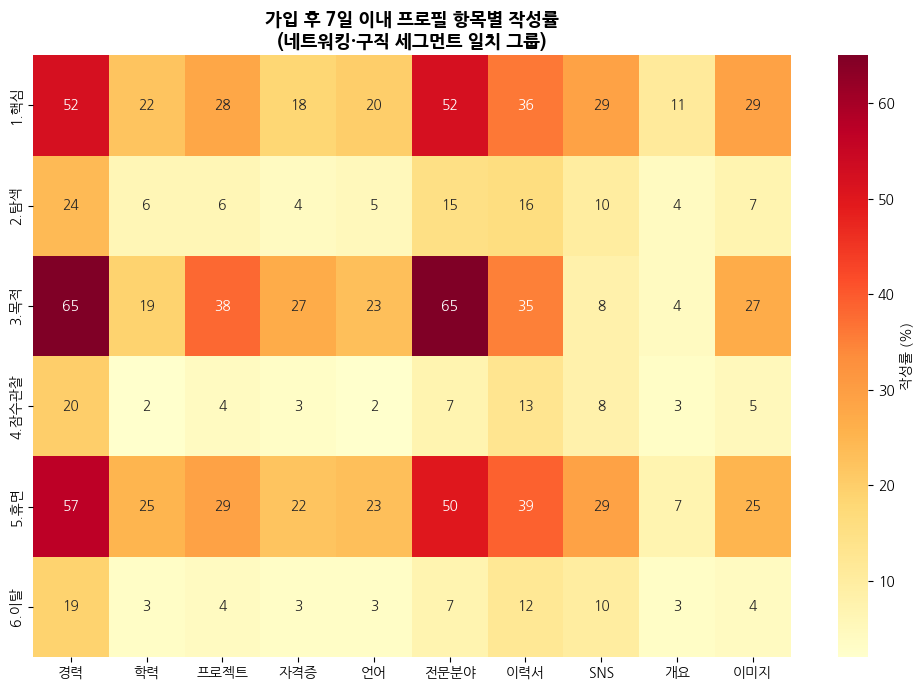

In [ ]:
PROFILE_ITEM_URLS = {
    '경력':    {'api/users/id/career', 'api/users/id/career/template', 'api/users/id/career/id/form', 'api/users/id/career/id', 'api/users/id/experience/form'},
    '학력':    {'api/users/id/education', 'api/users/education/template'},
    '프로젝트': {'api/users/id/project', 'api/users/id/project/template', 'api/users/id/project/id/form', 'api/users/id/project/id', 'api/project/form_data/media', 'api/projects/id/media/add'},
    '자격증':  {'api/users/id/certification', 'api/users/id/certification/template'},
    '언어':    {'api/users/id/language', 'api/users/id/language/form'},
    '전문분야': {'api/users/id/specialty', 'api/users/id/specialty/template', 'api/users/id/specialty/id/vote'},
    '이력서':  {'api/users/id/resume/step1', 'api/users/id/resume/step2', '@user_id/resume', '@users/id/resume/step1', '@users/id/resume/step2'},
    'SNS':     {'api/users/id/sns', 'api/users/id/profile_image/facebook'},
    '개요':    {'api/users/id/overview'},
    '이미지':  {'api/users/id/image', 'api/users/id/profile_image'},
}

aligned_uuids = set(aligned['user_uuid'])
early_7d_aligned = early_7d[early_7d['user_uuid'].isin(aligned_uuids)]

level_labels_idx = {'1':'1.핵심','2':'2.탐색','3':'3.목적','4':'4.잠수관찰','5':'5.휴면','6':'6.이탈'}

def item_completion_rate(level, item_urls):
    seg_users = aligned[aligned['net_level'] == level]['user_uuid']
    n = len(seg_users)
    logs = early_7d_aligned[early_7d_aligned['user_uuid'].isin(seg_users)]
    users_with_item = logs[logs['url_normalized'].isin(item_urls)]['user_uuid'].nunique()
    return round(users_with_item / n * 100) if n > 0 else 0

heatmap = pd.DataFrame(index=sorted(aligned['net_level'].unique()), columns=PROFILE_ITEM_URLS.keys())
for level in heatmap.index:
    for item, urls in PROFILE_ITEM_URLS.items():
        heatmap.loc[level, item] = item_completion_rate(level, urls)

heatmap = heatmap.astype(int)

print("=== 세그먼트별 프로필 항목 작성률 (%) — 일치 그룹 ===")
print(heatmap)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            yticklabels=[level_labels_idx[i] for i in heatmap.index],
            cbar_kws={'label': '작성률 (%)'})
ax.set_title('가입 후 7일 이내 프로필 항목별 작성률\n(네트워킹·구직 세그먼트 일치 그룹)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

####전략 : 가입 당일 프로필 중 "경력/전문분야/이력서" 우선 작성 유도 온보딩

- 전제 : 모수가 충분히 큰 세그먼트(1.핵심 5,274명, 6.이탈 4,250명)만 비교 대상으로 한다. 3.목적형(26명) 등 소수 그룹은 노이즈 가능성이 높아 제외.
- 방식: 가입 절차 자체에 통합 — 가입 완료 직후 자동으로 "경력/전문분야/이력서" 작성 화면으로 연결. 또는 가입 후 1~2시간 내 미작성 시 즉시 인앱/푸시 리마인더(같은 날 안에 1회 발송이 핵심, 다음날부터는 효과 낮음)
- 채널: 인앱(가입 플로우 내 단계로 포함이 최우선) + 당일 한정 푸시 1회(이탈 방지용)
- 메시지 예시(가입 플로우 내):  "경력 · 전문분야 · 이력서, 이 3가지만 입력하면 맞춤 공고와 인맥을 추천받을 수 있어요" + 진행률 바(예: "2/3 완료, 1분만 더!")
- 기대 효과: 전체 가입자의 약 50%인 미작성자(약 10,477명) 중 일부가 당일 작성으로 전환되면, 이들의 핵심 세그먼트 진입 가능성이 현재 미작성자 그룹(20.6%) 대비 작성자 그룹(45.7%) 수준으로 높아질 잠재력. 이탈 세그먼트 비율도 38.0% → 16.1% 수준으로 낮아질 가능성.

- 한계 및 검증 필요사항: 이는 상관관계 기반 발견으로, 인과관계 확인을 위해 "가입 플로우 내 프로필 작성 유도 강화" 적용 그룹과 미적용 그룹의 A/B 테스트가 필요합니다. 다만 ① 효과 크기가 크고(2배 이상 차이), ② 일치 그룹으로 좁혀도 재현되며, ③ "가입 당일"이라는 구체적 실행 시점이 명확하다는 점에서, 우선 시도해볼 가치가 있는 전략으로 판단됩니다.

### 타겟 세그먼트 2 : 탐색 구직자


- 공고에 대한 정보는 적극적으로 보지만, 지원 행동으로 안이어지는 그룹임.
- 단순 구직 의지가 낮은게 아니라, 지원 단계에서 문제가 있는 것으로 가정함.

###가설 : 단순 구직 의지가 낮은게 아니라, 지원 단계에서 문제가 있음

- 지원 프로세스 중, 어느 단계에 이탈률이 높은지 진단 후, 해당 시점에 액션 추가
- 지원 프로세스는 공고 북마크 -> 지원 step1 -> 지원 step2 -> 지원 step3 -> 지원 step4 -> complete 순

In [ ]:
# =========================================================================
# jobbookmark 데이터 로드
# =========================================================================

bookmark_df = pd.read_csv('/content/drive/MyDrive/jobbookmark.csv')
bookmark_df['cdate'] = pd.to_datetime(bookmark_df['cdate'], errors='coerce')

bookmark_22_23 = bookmark_df[
    (bookmark_df['cdate'] >= '2022-01-01') & (bookmark_df['cdate'] <= '2023-12-31')
]

In [ ]:
# =========================================================================
# 시간순 퍼널 분석 (북마크 -> step1~4 -> 완료)
# =========================================================================

step_map = {
    'api/jobs/id/apply/step1': 1, 'jobs/id/apply/step1': 1,
    'api/jobs/id/apply/step2': 2, 'jobs/id/apply/step2': 2,
    'api/jobs/id/apply/step3': 3, 'jobs/id/apply/step3': 3,
    'api/jobs/id/apply/step4': 4, 'jobs/id/apply/step4': 4,
    'jobs/id/apply/complete': 5,
}

def max_consecutive_step(g):
    expected = 0
    reached = -1
    for s in g['step_num']:
        if s == expected:
            reached = expected
            expected += 1
        elif s == expected - 1:
            continue
        elif s > expected:
            break
    return reached

def run_funnel(target_users, label):
    apply_logs = df[df['user_uuid'].isin(target_users)].copy()
    apply_logs['step_num'] = apply_logs['url_normalized'].map(step_map)
    apply_logs = apply_logs.dropna(subset=['step_num'])
    apply_logs = apply_logs[['user_uuid', 'timestamp', 'step_num']].rename(columns={'timestamp': 'event_time'})

    bm_logs = bookmark_22_23[bookmark_22_23['user_uuid'].isin(target_users)].copy()
    bm_logs = bm_logs[['user_uuid', 'cdate']].rename(columns={'cdate': 'event_time'})
    bm_logs['step_num'] = 0

    all_events = pd.concat([bm_logs, apply_logs], ignore_index=True).sort_values(['user_uuid', 'event_time'])

    results = []
    for uid, g in all_events.groupby('user_uuid'):
        results.append({'user_uuid': uid, 'max_step': max_consecutive_step(g)})
    res_df = pd.DataFrame(results)

    all_target = pd.DataFrame({'user_uuid': target_users})
    res_df = all_target.merge(res_df, on='user_uuid', how='left')
    res_df['max_step'] = res_df['max_step'].fillna(-1)

    n = len(all_target)
    steps = ['북마크 도달', 'step1 도달', 'step2 도달', 'step3 도달', 'step4 도달', '완료']
    counts = [
        (res_df['max_step'] >= 0).sum(),
        (res_df['max_step'] >= 1).sum(),
        (res_df['max_step'] >= 2).sum(),
        (res_df['max_step'] >= 3).sum(),
        (res_df['max_step'] >= 4).sum(),
        (res_df['max_step'] >= 5).sum(),
    ]

    funnel_df = pd.DataFrame({'step': steps, 'user_count': counts})
    funnel_df['전체대비%'] = (funnel_df['user_count'] / n * 100).round(1)

    conv_rates = [None]
    drop_rates = [None]
    for i in range(1, len(counts)):
        prev, curr = counts[i-1], counts[i]
        conv = (curr / prev * 100) if prev > 0 else 0
        conv_rates.append(round(conv, 1))
        drop_rates.append(round(100 - conv, 1))

    funnel_df['전환율%'] = conv_rates
    funnel_df['이탈률%'] = drop_rates

    print(f"\n=== {label} (n={n}) ===")
    print(funnel_df.to_string(index=False))
    return res_df


target_explore = df_raw[df_raw['job_segment'] == '2. 탐색 구직자']['user_uuid']
target_active = df_raw[df_raw['job_segment'] == '1. 핵심 구직자']['user_uuid']

run_funnel(target_explore, "탐색 구직자")
run_funnel(target_active, "핵심 구직자")


=== 탐색 구직자 (n=3068) ===
    step  user_count  전체대비%  전환율%  이탈률%
  북마크 도달         756   24.6   NaN   NaN
step1 도달         374   12.2  49.5  50.5
step2 도달         249    8.1  66.6  33.4
step3 도달         145    4.7  58.2  41.8
step4 도달         111    3.6  76.6  23.4
      완료          43    1.4  38.7  61.3

=== 핵심 구직자 (n=6323) ===
    step  user_count  전체대비%  전환율%  이탈률%
  북마크 도달        2050   32.4   NaN   NaN
step1 도달        2009   31.8  98.0   2.0
step2 도달        1990   31.5  99.1   0.9
step3 도달        1455   23.0  73.1  26.9
step4 도달        1418   22.4  97.5   2.5
      완료         601    9.5  42.4  57.6


,user_uuid,max_step
0,000b55ad-5c86-438b-a5b0-9ea3a2917789,-1.0
1,004a89cc-d69b-4336-9905-4fd306e3ef80,-1.0
2,004fe85d-328f-408e-b64c-566227ecd8e8,-1.0
3,005d1d8c-2b25-4b4e-a5a3-a1f2a2efe7d2,-1.0
4,00605090-bd12-4978-884b-c74e093b40d0,-1.0
...,...,...
6318,ffd75368-f7ed-4eaf-9db9-0f76ef80af31,-1.0
6319,ffe429f9-200e-472d-9d72-2742727c8ea8,-1.0
6320,ffe6aee0-85cc-45e2-aa5e-129751dff08e,2.0
6321,ffeba6fd-76b6-41cc-8535-de3d9d86e079,-1.0



=== 탐색 구직자 (n=3068) ===
  step  user_count  전체대비%  전환율%  이탈률%
북마크 도달         756   24.6   NaN   NaN
 Step1         374   12.2  49.5  50.5
 Step2         249    8.1  66.6  33.4
 Step3         145    4.7  58.2  41.8
 Step4         111    3.6  76.6  23.4
 지원 완료          43    1.4  38.7  61.3

=== 핵심 구직자 (n=6323) ===
  step  user_count  전체대비%  전환율%  이탈률%
북마크 도달        2050   32.4   NaN   NaN
 Step1        2009   31.8  98.0   2.0
 Step2        1990   31.5  99.1   0.9
 Step3        1455   23.0  73.1  26.9
 Step4        1418   22.4  97.5   2.5
 지원 완료         601    9.5  42.4  57.6


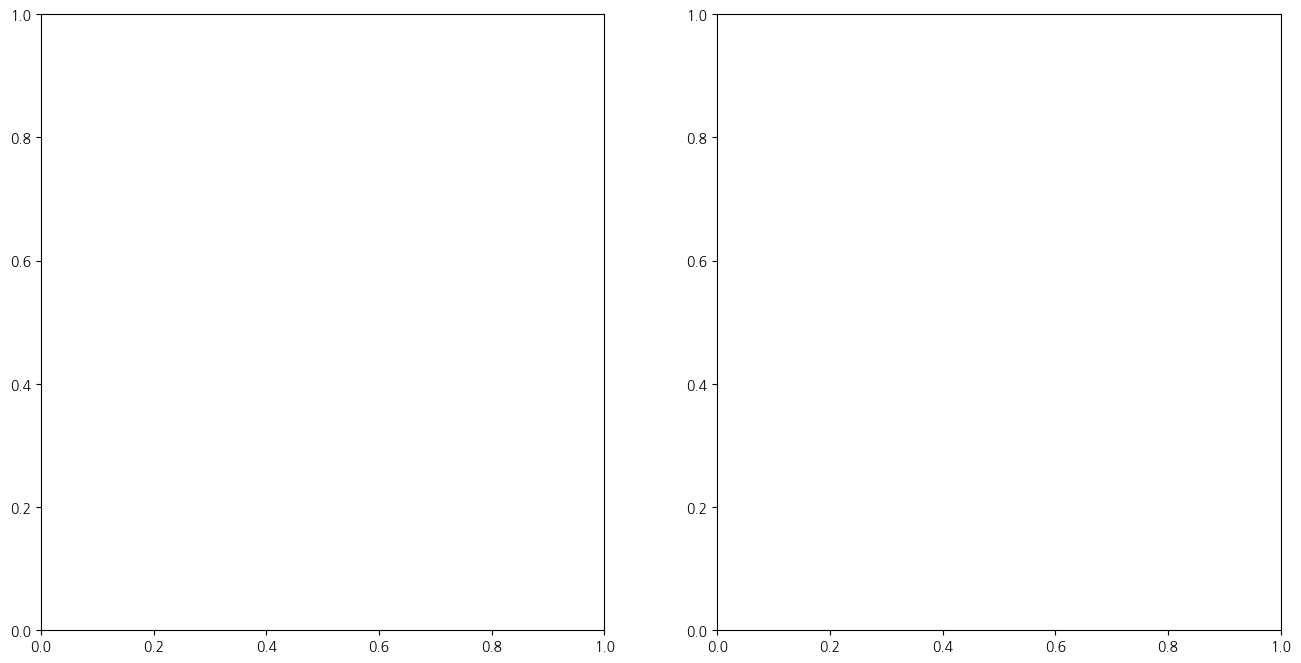

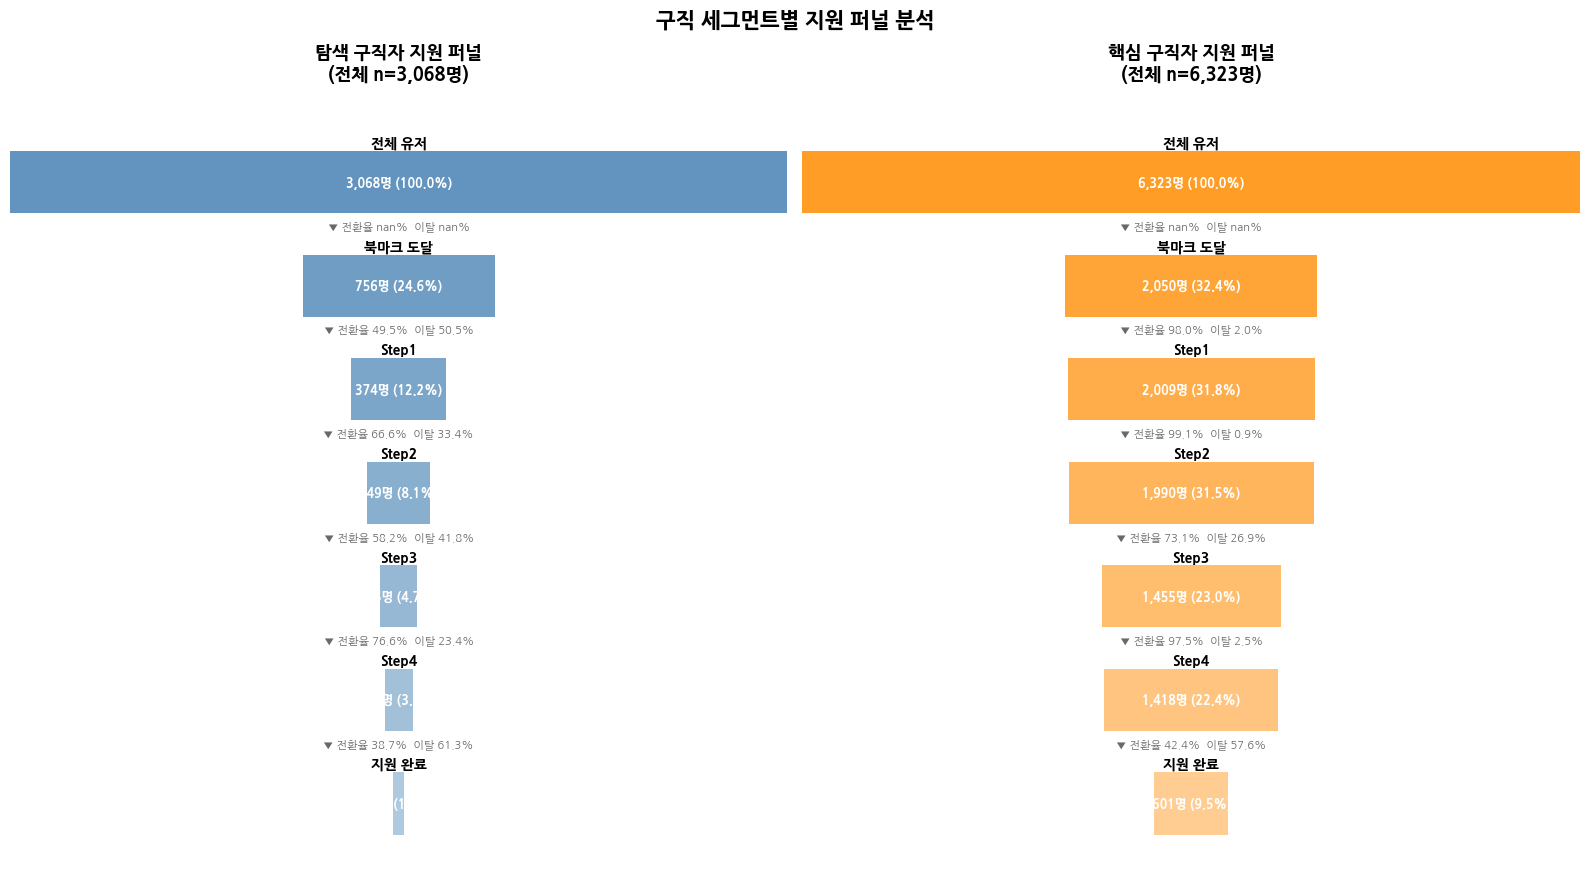

In [ ]:
def run_funnel_with_viz(target_users, label):
    apply_logs = df[df['user_uuid'].isin(target_users)].copy()
    apply_logs['step_num'] = apply_logs['url_normalized'].map(step_map)
    apply_logs = apply_logs.dropna(subset=['step_num'])
    apply_logs = apply_logs[['user_uuid', 'timestamp', 'step_num']].rename(columns={'timestamp': 'event_time'})

    bm_logs = bookmark_22_23[bookmark_22_23['user_uuid'].isin(target_users)].copy()
    bm_logs = bm_logs[['user_uuid', 'cdate']].rename(columns={'cdate': 'event_time'})
    bm_logs['step_num'] = 0

    all_events = pd.concat([bm_logs, apply_logs], ignore_index=True).sort_values(['user_uuid', 'event_time'])

    results = []
    for uid, g in all_events.groupby('user_uuid'):
        results.append({'user_uuid': uid, 'max_step': max_consecutive_step(g)})
    res_df = pd.DataFrame(results)

    all_target = pd.DataFrame({'user_uuid': target_users})
    res_df = all_target.merge(res_df, on='user_uuid', how='left')
    res_df['max_step'] = res_df['max_step'].fillna(-1)

    n = len(all_target)
    steps = ['북마크 도달', 'Step1', 'Step2', 'Step3', 'Step4', '지원 완료']
    counts = [
        (res_df['max_step'] >= 0).sum(),
        (res_df['max_step'] >= 1).sum(),
        (res_df['max_step'] >= 2).sum(),
        (res_df['max_step'] >= 3).sum(),
        (res_df['max_step'] >= 4).sum(),
        (res_df['max_step'] >= 5).sum(),
    ]

    funnel_df = pd.DataFrame({'step': steps, 'user_count': counts})
    funnel_df['전체대비%'] = (funnel_df['user_count'] / n * 100).round(1)

    conv_rates = [None]
    drop_rates = [None]
    for i in range(1, len(counts)):
        prev, curr = counts[i-1], counts[i]
        conv = (curr / prev * 100) if prev > 0 else 0
        conv_rates.append(round(conv, 1))
        drop_rates.append(round(100 - conv, 1))

    funnel_df['전환율%'] = conv_rates
    funnel_df['이탈률%'] = drop_rates

    print(f"\n=== {label} (n={n}) ===")
    print(funnel_df.to_string(index=False))
    return funnel_df

# 퍼널 데이터 계산
target_explore = df_raw[df_raw['job_segment'] == '2. 탐색 구직자']['user_uuid']
target_active  = df_raw[df_raw['job_segment'] == '1. 핵심 구직자']['user_uuid']

funnel_explore = run_funnel_with_viz(target_explore, "탐색 구직자")
funnel_active  = run_funnel_with_viz(target_active,  "핵심 구직자")

# =========================================================================
# 시각화
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

def plot_funnel_shape(ax, funnel_df, label, color, n_total):
    # 전체 n을 맨 앞에 추가
    steps  = ['전체 유저'] + funnel_df['step'].tolist()
    counts = [n_total]    + funnel_df['user_count'].tolist()
    pcts   = [100.0]      + funnel_df['전체대비%'].tolist()
    convs  = [None]       + funnel_df['전환율%'].tolist()
    drops  = [None]       + funnel_df['이탈률%'].tolist()

    max_count = counts[0]

    for i, (step, count, pct, conv, drop) in enumerate(zip(steps, counts, pcts, convs, drops)):
        width = count / max_count
        left  = (1 - width) / 2

        ax.barh(y=-i, width=width, left=left,
                height=0.6, color=color, alpha=max(0.85 - i * 0.07, 0.3))

        # 스텝명
        ax.text(0.5, -i + 0.38, step, ha='center', va='center',
                fontsize=10, fontweight='bold')

        # 유저 수 + 비율
        ax.text(0.5, -i, f'{count:,}명 ({pct}%)',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

        # 전환율 / 이탈률 (첫 번째 제외)
        if i > 0 and conv is not None:
            ax.text(0.5, -i + 0.58,
                    f'▼ 전환율 {conv}%  이탈 {drop}%',
                    ha='center', va='center', fontsize=8, color='dimgray')

    ax.set_xlim(0, 1)
    ax.set_ylim(-len(steps) + 0.3, 0.8)
    ax.axis('off')
    ax.set_title(f'{label} 지원 퍼널\n(전체 n={n_total:,}명)', fontsize=13, fontweight='bold', pad=15)


n_explore = len(target_explore)
n_active  = len(target_active)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plot_funnel_shape(axes[0], funnel_explore, '탐색 구직자', 'steelblue',  n_explore)
plot_funnel_shape(axes[1], funnel_active,  '핵심 구직자', 'darkorange', n_active)

plt.suptitle('구직 세그먼트별 지원 퍼널 분석', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

###전략1 : 탐색 구직자 중, 북마크 후 지원하지 않는 유저 대상 "지원 시작 유도" (382명)

- 발송 시점 : 북마크 후 24~48시간 이내 1차 발송, 미반응 시 마감 임박(D-3 등) 시점에 2차 발송
- 채널 : 푸시 알림(즉시성, 행동 유도 효과적) + 이메일(공고 마감일 등 정보 포함, 푸시 미수신자 보완)
- 메세지 예시 : "북마크 하신 ㅇㅇ공고, 마감까지 3일 남았어요 - 지금 지원해보세요"
- 기대 효과 : 핵심 구직자의 step1 전환율인 98%를 기준으로 할 때, 탐색 구직자(현재 49.5%)가 이 격차의 일부만 좁혀도(예: 60~70%) 추가 step1 진입자 상당수 발생. 이는 퍼널 전체의 모수를 늘려 하위 단계(완료) 인원 증가로 이어짐.

###전략2 : 전체 구직자 대상 step4(최종 제출) 단계 개선

- 발송 시점 : step4 페이지 진입 후 일정 시간(30분~1시간) 내 미제출 시 리마인더 즉시 발송
- 채널: 인앱 알림/배너(이탈 시점이 사이트 내부이므로 가장 직접적)
- 메시지 예시 : "작성 중인 지원서가 있어요 — 마무리하고 제출하세요" (임시저장 기능이 있다면 "이어서 작성하기" 링크 포함)
- 기대 효과 : step4에서 complete 까지 이탈률이 핵심 구직자와 탐색 구직자 두 그룹 모두에서 가장 큰 손실 구간이므로, (61.3%/57.6%)은 두 그룹 모두에서 가장 큰 손실 구간. 이 단계는 모수 자체가 크므로(특히 핵심 구직자 1418명), 이탈률을 10%p만 낮춰도 완료 인원이 두 그룹 합산 약 150~250명 증가 가능

##타겟 세그먼트 2-2 : 탐색 구직자 중 핵심 네트워킹 (1029명)

- 사람과 회사에 대한 정보는 적극적으로 탐색하는데, 지원 행동으로 안이어지는 그룹임.
- 플랫폼 입장에서 수익화가 가장 안되는 케이스


###가설 : 추천 공고가 개인의 네트워킹 관심사(둘러본 회사/직무/사람)와 무관하게 모든 유저에게 동일하게 노출되어, "내가 관심 있는 영역"과 "추천받는 공고"가 단절되어 있음.

- 네트워킹에서 본 정보(관심 회사/직무/사람)와 구직 추천(공고)이 연결 안되었을 가능성. 네트워킹 활동 데이터를 구직 추천에 반영.

- 최근 둘러본 회사와 비슷한 직무 공고 추천

정성조사 제안:

- 유저 인터뷰 (이 세그먼트 내 5~10명): "최근 본 회사/사람"과 "추천 공고함에서 본 내용"이 본인에게 얼마나 관련 있게 느껴지는지, 추천 공고를 클릭하지 않는 이유 직접 질문
- 사용성 테스트(UT): 실제로 네트워킹 활동(회사 탐색, 팔로우 등)을 한 직후 추천 공고 화면을 보여주고, "이게 나와 관련 있다고 느끼는가"를 즉석에서 관찰
- 설문(정량 보완): 이 세그먼트 대상으로 "추천 공고가 본인 관심사와 얼마나 맞는지" 1~5점 평가 + 주관식("어떤 정보가 추천에 반영되면 좋을지")

UX 개선 방향(가설 검증 후):

- 추천 공고를 "전체 공통"이 아닌 "최근 둘러본 회사/직무 기반 개인화"로 전환
- 네트워킹 탭과 구직 탭 사이에 "당신이 관심 있을 만한 공고" 같은 연결 지점 신설 (예: 회사 페이지에서 "이 회사 채용 중" 배너)

## 타겟 세그먼트 3 : 탐색 네트워킹

- 사람/회사 정보를 충분히 보고 있지만, 연결 행동으로 전환되지는 않음. 심리적 진입장벽이 원인일 수 있음

###전략제안

아이디어 1: 커피챗 제안 기능
- 특정 프로필을 N회 이상 조회한 유저에게 "이 분께 커피챗 제안해보기" 버튼 노출. 정중한 템플릿 메시지 제공으로 작성 부담 낮춤.

아이디어 2: 추천인/멘토 매칭 제도
- 같은 직무·산업 "선배" 유저를 매칭해, 신규/탐색형 유저가 부담 없이 질문할 수 있는 1:1 채널 제공. 멘토 측에는 활동 포인트/뱃지 등 인센티브 부여.

아이디어 3: 업계 종사자 추천 알고리즘
- 탐색 중인 회사/직무와 연결된 "현직자"를 자동 추천하고, "이 분은 회원님과 같은 분야에 관심이 있어요" 같은 약한 연결고리 제시 → 팔로우/연결 행동의 명분 제공.

기대 효과: passive(탐색) → active(연결) 전환의 심리적 장벽을 낮춰, 탐색형(2번) 그룹의 active_network_score 상승 → 핵심(1번)으로의 전환 유도.

한계: 이 전략들은 데이터로 직접 검증된 게 아니라, "탐색은 하는데 행동은 안 한다"는 패턴에 대한 업계 일반적 솔루션 제안입니다. 도입 후 효과는 A/B 테스트로 확인이 필요합니다.

## 퍼널 분석

In [ ]:
#행동기반 퍼널
# =========================================================================
# [추가] 프로필 작성 URL 정의
# =========================================================================

PROFILE_URLS = {
    'api/users/email',
    'api/users/id/award',
    'api/users/id/career',
    'api/users/id/certification',
    'api/users/id/education',
    'api/users/id/language',
    'api/users/id/overview',
    'api/users/id/phone/verify',
    'api/users/id/profile_image',
    'api/users/id/profile_image/facebook',
    'api/users/id/project',
    'api/users/id/residence',
    'api/users/id/resume/step1',
    'api/users/id/resume/step2',
    'api/users/id/sns',
    'api/users/id/specialty',
    'api/users/id/specialty/id/vote',
    'api/project/form_data/media',
    'api/projects/id/media/add',
    'api/users/id/experience/form',
    '@user_id/resume',
    'api/users/id/career/template',
    'api/users/id/project/template',
    'api/users/id/career/id/form',
    'api/users/id/career/id',
    '@users/id/resume/step1',
    'api/users/id/project/id/form',
    'api/users/id/project/id',
    '@users/id/resume/step2',
    'api/users/education/template',
    'api/users/id/certification/template',
    'api/users/id/image',
    'api/users/id/language/form',
    'api/users/id/award/template',
    'api/users/id/specialty/template'
}

df['is_profile'] = df['url_normalized'].isin(PROFILE_URLS)

print("프로필 작성 로그 수:", df['is_profile'].sum())
print("프로필 작성 경험 유저 수:", df.loc[df['is_profile'], 'user_uuid'].nunique())

프로필 작성 로그 수: 1179719
프로필 작성 경험 유저 수: 16406


In [ ]:
# =========================================================================
# [퍼널 1] 행동 경험 기반 퍼널
# 전체 방문 → 프로필 작성 → 소극 네트워킹 → 적극 네트워킹 → 지원
# =========================================================================

funnel_user = (
    df.groupby('user_uuid')
    .agg(
        visited=('user_uuid', 'size'),
        profile=('is_profile', 'max'),
        passive_network=('is_passive_network', 'max'),
        active_network=('is_active_network', 'max'),
        apply=('is_active_job', 'max')
    )
    .reset_index()
)

total_users = funnel_user['user_uuid'].nunique()

funnel_counts = {
    '1. 전체 방문': total_users,
    '2. 프로필 작성': funnel_user['profile'].sum(),
    '3. 소극 네트워킹': funnel_user[
        funnel_user['profile']
    ]['passive_network'].sum(),
    '4. 적극 네트워킹': funnel_user[
        funnel_user['profile'] &
        funnel_user['passive_network']
    ]['active_network'].sum(),
    '5. 지원': funnel_user[
        funnel_user['profile'] &
        funnel_user['passive_network'] &
        funnel_user['active_network']
    ]['apply'].sum()
}

funnel_df = pd.DataFrame({
    'step': list(funnel_counts.keys()),
    'user_count': list(funnel_counts.values())
})

funnel_df['전체 대비 비율(%)'] = (
    funnel_df['user_count'] / total_users * 100
).round(1)

funnel_df['이전 단계 대비 전환율(%)'] = (
    funnel_df['user_count'] / funnel_df['user_count'].shift(1) * 100
).round(1)

funnel_df.loc[0, '이전 단계 대비 전환율(%)'] = 100.0

display(funnel_df)

,step,user_count,전체 대비 비율(%),이전 단계 대비 전환율(%)
0,1. 전체 방문,21221,100.0,100.0
1,2. 프로필 작성,16406,77.3,77.3
2,3. 소극 네트워킹,16272,76.7,99.2
3,4. 적극 네트워킹,15407,72.6,94.7
4,5. 지원,11978,56.4,77.7


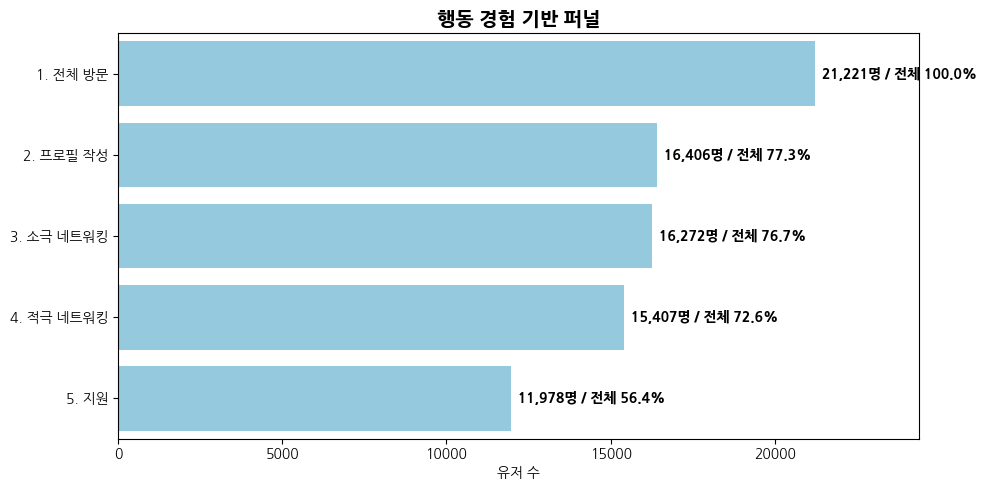

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=funnel_df,
    x='user_count',
    y='step',
    color='skyblue',
    ax=ax
)

for i, row in funnel_df.iterrows():
    ax.text(
        row['user_count'] + total_users * 0.01,
        i,
        f"{int(row['user_count']):,}명 / 전체 {row['전체 대비 비율(%)']}%",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlim(0, total_users * 1.15)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('행동 경험 기반 퍼널', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# [퍼널 2] 순서 기반 퍼널
# 각 단계별 최초 timestamp 추출
# =========================================================================

first_visit_ts = (
    df.groupby('user_uuid')['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_visit_ts'})
)

first_profile_ts = (
    df[df['is_profile']]
    .groupby('user_uuid')['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_profile_ts'})
)

first_passive_network_ts = (
    df[df['is_passive_network']]
    .groupby('user_uuid')['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_passive_network_ts'})
)

first_active_network_ts = (
    df[df['is_active_network']]
    .groupby('user_uuid')['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_active_network_ts'})
)

first_apply_ts = (
    df[df['is_active_job']]
    .groupby('user_uuid')['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_apply_ts'})
)

funnel_ts = (
    first_visit_ts
    .merge(first_profile_ts, on='user_uuid', how='left')
    .merge(first_passive_network_ts, on='user_uuid', how='left')
    .merge(first_active_network_ts, on='user_uuid', how='left')
    .merge(first_apply_ts, on='user_uuid', how='left')
)

# 순서 조건
funnel_ts['step1_visit'] = funnel_ts['first_visit_ts'].notna()

funnel_ts['step2_profile_after_visit'] = (
    funnel_ts['first_profile_ts'].notna() &
    (funnel_ts['first_profile_ts'] >= funnel_ts['first_visit_ts'])
)

funnel_ts['step3_passive_after_profile'] = (
    funnel_ts['step2_profile_after_visit'] &
    funnel_ts['first_passive_network_ts'].notna() &
    (funnel_ts['first_passive_network_ts'] >= funnel_ts['first_profile_ts'])
)

funnel_ts['step4_active_after_passive'] = (
    funnel_ts['step3_passive_after_profile'] &
    funnel_ts['first_active_network_ts'].notna() &
    (funnel_ts['first_active_network_ts'] >= funnel_ts['first_passive_network_ts'])
)

funnel_ts['step5_apply_after_active'] = (
    funnel_ts['step4_active_after_passive'] &
    funnel_ts['first_apply_ts'].notna() &
    (funnel_ts['first_apply_ts'] >= funnel_ts['first_active_network_ts'])
)

ordered_funnel_counts = {
    '1. 첫 방문': funnel_ts['step1_visit'].sum(),
    '2. 프로필 작성': funnel_ts['step2_profile_after_visit'].sum(),
    '3. 소극 네트워킹': funnel_ts['step3_passive_after_profile'].sum(),
    '4. 적극 네트워킹': funnel_ts['step4_active_after_passive'].sum(),
    '5. 지원': funnel_ts['step5_apply_after_active'].sum()
}

ordered_funnel_df = pd.DataFrame({
    'step': list(ordered_funnel_counts.keys()),
    'user_count': list(ordered_funnel_counts.values())
})

ordered_funnel_df['전체 대비 비율(%)'] = (
    ordered_funnel_df['user_count'] / ordered_funnel_df.loc[0, 'user_count'] * 100
).round(1)

ordered_funnel_df['이전 단계 대비 전환율(%)'] = (
    ordered_funnel_df['user_count'] / ordered_funnel_df['user_count'].shift(1) * 100
).round(1)

ordered_funnel_df.loc[0, '이전 단계 대비 전환율(%)'] = 100.0

display(ordered_funnel_df)

,step,user_count,전체 대비 비율(%),이전 단계 대비 전환율(%)
0,1. 첫 방문,21221,100.0,100.0
1,2. 프로필 작성,16406,77.3,77.3
2,3. 소극 네트워킹,4165,19.6,25.4
3,4. 적극 네트워킹,416,2.0,10.0
4,5. 지원,174,0.8,41.8


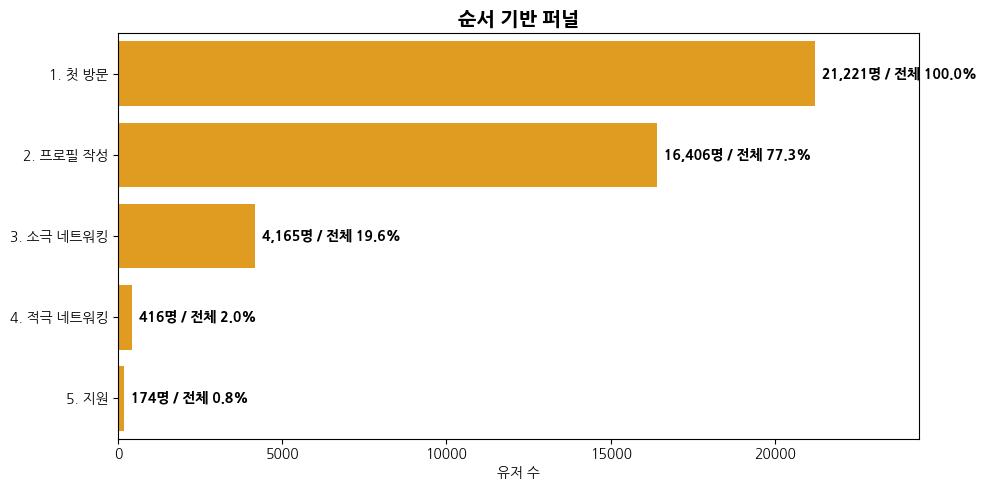

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=ordered_funnel_df,
    x='user_count',
    y='step',
    color='orange',
    ax=ax
)

base_users = ordered_funnel_df.loc[0, 'user_count']

for i, row in ordered_funnel_df.iterrows():
    ax.text(
        row['user_count'] + base_users * 0.01,
        i,
        f"{int(row['user_count']):,}명 / 전체 {row['전체 대비 비율(%)']}%",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlim(0, base_users * 1.15)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('순서 기반 퍼널', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
display(ordered_funnel_df)

,step,user_count,전체 대비 비율(%),이전 단계 대비 전환율(%)
0,1. 첫 방문,21221,100.0,100.0
1,2. 프로필 작성,16406,77.3,77.3
2,3. 소극 네트워킹,4165,19.6,25.4
3,4. 적극 네트워킹,416,2.0,10.0
4,5. 지원,174,0.8,41.8


In [ ]:
#행동 흐름 파악하기
behavior_ts = (
    first_visit_ts
    .merge(first_profile_ts, on='user_uuid', how='left')
    .merge(first_passive_network_ts, on='user_uuid', how='left')
    .merge(first_active_network_ts, on='user_uuid', how='left')
    .merge(first_apply_ts, on='user_uuid', how='left')
)

display(behavior_ts.head())

,user_uuid,first_visit_ts,first_profile_ts,first_passive_network_ts,first_active_network_ts,first_apply_ts
0,0002535c-eacb-456b-a620-92c917332ba3,2022-01-15 07:44:06.150657,2022-06-08 06:25:31.978254,2022-01-15 07:44:06.150657,2022-06-08 06:25:31.800205,2022-06-08 06:25:30.977917
1,0005769f-54b1-44ab-b6d3-bd9147c006a8,2022-11-07 04:42:24.760892,NaT,2022-11-07 04:42:32.683363,NaT,NaT
2,000681b4-bb66-4ccf-9786-f0066d13a34e,2023-12-24 11:54:38.290138,2023-12-24 12:32:54.696249,2023-12-24 11:55:41.566966,2023-12-24 12:01:09.841348,NaT
3,000b55ad-5c86-438b-a5b0-9ea3a2917789,2023-06-21 11:01:34.772232,2023-06-21 11:02:01.742970,2023-06-21 11:02:15.152688,2023-06-21 11:01:54.763335,2023-07-06 11:08:19.447925
4,000d53f7-5ddd-48ba-8dab-bb77b157e13a,2022-02-17 02:10:51.623535,2022-02-17 02:12:55.261417,2022-02-17 02:10:52.887974,2022-02-17 02:12:55.086286,2022-02-17 02:12:54.380815


In [ ]:
def compare_order(df, col1, col2):

    temp = df[[col1, col2]].dropna()

    before = (temp[col1] < temp[col2]).sum()
    after = (temp[col1] > temp[col2]).sum()
    same = (temp[col1] == temp[col2]).sum()

    total = len(temp)

    return pd.Series({
        '총 유저 수': total,
        f'{col1} 먼저 (%)': round(before / total * 100, 1),
        f'{col2} 먼저 (%)': round(after / total * 100, 1),
        '동시 (%)': round(same / total * 100, 1)
    })

In [ ]:
results = pd.concat([
    compare_order(
        behavior_ts,
        'first_profile_ts',
        'first_passive_network_ts'
    ).rename('프로필 vs 소극'),

    compare_order(
        behavior_ts,
        'first_profile_ts',
        'first_active_network_ts'
    ).rename('프로필 vs 적극'),

    compare_order(
        behavior_ts,
        'first_profile_ts',
        'first_apply_ts'
    ).rename('프로필 vs 지원'),

    compare_order(
        behavior_ts,
        'first_passive_network_ts',
        'first_active_network_ts'
    ).rename('소극 vs 적극'),

    compare_order(
        behavior_ts,
        'first_passive_network_ts',
        'first_apply_ts'
    ).rename('소극 vs 지원'),

    compare_order(
        behavior_ts,
        'first_active_network_ts',
        'first_apply_ts'
    ).rename('적극 vs 지원')

], axis=1).T

display(results)

,총 유저 수,first_profile_ts 먼저 (%),first_passive_network_ts 먼저 (%),동시 (%),first_active_network_ts 먼저 (%),first_apply_ts 먼저 (%)
프로필 vs 소극,16272.0,25.6,74.4,0.0,NaN,NaN
프로필 vs 적극,15470.0,34.4,NaN,0.0,65.6,NaN
프로필 vs 지원,12053.0,73.3,NaN,0.0,NaN,26.7
소극 vs 적극,17313.0,NaN,61.9,0.0,38.1,NaN
소극 vs 지원,12348.0,NaN,92.4,0.0,NaN,7.6
적극 vs 지원,12260.0,NaN,NaN,0.0,77.5,22.5


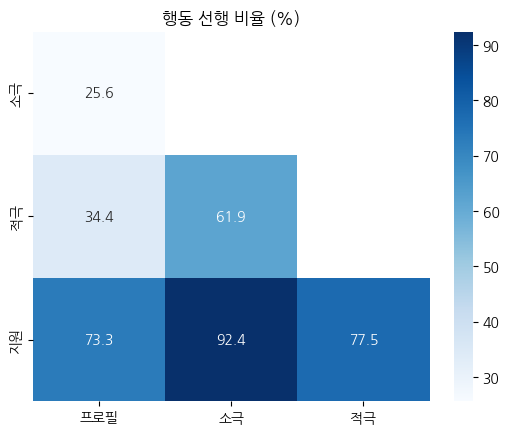

In [ ]:
heatmap_df = pd.DataFrame({
    '프로필': {
        '소극': results.loc['프로필 vs 소극']['first_profile_ts 먼저 (%)'],
        '적극': results.loc['프로필 vs 적극']['first_profile_ts 먼저 (%)'],
        '지원': results.loc['프로필 vs 지원']['first_profile_ts 먼저 (%)']
    },
    '소극': {
        '적극': results.loc['소극 vs 적극']['first_passive_network_ts 먼저 (%)'],
        '지원': results.loc['소극 vs 지원']['first_passive_network_ts 먼저 (%)']
    },
    '적극': {
        '지원': results.loc['적극 vs 지원']['first_active_network_ts 먼저 (%)']
    }
})

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='Blues',
    fmt='.1f'
)

plt.title('행동 선행 비율 (%)')
plt.show()

=== 네트워킹 세그먼트 분포 ===
                               count     %
network_segment                           
1. 네트워크 핵심 유저 (The Connector)   6539  30.8
2. 탐색형 네트워킹 (The Observer)      3076  14.5
3. 목적형 네트워킹 (The Spontaneous)    255   1.2
4. 관망형 유저 (The Lurker)          2863  13.5
5. 휴면 유저 (The Sleeper)          3329  15.7
6. 이탈 유저 (The Churned)          5159  24.3

=== 세그먼트별 평균 점수 ===
                               R_score  passive_network_score  \
network_segment                                                 
1. 네트워크 핵심 유저 (The Connector)     4.18                   4.36   
2. 탐색형 네트워킹 (The Observer)        3.91                   3.61   
3. 목적형 네트워킹 (The Spontaneous)     3.84                   1.92   
4. 관망형 유저 (The Lurker)            3.71                   1.59   
5. 휴면 유저 (The Sleeper)            1.65                   3.53   
6. 이탈 유저 (The Churned)            1.40                   1.41   

                               active_network_score  
network_segment                        

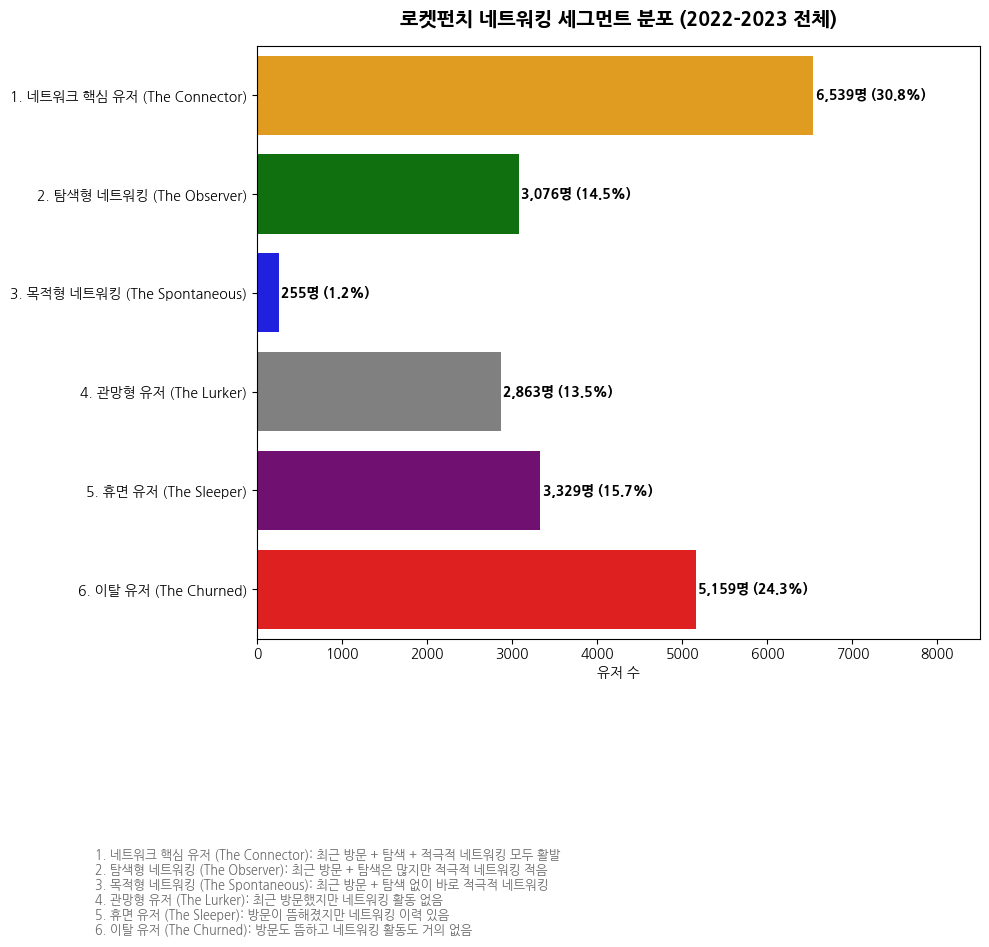

In [ ]:
# =========================================================================
#  네트워킹 세그먼트 + 시각화
# =========================================================================

def assign_network_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_network_score'] >= 3.0
    is_high_active  = row['active_network_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 네트워크 핵심 유저 (The Connector)'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색형 네트워킹 (The Observer)'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적형 네트워킹 (The Spontaneous)'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 관망형 유저 (The Lurker)'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저 (The Sleeper)'
    else:
        return '6. 이탈 유저 (The Churned)'

df_raw['network_segment'] = df_raw.apply(assign_network_segment, axis=1)

net_counts = df_raw['network_segment'].value_counts().sort_index()
net_pct    = df_raw['network_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 네트워킹 세그먼트 분포 ===")
print(pd.DataFrame({'count': net_counts, '%': net_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('network_segment')[
    ['R_score', 'passive_network_score', 'active_network_score']
].mean().round(2))

color_map_net = {
    '1. 네트워크 핵심 유저 (The Connector)': 'orange',
    '2. 탐색형 네트워킹 (The Observer)':     'green',
    '3. 목적형 네트워킹 (The Spontaneous)':  'blue',
    '4. 관망형 유저 (The Lurker)':           'gray',
    '5. 휴면 유저 (The Sleeper)':            'purple',
    '6. 이탈 유저 (The Churned)':            'red',
}

segment_desc_net = {
    '1. 네트워크 핵심 유저 (The Connector)': '최근 방문 + 탐색 + 적극적 네트워킹 모두 활발',
    '2. 탐색형 네트워킹 (The Observer)':     '최근 방문 + 탐색은 많지만 적극적 네트워킹 적음',
    '3. 목적형 네트워킹 (The Spontaneous)':  '최근 방문 + 탐색 없이 바로 적극적 네트워킹',
    '4. 관망형 유저 (The Lurker)':           '최근 방문했지만 네트워킹 활동 없음',
    '5. 휴면 유저 (The Sleeper)':            '방문이 뜸해졌지만 네트워킹 이력 있음',
    '6. 이탈 유저 (The Churned)':            '방문도 뜸하고 네트워킹 활동도 거의 없음',
}


fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=net_counts.values, y=net_counts.index,
            hue=net_counts.index, palette=color_map_net, legend=False, ax=ax)
total = net_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, net_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 네트워킹 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_net.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

=== 구직활동 세그먼트 분포 ===
                              count     %
job_segment                              
1. 적극적 구직자 (The Active)        6323  29.8
2. 탐색형 구직자 (The Browser)       3068  14.5
3. 목적형 구직자 (The Spontaneous)    118   0.6
4. 관망형 유저 (The Lurker)         3224  15.2
5. 휴면 유저 (The Sleeper)         3543  16.7
6. 이탈 유저 (The Churned)         4945  23.3

=== 세그먼트별 평균 점수 ===
                              R_score  passive_job_score  active_job_score
job_segment                                                               
1. 적극적 구직자 (The Active)          4.15               4.38              4.56
2. 탐색형 구직자 (The Browser)         3.98               3.53              2.43
3. 목적형 구직자 (The Spontaneous)     3.79               1.93              4.11
4. 관망형 유저 (The Lurker)           3.74               1.58              1.76
5. 휴면 유저 (The Sleeper)           1.62               3.61              3.54
6. 이탈 유저 (The Churned)           1.41               1.42              1.76


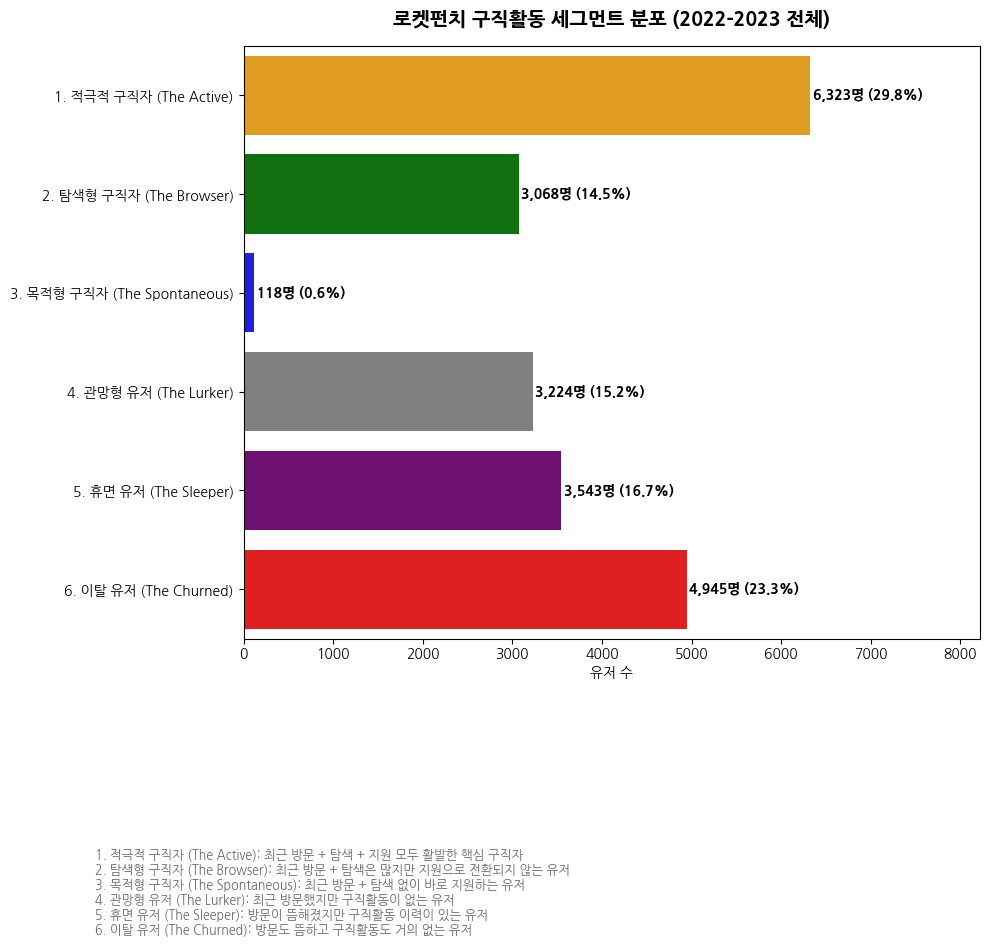

In [ ]:
# =========================================================================
# 구직활동 세그먼트 + 시각화
# =========================================================================

def assign_job_segment(row):
    is_recent       = row['R_score'] >= 3.0
    is_high_passive = row['passive_job_score'] >= 3.0
    is_high_active  = row['active_job_score'] >= 4.0

    if is_recent and is_high_passive and is_high_active:
        return '1. 적극적 구직자 (The Active)'
    elif is_recent and is_high_passive and not is_high_active:
        return '2. 탐색형 구직자 (The Browser)'
    elif is_recent and not is_high_passive and is_high_active:
        return '3. 목적형 구직자 (The Spontaneous)'
    elif is_recent and not is_high_passive and not is_high_active:
        return '4. 관망형 유저 (The Lurker)'
    elif not is_recent and (is_high_passive or is_high_active):
        return '5. 휴면 유저 (The Sleeper)'
    else:
        return '6. 이탈 유저 (The Churned)'

df_raw['job_segment'] = df_raw.apply(assign_job_segment, axis=1)

job_counts = df_raw['job_segment'].value_counts().sort_index()
job_pct    = df_raw['job_segment'].value_counts(normalize=True).sort_index().mul(100).round(1)
print("=== 구직활동 세그먼트 분포 ===")
print(pd.DataFrame({'count': job_counts, '%': job_pct}))

print("\n=== 세그먼트별 평균 점수 ===")
print(df_raw.groupby('job_segment')[
    ['R_score', 'passive_job_score', 'active_job_score']
].mean().round(2))

color_map_job = {
    '1. 적극적 구직자 (The Active)':      'orange',
    '2. 탐색형 구직자 (The Browser)':     'green',
    '3. 목적형 구직자 (The Spontaneous)': 'blue',
    '4. 관망형 유저 (The Lurker)':        'gray',
    '5. 휴면 유저 (The Sleeper)':         'purple',
    '6. 이탈 유저 (The Churned)':         'red',
}

segment_desc_job = {
    '1. 적극적 구직자 (The Active)':      '최근 방문 + 탐색 + 지원 모두 활발한 핵심 구직자',
    '2. 탐색형 구직자 (The Browser)':     '최근 방문 + 탐색은 많지만 지원으로 전환되지 않는 유저',
    '3. 목적형 구직자 (The Spontaneous)': '최근 방문 + 탐색 없이 바로 지원하는 유저',
    '4. 관망형 유저 (The Lurker)':        '최근 방문했지만 구직활동이 없는 유저',
    '5. 휴면 유저 (The Sleeper)':         '방문이 뜸해졌지만 구직활동 이력이 있는 유저',
    '6. 이탈 유저 (The Churned)':         '방문도 뜸하고 구직활동도 거의 없는 유저',
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=job_counts.values, y=job_counts.index,
            hue=job_counts.index, palette=color_map_job, legend=False, ax=ax)
total = job_counts.sum()
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}명 ({width/total*100:.1f}%)',
                va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, job_counts.max() * 1.3)
ax.set_xlabel('유저 수')
ax.set_ylabel('')
plt.title('로켓펀치 구직활동 세그먼트 분포 (2022-2023 전체)',
          fontsize=14, fontweight='bold', pad=15)
desc_text = '\n'.join([f'{k}: {v}' for k, v in segment_desc_job.items()])
plt.figtext(0.1, -0.22, desc_text, fontsize=9, verticalalignment='top', color='dimgray')
plt.tight_layout()
plt.show()

=== 구직활동 × 네트워킹 세그먼트 교차표 ===


network_segment,1. 네트워크 핵심 유저 (The Connector),2. 탐색형 네트워킹 (The Observer),3. 목적형 네트워킹 (The Spontaneous),4. 관망형 유저 (The Lurker),5. 휴면 유저 (The Sleeper),6. 이탈 유저 (The Churned)
job_segment,,,,,,
1. 적극적 구직자 (The Active),5274,745,148,156,0,0
2. 탐색형 구직자 (The Browser),1029,1482,36,521,0,0
3. 목적형 구직자 (The Spontaneous),27,21,26,44,0,0
4. 관망형 유저 (The Lurker),209,828,45,2142,0,0
5. 휴면 유저 (The Sleeper),0,0,0,0,2634,909
6. 이탈 유저 (The Churned),0,0,0,0,695,4250


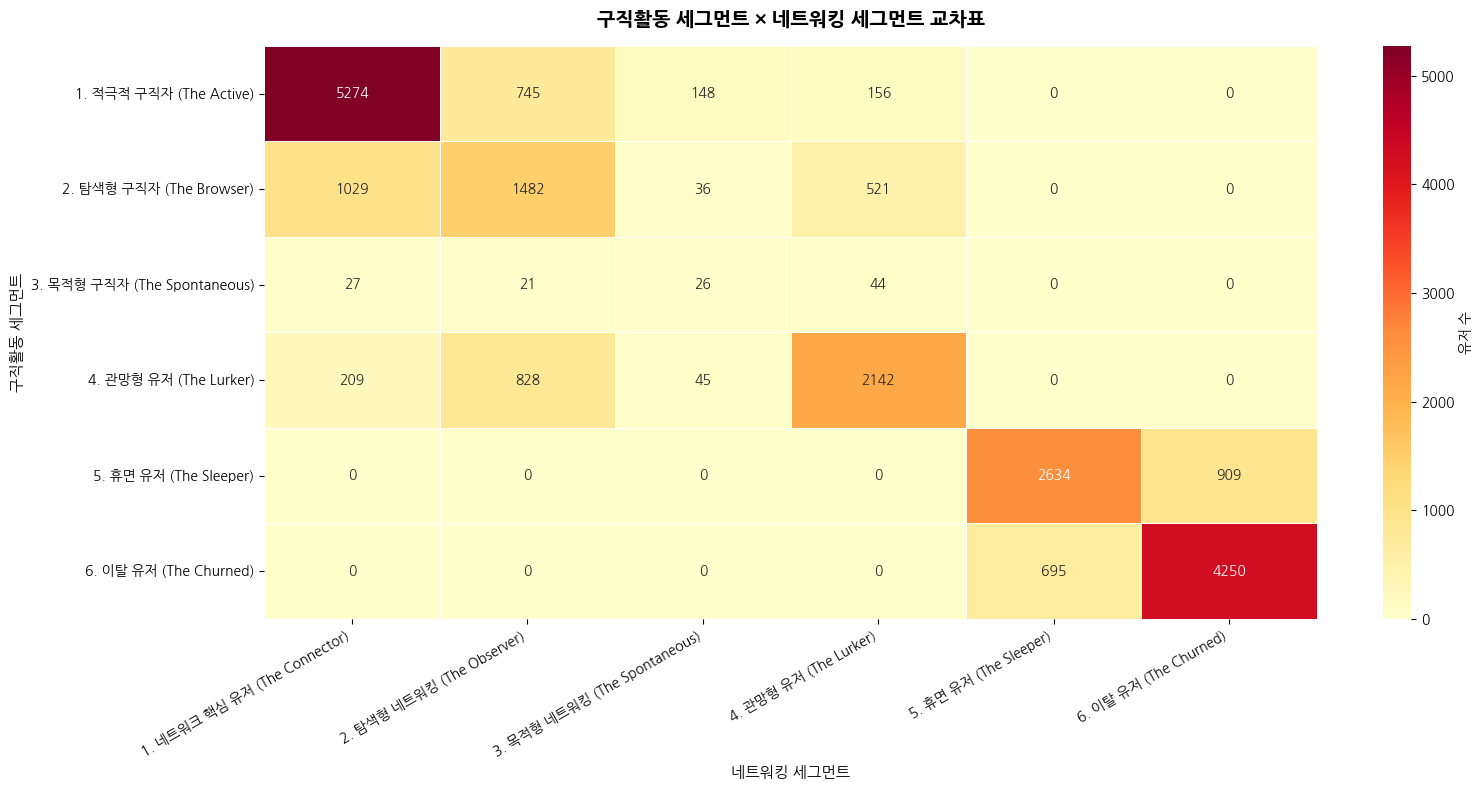

In [ ]:
#=========================================================================
# 교차표 + 히트맵
#=========================================================================
print("=== 구직활동 × 네트워킹 세그먼트 교차표 ===")
cross = pd.crosstab(df_raw['job_segment'], df_raw['network_segment'])
display(cross)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '유저 수'}
)
plt.title('구직활동 세그먼트 × 네트워킹 세그먼트 교차표',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('네트워킹 세그먼트', fontsize=11)
plt.ylabel('구직활동 세그먼트', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== 구직활동 × 네트워킹 세그먼트 교차표 (비율) ===


network_segment,1. 네트워크 핵심 유저 (The Connector),2. 탐색형 네트워킹 (The Observer),3. 목적형 네트워킹 (The Spontaneous),4. 관망형 유저 (The Lurker),5. 휴면 유저 (The Sleeper),6. 이탈 유저 (The Churned)
job_segment,,,,,,
1. 적극적 구직자 (The Active),83.4,11.8,2.3,2.5,0.0,0.0
2. 탐색형 구직자 (The Browser),33.5,48.3,1.2,17.0,0.0,0.0
3. 목적형 구직자 (The Spontaneous),22.9,17.8,22.0,37.3,0.0,0.0
4. 관망형 유저 (The Lurker),6.5,25.7,1.4,66.4,0.0,0.0
5. 휴면 유저 (The Sleeper),0.0,0.0,0.0,0.0,74.3,25.7
6. 이탈 유저 (The Churned),0.0,0.0,0.0,0.0,14.1,85.9


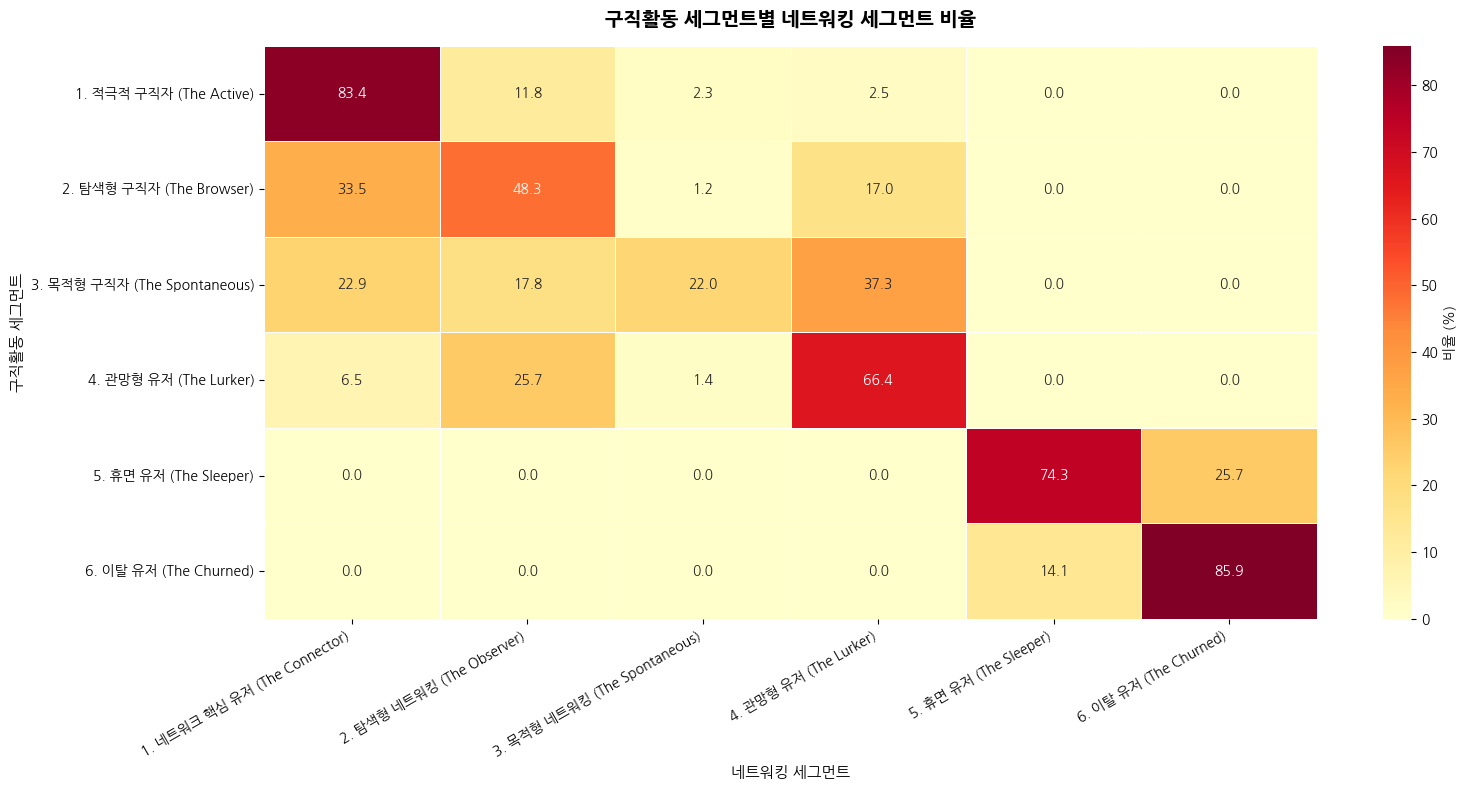

In [ ]:
print("=== 구직활동 × 네트워킹 세그먼트 교차표 (비율) ===")

cross = (
    pd.crosstab(
        df_raw['job_segment'],
        df_raw['network_segment'],
        normalize='index'
    ) * 100
).round(1)

display(cross)

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    cross,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '비율 (%)'}
)

plt.title(
    '구직활동 세그먼트별 네트워킹 세그먼트 비율',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('네트워킹 세그먼트', fontsize=11)
plt.ylabel('구직활동 세그먼트', fontsize=11)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df_raw['cross_segment'] = (
    df_raw['job_segment']
    + ' × '
    + df_raw['network_segment']
)

In [ ]:
cross_count = (
    df_raw['cross_segment']
    .value_counts()
    .reset_index()
)

cross_count.columns = ['cross_segment', 'user_count']

display(cross_count.head(20))

,cross_segment,user_count
0,1. 적극적 구직자 (The Active) × 1. 네트워크 핵심 유저 (The C...,5274
1,6. 이탈 유저 (The Churned) × 6. 이탈 유저 (The Churned),4250
2,5. 휴면 유저 (The Sleeper) × 5. 휴면 유저 (The Sleeper),2634
3,4. 관망형 유저 (The Lurker) × 4. 관망형 유저 (The Lurker),2142
4,2. 탐색형 구직자 (The Browser) × 2. 탐색형 네트워킹 (The Ob...,1482
5,2. 탐색형 구직자 (The Browser) × 1. 네트워크 핵심 유저 (The ...,1029
6,5. 휴면 유저 (The Sleeper) × 6. 이탈 유저 (The Churned),909
7,4. 관망형 유저 (The Lurker) × 2. 탐색형 네트워킹 (The Obse...,828
8,1. 적극적 구직자 (The Active) × 2. 탐색형 네트워킹 (The Obs...,745
9,6. 이탈 유저 (The Churned) × 5. 휴면 유저 (The Sleeper),695


In [ ]:
top_cross = cross_count.head(10)

display(top_cross)

,cross_segment,user_count
0,1. 적극적 구직자 (The Active) × 1. 네트워크 핵심 유저 (The C...,5274
1,6. 이탈 유저 (The Churned) × 6. 이탈 유저 (The Churned),4250
2,5. 휴면 유저 (The Sleeper) × 5. 휴면 유저 (The Sleeper),2634
3,4. 관망형 유저 (The Lurker) × 4. 관망형 유저 (The Lurker),2142
4,2. 탐색형 구직자 (The Browser) × 2. 탐색형 네트워킹 (The Ob...,1482
5,2. 탐색형 구직자 (The Browser) × 1. 네트워크 핵심 유저 (The ...,1029
6,5. 휴면 유저 (The Sleeper) × 6. 이탈 유저 (The Churned),909
7,4. 관망형 유저 (The Lurker) × 2. 탐색형 네트워킹 (The Obse...,828
8,1. 적극적 구직자 (The Active) × 2. 탐색형 네트워킹 (The Obs...,745
9,6. 이탈 유저 (The Churned) × 5. 휴면 유저 (The Sleeper),695


In [ ]:
df_analysis = df.merge(
    df_raw[['user_uuid', 'cross_segment']],
    on='user_uuid',
    how='left'
)

In [ ]:
# 교차세그먼트별 기본 프로파일
cross_profile = (
    df_raw
    .groupby('cross_segment')
    .agg(
        user_count=('user_uuid', 'count'),
        avg_recency_days=('R_raw', 'mean'),
        avg_passive_network=('passive_network_raw', 'mean'),
        avg_active_network=('active_network_raw', 'mean'),
        avg_passive_job=('passive_job_raw', 'mean'),
        avg_active_job=('active_job_raw', 'mean')
    )
    .round(2)
    .sort_values('user_count', ascending=False)
)

display(cross_profile.head(10))

,user_count,avg_recency_days,avg_passive_network,avg_active_network,avg_passive_job,avg_active_job
cross_segment,,,,,,
1. 적극적 구직자 (The Active) × 1. 네트워크 핵심 유저 (The Connector),5274,84.26,437.52,125.71,609.53,156.90
6. 이탈 유저 (The Churned) × 6. 이탈 유저 (The Churned),4250,518.94,11.58,2.88,5.25,0.83
5. 휴면 유저 (The Sleeper) × 5. 휴면 유저 (The Sleeper),2634,424.85,165.11,52.92,230.04,61.68
4. 관망형 유저 (The Lurker) × 4. 관망형 유저 (The Lurker),2142,138.53,15.88,3.82,6.47,0.71
2. 탐색형 구직자 (The Browser) × 2. 탐색형 네트워킹 (The Observer),1482,111.50,172.10,13.89,152.75,4.42
2. 탐색형 구직자 (The Browser) × 1. 네트워크 핵심 유저 (The Connector),1029,86.65,351.74,89.49,200.38,6.65
5. 휴면 유저 (The Sleeper) × 6. 이탈 유저 (The Churned),909,477.64,23.74,11.15,65.97,14.01
4. 관망형 유저 (The Lurker) × 2. 탐색형 네트워킹 (The Observer),828,125.60,102.30,10.58,13.08,0.69
1. 적극적 구직자 (The Active) × 2. 탐색형 네트워킹 (The Observer),745,103.71,173.63,23.05,285.27,41.84


In [ ]:
application = pd.read_csv(
    '/content/drive/MyDrive/application.csv',
    low_memory=False
)

print(application.shape)

application['cdate'] = pd.to_datetime(
    application['cdate'],
    errors='coerce'
)

application = application[
    (application['cdate'] >= '2022-01-01') &
    (application['cdate'] < '2024-01-01')
].copy()

print(f'2022~2023 지원 건수: {len(application):,}')
print(f'지원 유저 수: {application["user_uuid"].nunique():,}')

(340730, 5)
2022~2023 지원 건수: 92,514
지원 유저 수: 10,285


In [ ]:
job = pd.read_csv(
    '/content/drive/MyDrive/공고_clean.csv',
    low_memory=False
)

print(job.shape)

(139764, 10)


In [ ]:
company = pd.read_csv(
    '/content/drive/MyDrive/기업_클러스터링.csv',
    low_memory=False
)

print(company.shape)

(41612, 20)


In [ ]:
app_cross = application.merge(
    df_raw[
        [
            'user_uuid',
            'cross_segment',
            'job_segment',
            'network_segment'
        ]
    ],
    on='user_uuid',
    how='left'
)

print(app_cross.shape)

(92514, 8)


In [ ]:
app_job = app_cross.merge(
    job,
    on='job_uuid',
    how='left'
)

print(app_job.shape)

(92514, 17)


In [ ]:
# app_job 안의 company_uuid 정리
app_job['company_uuid'] = app_job['company_uuid_y'].fillna(app_job['company_uuid_x'])

# 필요하면 기존 x, y 컬럼 제거
app_job = app_job.drop(columns=['company_uuid_x', 'company_uuid_y'])

# company 클러스터링 파일과 병합
app_final = app_job.merge(
    company,
    on='company_uuid',
    how='left'
)

print(app_final.shape)
print(app_final['company_uuid'].isna().sum())

(92514, 35)
0


In [ ]:
print(app_final.shape)

print(
    app_final['pop_cluster']
    .value_counts(dropna=False)
    .head()
)

(92514, 35)
pop_cluster
3.0    71472
1.0    17334
NaN     2953
0.0      731
2.0       24
Name: count, dtype: int64


In [ ]:
#교차 세그 지원
segment_size = (
    df_raw[['user_uuid','cross_segment']]
    .drop_duplicates()
    .groupby('cross_segment')
    .size()
    .reset_index(name='segment_users')
)

support = (
    app_final.groupby('cross_segment')['user_uuid']
    .nunique()
    .reset_index(name='apply_users')
)

conversion = segment_size.merge(
    support,
    on='cross_segment',
    how='left'
)

conversion['apply_rate'] = (
    conversion['apply_users']
    / conversion['segment_users']
    *100
)

conversion.sort_values(
    'apply_rate',
    ascending=False
)

,cross_segment,segment_users,apply_users,apply_rate
8,3. 목적형 구직자 (The Spontaneous) × 1. 네트워크 핵심 유저 (...,27,27,100.000000
9,3. 목적형 구직자 (The Spontaneous) × 2. 탐색형 네트워킹 (Th...,21,21,100.000000
2,1. 적극적 구직자 (The Active) × 3. 목적형 네트워킹 (The Spo...,148,147,99.324324
11,3. 목적형 구직자 (The Spontaneous) × 4. 관망형 유저 (The ...,44,43,97.727273
3,1. 적극적 구직자 (The Active) × 4. 관망형 유저 (The Lurker),156,151,96.794872
0,1. 적극적 구직자 (The Active) × 1. 네트워크 핵심 유저 (The C...,5274,5082,96.359499
10,3. 목적형 구직자 (The Spontaneous) × 3. 목적형 네트워킹 (Th...,26,25,96.153846
1,1. 적극적 구직자 (The Active) × 2. 탐색형 네트워킹 (The Obs...,745,668,89.664430
16,5. 휴면 유저 (The Sleeper) × 5. 휴면 유저 (The Sleeper),2634,2037,77.334852
6,2. 탐색형 구직자 (The Browser) × 3. 목적형 네트워킹 (The Sp...,36,24,66.666667


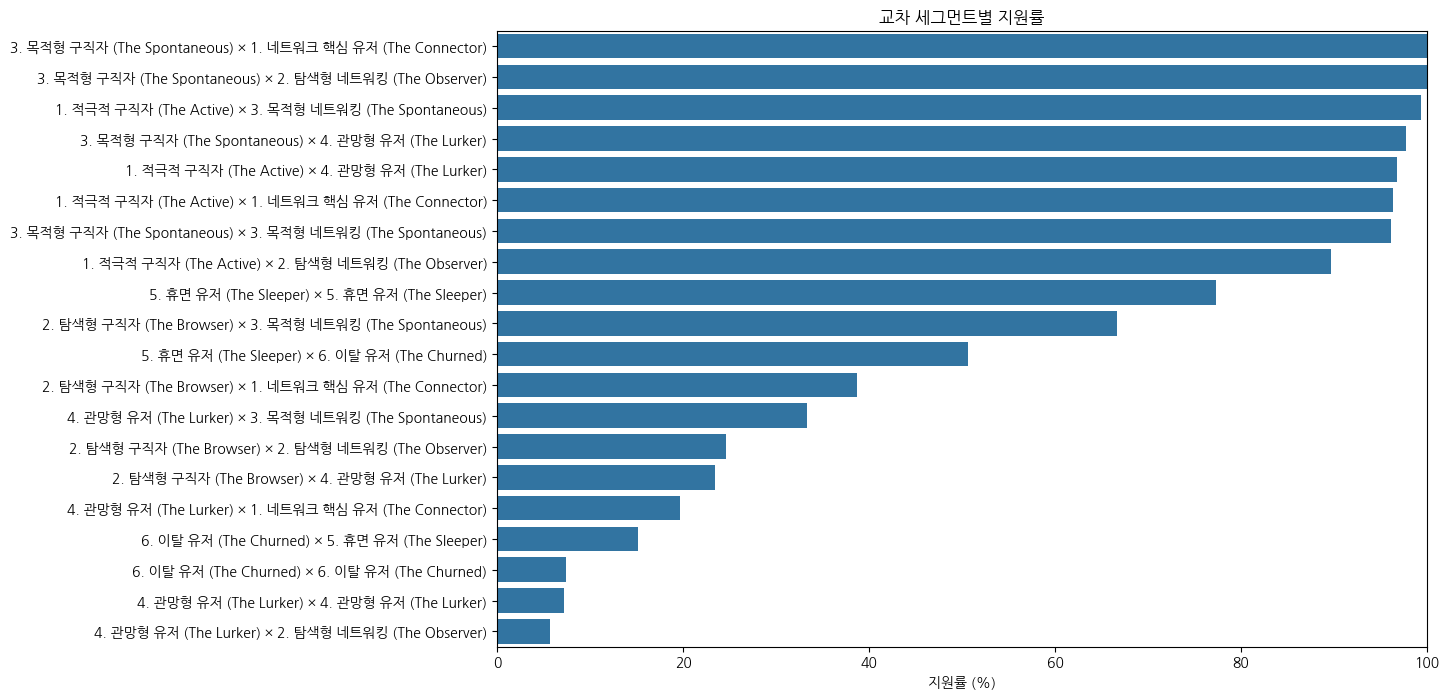

In [ ]:
#지원률 막대 그래프
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = conversion.sort_values(
    'apply_rate',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=plot_df,
    y='cross_segment',
    x='apply_rate'
)

plt.xlabel('지원률 (%)')
plt.ylabel('')
plt.title('교차 세그먼트별 지원률')

plt.xlim(0,100)

plt.show()

plot_df 컬럼 목록:
Index(['cross_segment', 'segment_users', 'apply_users', 'apply_rate'], dtype='object')

원본 세그먼트 vs 축약 라벨
                                        cross_segment  label
8   3. 목적형 구직자 (The Spontaneous) × 1. 네트워크 핵심 유저 (...  목적×핵심
9   3. 목적형 구직자 (The Spontaneous) × 2. 탐색형 네트워킹 (Th...  목적×탐색
2   1. 적극적 구직자 (The Active) × 3. 목적형 네트워킹 (The Spo...  적극×목적
11  3. 목적형 구직자 (The Spontaneous) × 4. 관망형 유저 (The ...  목적×관망
3    1. 적극적 구직자 (The Active) × 4. 관망형 유저 (The Lurker)  적극×관망
0   1. 적극적 구직자 (The Active) × 1. 네트워크 핵심 유저 (The C...  적극×핵심
10  3. 목적형 구직자 (The Spontaneous) × 3. 목적형 네트워킹 (Th...  목적×목적
1   1. 적극적 구직자 (The Active) × 2. 탐색형 네트워킹 (The Obs...  적극×탐색
16    5. 휴면 유저 (The Sleeper) × 5. 휴면 유저 (The Sleeper)  휴면×휴면
6   2. 탐색형 구직자 (The Browser) × 3. 목적형 네트워킹 (The Sp...  탐색×목적
17    5. 휴면 유저 (The Sleeper) × 6. 이탈 유저 (The Churned)  휴면×이탈
4   2. 탐색형 구직자 (The Browser) × 1. 네트워크 핵심 유저 (The ...  탐색×핵심
14  4. 관망형 유저 (The Lurker) × 3. 목적형 네트워킹 (The Spon...  관망×목적
5   2. 탐색형 구직자 (The Browse

/tmp/ipykernel_5091/1261202980.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


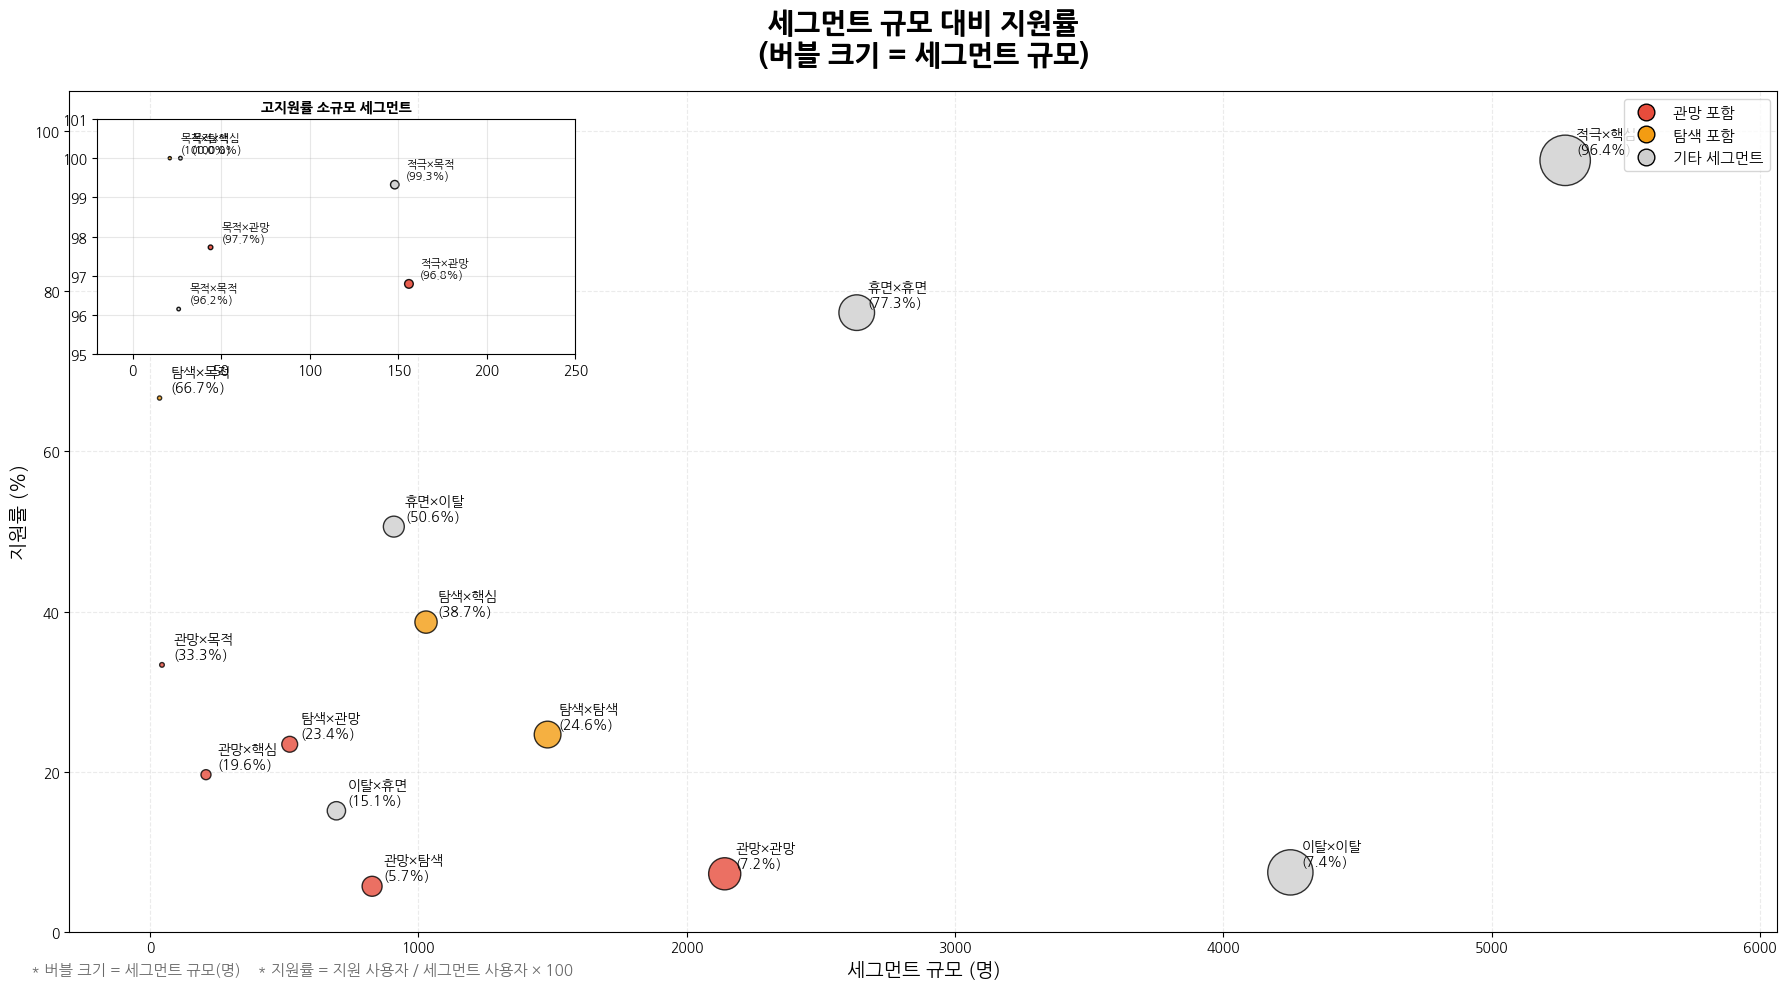

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import pandas as pd
import re

# =====================
# plot_df 안전 복사
# =====================
plot_df = plot_df.copy()

# =====================
# 컬럼 확인
# =====================
print("plot_df 컬럼 목록:")
print(plot_df.columns)

# =====================
# 필수 컬럼 확인
# =====================
required_cols = ['cross_segment', 'segment_users', 'apply_users', 'apply_rate']
missing_cols = [col for col in required_cols if col not in plot_df.columns]

if missing_cols:
    raise KeyError(f"plot_df에 필요한 컬럼이 없습니다: {missing_cols}")

# =====================
# 긴 세그먼트명을 짧게 줄이는 함수
# =====================
def short_part(part):
    part = str(part)

    # 앞 번호 제거 (예: "4. ")
    part = re.sub(r'^\s*\d+\.\s*', '', part)

    # 영어 설명 제거 (예: "(The Lurker)")
    part = re.sub(r'\s*\(.*?\)', '', part)

    # 짧은 이름 매핑
    short_map = [
        ('적극적 구직자', '적극'),
        ('탐색형 구직자', '탐색'),
        ('목적형 구직자', '목적'),
        ('휴면 유저', '휴면'),
        ('이탈 유저', '이탈'),

        ('네트워크 핵심 유저', '핵심'),
        ('조용한 탐색 유저', '탐색'),
        ('탐색형 네트워킹', '탐색'),
        ('목적형 네트워커', '목적'),
        ('목적형 네트워킹', '목적'),
        ('관망형 유저', '관망'),
        ('잠재 복귀 유저', '관망'),
        ('이탈 위험 유저', '이탈')
    ]

    for long_name, short_name in short_map:
        if long_name in part:
            return short_name

    return part.strip()

def make_short_label(segment):
    segment = str(segment)

    # × 또는 x 기준으로 분리
    parts = re.split(r'\s*[×xX]\s*', segment)

    if len(parts) == 2:
        left = short_part(parts[0])
        right = short_part(parts[1])
        return f"{left}×{right}"
    else:
        return short_part(segment)

# =====================
# 짧은 라벨 생성
# =====================
plot_df['label'] = plot_df['cross_segment'].apply(make_short_label)

print("\n원본 세그먼트 vs 축약 라벨")
print(plot_df[['cross_segment', 'label']])

# =====================
# 색상 생성
# - 관망 포함: 빨강
# - 탐색 포함: 주황
# - 기타: 회색
# =====================
def assign_color(label):
    label = str(label)

    if '관망' in label:
        return '#E74C3C'   # 빨강
    elif '탐색' in label:
        return '#F39C12'   # 주황
    else:
        return '#CFCFCF'   # 회색

plot_df['color'] = plot_df['label'].apply(assign_color)

print("\n색상 매핑 확인")
print(plot_df[['label', 'color']].drop_duplicates())

# =====================
# 그래프 시작
# =====================
fig, ax = plt.subplots(figsize=(18, 10))

# =====================
# 메인 버블차트
# =====================
ax.scatter(
    plot_df['segment_users'],
    plot_df['apply_rate'],
    s=plot_df['segment_users'] * 0.25,
    c=plot_df['color'],
    edgecolors='black',
    linewidths=1,
    alpha=0.8
)

# =====================
# 메인 라벨
# =====================
for _, row in plot_df.iterrows():

    # 확대 영역에 들어갈 애들은 메인에서는 라벨 생략
    if (row['segment_users'] < 300) and (row['apply_rate'] > 90):
        continue

    ax.annotate(
        f"{row['label']}\n({row['apply_rate']:.1f}%)",
        (row['segment_users'], row['apply_rate']),
        xytext=(8, 5),
        textcoords='offset points',
        fontsize=10
    )

# =====================
# Inset 확대 영역
# =====================
zoom_mask = (
    (plot_df['segment_users'] < 300) &
    (plot_df['apply_rate'] > 90)
)

zoom_df = plot_df[zoom_mask].copy()

axins = inset_axes(
    ax,
    width="28%",
    height="28%",
    loc='upper left',
    borderpad=2
)

if len(zoom_df) > 0:
    axins.scatter(
        zoom_df['segment_users'],
        zoom_df['apply_rate'],
        s=zoom_df['segment_users'] * 0.25,
        c=zoom_df['color'],
        edgecolors='black',
        linewidths=1,
        alpha=0.9
    )

    for _, row in zoom_df.iterrows():
        axins.annotate(
            f"{row['label']}\n({row['apply_rate']:.1f}%)",
            (row['segment_users'], row['apply_rate']),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=8
        )
else:
    axins.text(
        0.5, 0.5, '확대 대상 없음',
        ha='center', va='center',
        transform=axins.transAxes,
        fontsize=9
    )

# 확대 범위 설정
axins.set_xlim(-20, 250)
axins.set_ylim(95, 101)

axins.set_title(
    '고지원률 소규모 세그먼트',
    fontsize=10,
    fontweight='bold'
)

axins.grid(alpha=0.3)

# 확대 영역 표시
if len(zoom_df) > 0:
    ax.indicate_inset_zoom(
        axins,
        edgecolor='gray',
        alpha=0.7
    )

# =====================
# 축 설정
# =====================
ax.set_xlim(-300, plot_df['segment_users'].max() * 1.15)
ax.set_ylim(0, 105)

ax.set_xlabel(
    '세그먼트 규모 (명)',
    fontsize=14
)

ax.set_ylabel(
    '지원률 (%)',
    fontsize=14
)

ax.set_title(
    '세그먼트 규모 대비 지원률\n(버블 크기 = 세그먼트 규모)',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.grid(alpha=0.25, linestyle='--')
ax.set_axisbelow(True)

# =====================
# 범례
# =====================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='관망 포함',
        markerfacecolor='#E74C3C',
        markeredgecolor='black',
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='탐색 포함',
        markerfacecolor='#F39C12',
        markeredgecolor='black',
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='기타 세그먼트',
        markerfacecolor='#CFCFCF',
        markeredgecolor='black',
        markersize=12
    )
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=11
)

# =====================
# 하단 설명
# =====================
fig.text(
    0.02,
    0.02,
    '* 버블 크기 = 세그먼트 규모(명)    * 지원률 = 지원 사용자 / 세그먼트 사용자 × 100',
    fontsize=11,
    color='dimgray'
)

plt.tight_layout()
plt.show()

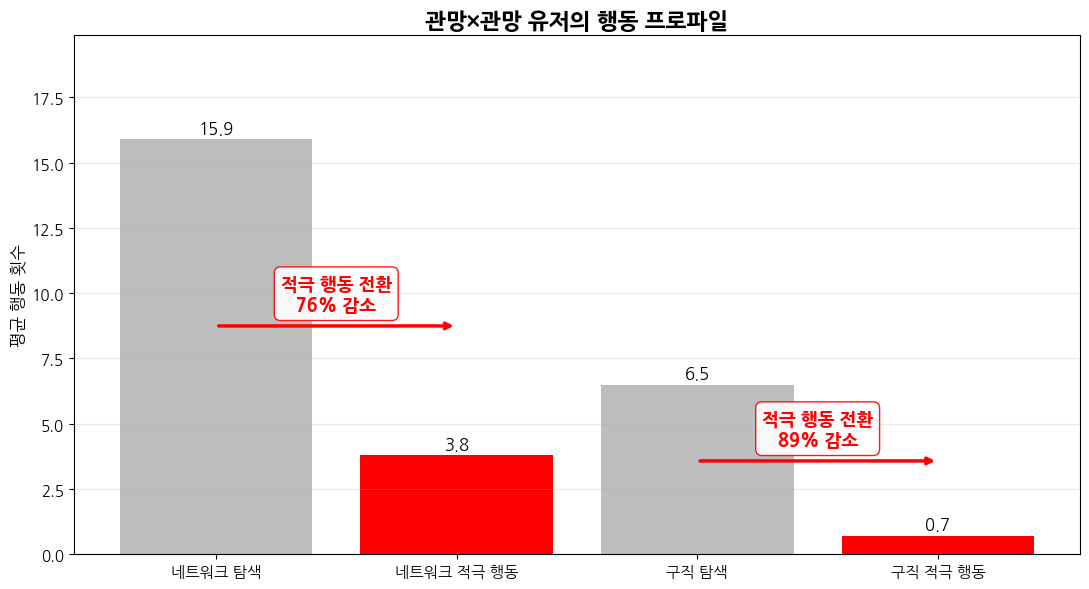

In [ ]:
import matplotlib.pyplot as plt

labels = ['네트워크 탐색', '네트워크 적극 행동', '구직 탐색', '구직 적극 행동']
values = [15.9, 3.8, 6.5, 0.7]
colors = ['#BDBDBD', '#FF0000', '#BDBDBD', '#FF0000']

plt.figure(figsize=(11, 6))
bars = plt.bar(labels, values, color=colors)

# 막대 위 수치
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.25,
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=12
    )

# 감소율 계산
network_drop = (1 - values[1] / values[0]) * 100
job_drop = (1 - values[3] / values[2]) * 100

# 화살표 + 감소율 강조
pairs = [
    (0, 1, values[0], values[1], network_drop),
    (2, 3, values[2], values[3], job_drop)
]

for left_i, right_i, left_v, right_v, drop in pairs:
    x1 = bars[left_i].get_x() + bars[left_i].get_width()/2
    x2 = bars[right_i].get_x() + bars[right_i].get_width()/2
    y = max(left_v, right_v) * 0.55

    plt.annotate(
        '',
        xy=(x2, y),
        xytext=(x1, y),
        arrowprops=dict(
            arrowstyle='->',
            color='red',
            lw=2.5
        )
    )

    plt.text(
        (x1 + x2) / 2,
        y + 0.45,
        f'적극 행동 전환\n{drop:.0f}% 감소',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='red',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            edgecolor='red',
            alpha=0.9
        )
    )

plt.title('관망×관망 유저의 행동 프로파일', fontsize=16, fontweight='bold')
plt.ylabel('평균 행동 횟수', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.25)
plt.ylim(0, max(values) * 1.25)
plt.tight_layout()
plt.show()

In [ ]:
#카이제곱 검정
# H0(귀무가설) : 네트워킹 세그먼트와 구직활동 세그먼트는 독립적이다.
# H1(대립가설) : 네트워킹 세그먼트와 구직활동 세그먼트는 관련이 있다.

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cross)

print(f'카이제곱 통계량: {chi2:.2f}')
print(f'p-value: {p:.20f}')
print(f'자유도: {dof}')

카이제곱 통계량: 1181.46
p-value: 0.00000000000000000000
자유도: 25


In [ ]:
import numpy as np

n = cross.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(cross.shape) - 1))
)

print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.628


## 타켓 세그먼트 : 관망형 유저
### 타켓 세그먼트 : 관망형 네트워크 유저 x 관망형 구직자
#### 특징
*   공고 탐색 행동은 활발함
*   하지만 실제 지원 행동은 낮음
*   실제 네트워킹 행동 역시 낮음

---

#### 가설 : 관심은 있지만, 첫 행동을 시작하지 못한다.
##### 근거 1. 구직 행동 분석
*   passive_job_row = 6.47
*   active_job_raw = 0.71
###### -> 공고를 읽고 탐색하는 행동은 존재하나, 실제 지원으로 이어지지 않음

---

##### 근거 2. 네트워킹 행동 분석
*   전분문야 추천 조회 -> 5,291회
*   친구 요청 버튼 클릭 -> 857회
*   추천 요청 템플릿 진입 -> 248회
*   실제 추천 요청 발송 -> 43회
###### -> 사람은 찾지만 실제 연결 행동은 거의 없음

---

#### 전략 1. '가벼운 네트워킹 경험' 제공
##### 현직자 연결 시작 유도







# B)기업 분석

## 기업

In [ ]:
company_df = pd.read_csv("/content/drive/MyDrive/기업 리스트.csv")

In [ ]:
company_df.head()

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid
0,2022-06-09 04:08:40,2022-06-09 04:08:40,NaN,0명,0,0,0,c46f2fa5-f940-40fb-bd4a-aa0ff7a837fd
1,2017-05-22 10:57:12,2022-07-25 00:12:02,NaN,0명,256,0,0,725e87bb-de2f-416a-a6b8-1ca8d0d096e0
2,2017-11-14 11:42:55,2022-11-04 03:29:16,NaN,0명,256,0,0,efa3747d-9bbd-4c84-af51-82ccf6545dcd
3,2017-11-27 10:59:30,2021-01-17 14:42:06,NaN,0명,256,0,0,84aa2c20-d0f3-4ec3-ac06-1ef67e071b8f
4,2018-01-08 14:41:58,2022-07-25 01:34:16,2018-01-08,0명,256,0,0,761e76b3-507c-4c8f-b96f-fa47a8ccb5f2


In [ ]:
company_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41659 entries, 0 to 41658
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cdate            41659 non-null  object
 1   mdate            41659 non-null  object
 2   found_date       17484 non-null  object
 3   employee_count   41659 non-null  object
 4   view_count       41659 non-null  int64 
 5   follow_count     41659 non-null  int64 
 6   reference_count  41659 non-null  int64 
 7   company_uuid     41659 non-null  object
dtypes: int64(3), object(5)
memory usage: 2.5+ MB


In [ ]:
company_df['cdate'] = pd.to_datetime(company_df['cdate'])
company_df['mdate'] = pd.to_datetime(company_df['mdate'])

company_df[company_df['cdate'] > company_df['mdate']]

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid


In [ ]:
# cdate 컬럼을 문자열이 아닌 날짜형으로 변환
company_df['cdate'] = pd.to_datetime(company_df['cdate'])

company_monthly_count = (
    company_df
    # cdate를 년 단위(YYYY)로 묶기
    .groupby(company_df['cdate'].dt.to_period('Y'))

    # 각 월에 속한 행 개수 세기
    .size()

    # 결과를 DataFrame으로 바꾸고 개수 컬럼 이름을 count로 지정
    .reset_index(name='count')
)

# 누적 개수 출력
company_monthly_count['cumulative_count_Y'] = company_monthly_count['count'].cumsum()
# 연도별 증가율
company_monthly_count['growth_rate_Y'] = company_monthly_count['count'].pct_change() * 100
# 누적 증가율
company_monthly_count['cumulative_growth_rate_Y'] = company_monthly_count['cumulative_count_Y'].pct_change() * 100
# 년도별 개수 결과 출력
company_monthly_count.fillna(0,inplace=True)
company_monthly_count

,cdate,count,cumulative_count_Y,growth_rate_Y,cumulative_growth_rate_Y
0,2013,525,525,0.000000,0.000000
1,2014,512,1037,-2.476190,97.523810
2,2015,2571,3608,402.148438,247.926712
3,2016,3308,6916,28.665889,91.685144
4,2017,3589,10505,8.494559,51.894158
5,2018,4967,15472,38.395096,47.282247
6,2019,6662,22134,34.125226,43.058428
7,2020,6658,28792,-0.060042,30.080419
8,2021,5764,34556,-13.427456,20.019450
9,2022,4396,38952,-23.733518,12.721380


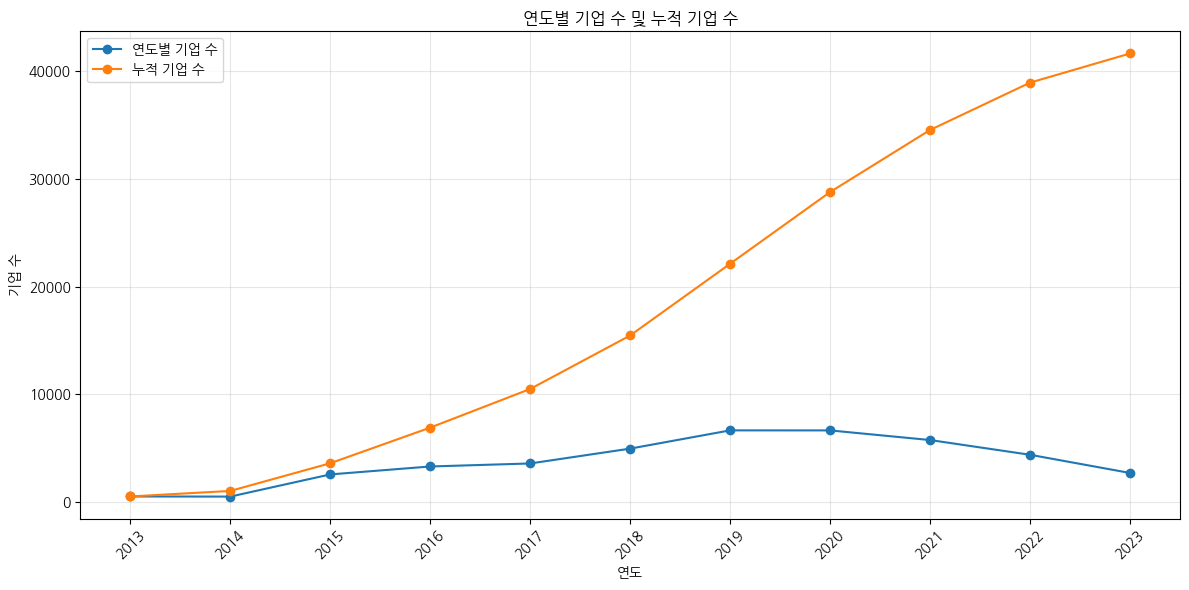

In [ ]:
# 의도: 연도별 기업 수와 누적 기업 수를 한 그래프에 시각화
plt.figure(figsize=(12, 6))

plt.plot(
    company_monthly_count['cdate'].astype(str),
    company_monthly_count['count'],
    marker='o',
    label='연도별 기업 수'
)

plt.plot(
    company_monthly_count['cdate'].astype(str),
    company_monthly_count['cumulative_count_Y'],
    marker='o',
    label='누적 기업 수'
)

plt.title('연도별 기업 수 및 누적 기업 수')
plt.xlabel('연도')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

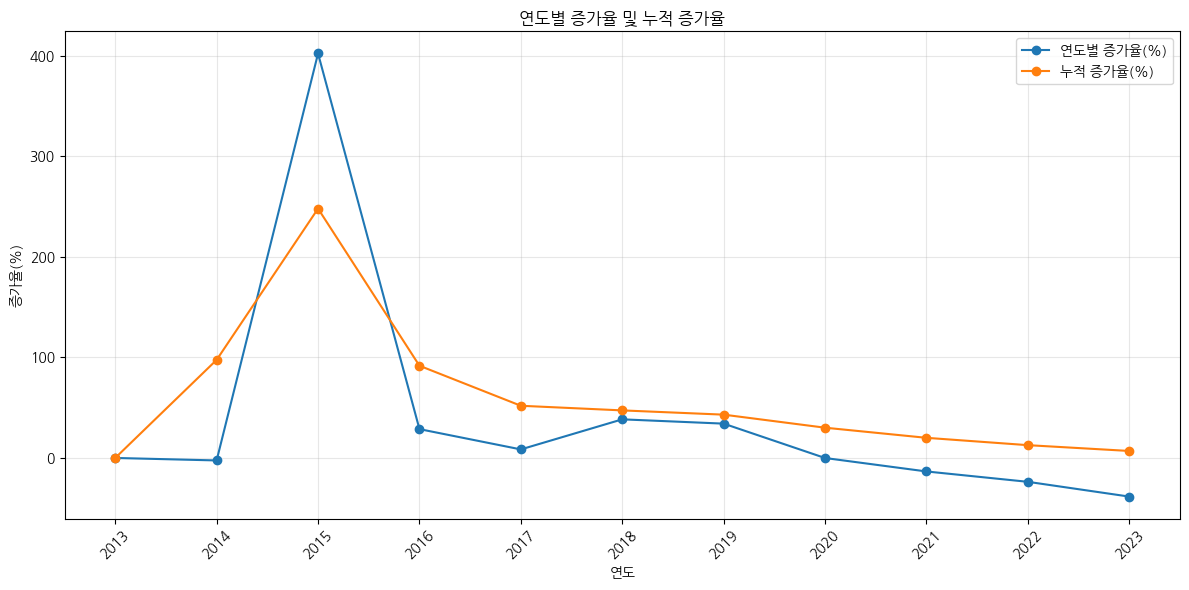

In [ ]:
# 의도: 연도별 증가율과 누적 증가율을 한 그래프에 시각화
plt.figure(figsize=(12, 6))

plt.plot(
    company_monthly_count['cdate'].astype(str),
    company_monthly_count['growth_rate_Y'],
    marker='o',
    label='연도별 증가율(%)'
)

plt.plot(
    company_monthly_count['cdate'].astype(str),
    company_monthly_count['cumulative_growth_rate_Y'],
    marker='o',
    label='누적 증가율(%)'
)

plt.title('연도별 증가율 및 누적 증가율')
plt.xlabel('연도')
plt.ylabel('증가율(%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 기업 주소


In [ ]:
companyaddress_df = pd.read_csv("/content/drive/MyDrive/기업 주소.csv")

In [ ]:
companyaddress_df.head()

,name,company_uuid,address
0,NaN,0bf81092-9bb5-44c7-a8de-e1db103253ef,서울 구로구
1,사무실,0bf81092-9bb5-44c7-a8de-e1db103253ef,서울특별시 구로구
2,NaN,e8b24030-b0c5-4f07-9427-2d1e2519cb82,"158 Hoàng Hoa Thám, Phường 12, Tân Bình, Hồ Ch..."
3,NaN,21743ac5-8957-4b2e-8f36-804d187d75a5,서울특별시 서초구
4,NaN,82be7598-af6f-4af9-86d5-f57ccb76f8dd,서울특별시 종로구


In [ ]:
companyaddress_company = companyaddress_df.groupby('company_uuid')['company_uuid'].count().reset_index(name="count")
companyaddress_company["count"].max(), companyaddress_company["count"].min()

(44, 1)

In [ ]:
# 중복이 있지만 상세 주소를 알 수 없기때문에 중복 제거 x
companyaddress_df[companyaddress_df.duplicated(keep=False)]

,name,company_uuid,address
7,NaN,26cfff24-81f4-4496-9830-c6fb3480217c,수원시
8,NaN,26cfff24-81f4-4496-9830-c6fb3480217c,수원시
290,TAGby,8fe4bd95-4dc1-41dd-bfd7-a58b03e6174b,서울특별시 강남구
291,TAGby,8fe4bd95-4dc1-41dd-bfd7-a58b03e6174b,서울특별시 강남구
464,매장,4aaba5e5-220d-4d63-a0ef-ff68a7d8b887,서울특별시 중구
...,...,...,...
16881,본관,a2d1b319-7b44-4757-94d6-bf36b9cfe9b8,서울특별시 용산구
16882,본관,a2d1b319-7b44-4757-94d6-bf36b9cfe9b8,서울특별시 용산구
17141,사무실,79744019-6c56-4ae7-b524-af955ae4a984,서울특별시 관악구
17142,사무실,79744019-6c56-4ae7-b524-af955ae4a984,서울특별시 관악구


In [ ]:
companyaddress_company[companyaddress_company['count'] > 1]

,company_uuid,count
2,00071b58-057a-4e1a-9265-cc6512e68f70,2
15,00400d8c-110d-49c0-86b5-f69ff3553822,2
18,004c1801-0269-46ba-961f-c08f8817ccd9,2
19,00526448-9716-46b9-821f-d6c9e8a1d5a7,2
23,006b3d42-ae9e-4fcf-9b3f-e47b57f50cf5,2
...,...,...
14005,ff648bfc-f29a-4f56-afd1-a15995a92ac6,2
14006,ff74cfc2-bcf6-42e2-a63c-c4994108a7fb,3
14010,ff82262b-0faf-42f8-bc9f-3c113872e255,2
14014,ff8ca43b-bc08-4394-9764-f3f06c104829,2


In [ ]:
companyaddress_company.describe()

,count
count,14033.000000
mean,1.232880
std,0.829841
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,44.000000


In [ ]:
companyaddress_company.describe()

,count
count,14033.000000
mean,1.232880
std,0.829841
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,44.000000


In [ ]:
companyaddress_company.sort_values(by="count", ascending=False).head(10)

,company_uuid,count
3112,39db3d5b-4e84-4c52-a68d-c097d859542d,44
3626,43408a24-5a2e-464a-b868-d50f39651262,33
8659,9de72f52-dc33-4400-a11e-1bd08672b2ec,30
12566,e47b6773-6d74-4086-bd48-a9523655d0b3,21
3836,47990a4b-3d21-431b-a465-cecbc4b67de3,19
551,0a574f3b-1f8f-432c-a147-4a5550a3d02e,15
12383,e1352874-81a2-4b67-943f-09b8606528f5,11
1179,1608e9cb-d3c9-4caa-9288-890f6a5d8c1a,11
7934,907e6f64-48ee-4f90-ab3a-22644c3a5ca0,9
13070,ee4c333b-87e6-41ed-b3e7-0dfc9a321528,9


In [ ]:
companyaddress_company[companyaddress_company['count'] <= 10]

,company_uuid,count
0,0000fda1-54e9-43ff-8c7b-8dcdf5efdb2a,1
1,00027545-e75b-4b62-9d97-02eaa67618e7,1
2,00071b58-057a-4e1a-9265-cc6512e68f70,2
3,00093c2d-5734-4162-82e8-1def2a831408,1
4,000d1d80-ea10-447c-8e1e-d8f05c07031a,1
...,...,...
14028,ffd03b2d-e0e9-40b3-83f3-6b5ae0eba6ff,1
14029,ffdbcce5-b007-4097-a1dc-3164b6be9128,1
14030,ffe38340-b2f8-46d9-be85-ca84b652356c,1
14031,fff510e2-93ee-4aa6-8e31-b0fcfe6028bb,1


In [ ]:
companyaddress_company

,company_uuid,count
0,0000fda1-54e9-43ff-8c7b-8dcdf5efdb2a,1
1,00027545-e75b-4b62-9d97-02eaa67618e7,1
2,00071b58-057a-4e1a-9265-cc6512e68f70,2
3,00093c2d-5734-4162-82e8-1def2a831408,1
4,000d1d80-ea10-447c-8e1e-d8f05c07031a,1
...,...,...
14028,ffd03b2d-e0e9-40b3-83f3-6b5ae0eba6ff,1
14029,ffdbcce5-b007-4097-a1dc-3164b6be9128,1
14030,ffe38340-b2f8-46d9-be85-ca84b652356c,1
14031,fff510e2-93ee-4aa6-8e31-b0fcfe6028bb,1


In [ ]:
company_df[company_df['company_uuid'] == '39db3d5b-4e84-4c52-a68d-c097d859542d']

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid
35808,2015-12-22 09:59:44,2022-07-25 01:14:44,NaN,0명,3700,8,0,39db3d5b-4e84-4c52-a68d-c097d859542d


## 공고

In [ ]:
job_df = pd.read_csv("/content/drive/MyDrive/공고.csv")

- 전처리 순서
cdate > mdate 인 경우삭제
start_date 결측값에 mdate 값 대입
start_date = end_date 인 경우 삭제 → 공고 하루인것 삭제
end_date 결측값에 2999-12-31 값 대입 → 상시채용
end_date - start_date < 0 값 삭제
cdate & mdate & end_date 전부 22년 이전인 경우

end_date 결측값에 2999-12-31 값 대입 → 상시채용 / 2262-04-11은 pandas가 실제로 표현 가능한 날짜 /
errors='coerce' -> 표현 불가능한 날짜는 결측값 (NaT)로 변환

In [ ]:
job_df.to_csv('공고_clean.csv', index=False, encoding='utf-8-sig')

In [ ]:
# 의도: 날짜형으로 먼저 변환
job_df['cdate'] = pd.to_datetime(job_df['cdate'], errors='coerce')
job_df['mdate'] = pd.to_datetime(job_df['mdate'], errors='coerce')
job_df['start_date'] = pd.to_datetime(job_df['start_date'], errors='coerce')
job_df['end_date'] = pd.to_datetime(job_df['end_date'], errors='coerce')

# 의도: cdate > mdate 인 경우 삭제
job_df = job_df[job_df['cdate'] <= job_df['mdate']].copy()

# 의도: start_date 결측값에 mdate 값 대입
job_df['start_date'] = job_df['start_date'].fillna(job_df['mdate'])

# 의도: end_date 결측값에 상시채용용 큰 날짜 대입
job_df['end_date'] = job_df['end_date'].fillna(pd.Timestamp('2262-04-11'))

# 의도: end_date - start_date < 0 인 경우만 삭제
job_df = job_df[job_df['end_date'] >= job_df['start_date']].copy()

# 의도: cdate, mdate, end_date가 모두 2022년 이전인 경우 삭제
cutoff = pd.Timestamp('2022-01-01')

job_df = job_df[
    ~(
        (job_df['cdate'] < cutoff) |
        (job_df['mdate'] < cutoff) |
        (job_df['end_date'] < cutoff)
    )
].copy()

In [ ]:
job_df['cdate'].min(), job_df['mdate'].min(), job_df['end_date'].min()

(Timestamp('2022-01-01 04:01:38'),
 Timestamp('2022-01-01 04:53:57'),
 Timestamp('2022-01-05 00:00:00'))

In [ ]:
# 등록된 기업 수, 주소가 등록된 기업 수(지점 포함), 주소가 등록된 기업 수(중복 제거)
print(company_df['company_uuid'].nunique(), companyaddress_df['company_uuid'].count(), companyaddress_df['company_uuid'].nunique())

41659 17301 14033


In [ ]:
job_count = job_df.groupby('company_uuid')['job_uuid'].count()
company_df['job_count'] = company_df['company_uuid'].map(job_count).fillna(0).astype(int)

In [ ]:
job_df.groupby('company_uuid')['job_uuid'].count().reset_index().sort_values(by='job_uuid', ascending=False).head(15)

,company_uuid,job_uuid
2609,997dea23-cc15-4af7-8f9b-33dc2e6cf1ac,645
2674,9de72f52-dc33-4400-a11e-1bd08672b2ec,546
1589,5b00ba89-7ffc-403b-a35e-01371a962dd3,528
664,267be9c3-ad1f-4fce-808c-640537cf5e81,348
522,1eaf8462-dbcb-41b4-95e6-9b559e0ab259,343
3188,bc19f7ee-e501-417d-9c8f-217ba26b6ba7,252
1625,5d5fccf9-a120-4bea-ad95-09626cf134ec,232
394,17af1b10-e0d3-4849-a2ea-1df7ed0f753f,189
1246,47990a4b-3d21-431b-a465-cecbc4b67de3,176
2671,9dbb0d76-6021-48af-9bc4-ff69d494bc92,170


## 투자

In [ ]:
invest_df = pd.read_csv("/content/drive/MyDrive/투자.csv")

In [ ]:
invest_df['company_uuid'].nunique(), invest_df['company_uuid'].count()

(4785, np.int64(9182))

In [ ]:
invest_df[invest_df.duplicated()]

,fund_date,round_type,raised,currency,company_uuid
151,2015-10-01,Seed,0,KRW,2ed05b18-c735-474a-9faa-02095b25729a
228,2018-05-10,Series A,0,KRW,0601f22e-540b-4a12-a4c0-ef3ff4c266d7
315,2021-02-03,투자 단계 비공개,0,KRW,288ce0b6-1114-455b-8413-5dee0c9bc5de
345,2018-04-30,Angel,0,KRW,38006771-b74d-406b-9fb4-0566dbe538f6
375,2020-07-01,투자 단계 비공개,0,KRW,16d5746e-7947-453e-b580-8fcde1faa9cc
...,...,...,...,...,...
8581,2012-06-01,투자 단계 비공개,100000000,KRW,593bc07b-8725-49c8-a384-2b3c124101e4
8615,2015-06-18,투자 단계 비공개,100000000,KRW,26cfff24-81f4-4496-9830-c6fb3480217c
8929,2015-09-01,투자 단계 비공개,19950000,KRW,a7696350-8f85-4e55-a326-34e10b338a57
8930,2015-09-01,투자 단계 비공개,19950000,KRW,a7696350-8f85-4e55-a326-34e10b338a57


In [ ]:
# 중복 제거
invest_df = invest_df.drop_duplicates(keep='first')

In [ ]:
invest_df = invest_df.sort_values(by=['company_uuid', 'fund_date'])

In [ ]:
# 회사를 기준으로 fund_date는 가장 최근인 값만 -> 투자관련 정보를 변경하면 cdate, mdate로 나뉘는게 아니라 fund_date로 저장돼서 한 회사가 여러번 존재
invest_df[invest_df['company_uuid'].duplicated(keep=False)]

invest_df.drop_duplicates(subset=['company_uuid'], keep='last', inplace=True)

- 전체 중복 제거 -> company_uuid, fund_date로 정렬 ->기업 아이디 기준 중복인 행에서 마지막행 제외 후 제거

In [ ]:
invest_df['company_uuid'].nunique(), invest_df['company_uuid'].count()

(4785, np.int64(4785))

In [ ]:
invest_df.groupby('round_type')['company_uuid'].count()

,company_uuid
round_type,
Angel,282
Pre-IPO,18
Seed,969
Series A,448
Series B,146
Series C,27
Series D,3
투자 단계 비공개,2702
해당없음,190


In [ ]:
company_df['invest'] = company_df['company_uuid'].isin(invest_df['company_uuid']).astype(int)
company_df['address'] = company_df['company_uuid'].isin(companyaddress_df['company_uuid']).astype(int)
company_df['job'] = company_df['company_uuid'].isin(job_df['company_uuid']).astype(int)

In [ ]:
company_df.sort_values(by='job_count', ascending=False)

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid,job_count,invest,address,job
40420,2015-04-23 10:30:45,2022-08-11 08:27:35,2016-01-01,501-1000명,73937,2117,149,997dea23-cc15-4af7-8f9b-33dc2e6cf1ac,645,1,1,1
41440,2015-10-04 22:25:29,2023-09-20 06:09:58,1967-12-29,0명,9550,190,7,9de72f52-dc33-4400-a11e-1bd08672b2ec,546,1,1,1
38492,2020-03-10 07:11:39,2023-01-31 02:35:11,2018-09-17,0명,14885,278,21,5b00ba89-7ffc-403b-a35e-01371a962dd3,528,0,1,1
41183,2018-08-20 05:59:18,2023-07-04 02:27:33,2018-08-16,0명,10439,391,7,267be9c3-ad1f-4fce-808c-640537cf5e81,348,1,1,1
40203,2019-11-04 01:59:00,2023-03-28 01:46:12,2018-10-25,11-50명,8419,315,5,1eaf8462-dbcb-41b4-95e6-9b559e0ab259,343,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13939,2022-07-07 02:27:14,2022-07-07 02:27:14,2017-07-06,0명,113,0,1,8ef7e272-28bc-452a-b528-d9cc343257ce,0,0,1,0
13940,2022-08-22 02:42:28,2022-08-22 02:42:28,2022-07-08,0명,113,0,0,48b97ac4-7268-4270-9902-3ea86dae47df,0,0,0,0
13941,2022-11-15 09:55:35,2022-11-15 09:55:35,NaN,0명,113,0,0,68b6ef7b-7d30-4843-a8d5-dffee1bba4d0,0,0,0,0
13942,2023-03-14 07:32:35,2023-03-14 07:32:35,NaN,0명,113,0,0,9c948079-fbe7-4454-97db-b52adeb2bad0,0,0,0,0


## 지원

In [ ]:
application_df = pd.read_csv("/content/drive/MyDrive/application.csv")

In [ ]:
application_df['cdate'].min()

'2015-02-24 10:22:28'

In [ ]:
application_df.duplicated().sum()

np.int64(0)

In [ ]:
application_df.head(1)

,cdate,company_uuid,job_uuid,user_uuid,application_uuid
0,2017-02-25 23:45:01,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,b0329bd7-fc45-4e83-993a-b73bd9d3549c,59c42363-f764-4cbd-aafd-20eb663ea5d7


In [ ]:
application_df[application_df['cdate'] >= '2022-01-01']

,cdate,company_uuid,job_uuid,user_uuid,application_uuid
163,2022-01-23 10:50:16,de4b3596-b4ab-47cd-b8ea-6f9e14170064,bc4a29a5-644b-479a-8280-b55c55e0f145,2ece8d7d-79b6-4522-928b-8dbae8843fab,183af487-0e1f-44c8-9253-c0335de1310a
176,2022-01-10 06:27:37,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,332926ba-57aa-4b8f-ad55-316f56911c5a
177,2022-01-10 07:19:31,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,dd4a186d-1e73-4123-8097-5c33b128ffb2
178,2022-01-10 10:59:26,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,4d5bedd2-5b63-4d05-a7b3-d74e45f61cd0
179,2022-08-21 08:48:00,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,067bb1a8-ee8f-4bd2-97fa-0e39321ab797
...,...,...,...,...,...
340715,2022-06-28 12:35:21,1f78ba83-0862-400a-9450-7438de6dd53c,0baa07ef-5808-4ced-8719-aa928b91cafd,bdfebb58-6ebe-4124-8679-de9d5c266dbb,64c29614-9b79-4462-9fd6-e4d93a0cd8dc
340726,2022-03-20 22:21:29,214c0ee9-4fc9-46be-ba8a-2a0368510e80,a82d7bd3-87ee-4eaf-9519-1b60a331a474,dc1fb548-59dd-47bc-82aa-99d92e70f793,0ab0adef-da09-4381-baf7-a3fb017c19ea
340727,2022-04-07 09:41:05,565e7499-1070-49c5-a3b9-a27e5ca27a9e,744ab632-8193-406a-bd51-3e2c9ddd4544,1e311075-359d-40fd-b606-f74cb1819499,bbd1050f-3729-45d9-8404-c8ad75dc5131
340728,2022-07-15 04:22:09,79d4e2b6-e8df-4605-9c2c-b00e73698b61,5faf63f9-848e-4286-a07c-992c0883115d,7ba43545-bf1c-465e-8996-e55231b020c6,43107da9-ff4d-4e62-9dd2-1b2df5a9ae78


In [ ]:
job_application = application_df.groupby('company_uuid')['application_uuid'].count().reset_index(name='application_count')
job_application

,company_uuid,application_count
0,0000fda1-54e9-43ff-8c7b-8dcdf5efdb2a,14
1,00027545-e75b-4b62-9d97-02eaa67618e7,6
2,00071b58-057a-4e1a-9265-cc6512e68f70,88
3,0009c5b4-eca5-482a-a9a0-3d08e106909d,67
4,000d1d80-ea10-447c-8e1e-d8f05c07031a,12
...,...,...
11302,ffe35da5-c7fa-46b0-9cca-d7764e817474,1
11303,ffe93c3b-6396-4452-9278-7ac89aa23477,13
11304,fff510e2-93ee-4aa6-8e31-b0fcfe6028bb,6
11305,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,217


## 북마크

In [ ]:
bookmark_df = pd.read_csv("/content/drive/MyDrive/jobbookmark.csv")

In [ ]:
bookmark_df['cdate'].max()

'2024-05-06 14:31:42'

In [ ]:
bookmark_df.duplicated().sum()

np.int64(50)

In [ ]:
bookmark_df = bookmark_df.drop_duplicates(keep="last")

In [ ]:

bookmark_df[bookmark_df['cdate'] >= '2022-01-01']

,cdate,job_uuid,user_uuid
47,2022-07-04 10:27:32,0b179f5f-dc22-462b-ac7f-9bd19a87c5ad,06d05db7-3c5f-4616-896f-286414ea3e6f
96,2023-02-03 03:28:55,7ad4ea23-e022-4589-8d89-756153675ef1,0eec3780-6ee8-4ec6-9802-52c0e2a4f47d
143,2023-02-03 03:30:59,62af11b9-0254-4d62-a920-baf97d157075,0eec3780-6ee8-4ec6-9802-52c0e2a4f47d
150,2023-02-23 05:48:02,82c3ca55-971d-4a65-9055-bb5534976b67,0eec3780-6ee8-4ec6-9802-52c0e2a4f47d
213,2023-02-23 05:42:08,00d1236a-7cc0-4fcb-be3a-d3b8c95ea8cf,0eec3780-6ee8-4ec6-9802-52c0e2a4f47d
...,...,...,...
413840,2022-01-12 08:24:51,7dc96475-b8fa-4f95-98c8-95cc5966b0a2,155f7b93-d521-465d-b7a5-6a7ec2d2db93
413859,2022-03-29 05:25:10,ccb1878f-5dba-4bde-a0af-29f6d9ee8432,6050cb4f-27b5-4c80-9a55-68a999012262
413860,2022-06-07 09:23:28,03f1d118-22e3-4659-aa66-565d3e963176,4974ae24-d946-4bd2-9114-94c2a5970338
413862,2023-06-29 18:29:54,2a1f0d8f-1faa-4b1b-a0ab-cf50f0ab3a19,b9fabe1e-8c83-46fd-bba6-7ae702e9755d


In [ ]:
job_bookmark = bookmark_df.groupby('job_uuid')['user_uuid'].count().reset_index(name='bookmark_count')
job_bookmark

,job_uuid,bookmark_count
0,000106ea-0a89-4bf6-a640-3469c34c8c99,2
1,00016572-cd65-4fc3-9b49-7f2f8cd7ca7a,3
2,00016e77-ed17-47c6-b677-dcd7c96c6dcb,1
3,0001774f-5410-4ff3-8785-22bc103aa49b,2
4,0001a590-5097-41f6-8ac3-32d53f8fd660,3
...,...,...
82213,fffb8462-73a7-4587-9a75-e3bd7f3b7ca0,1
82214,fffbbf0a-de58-445f-9dd4-d42a4733bbc5,1
82215,fffc9f35-4695-4956-b5c6-ffbe35cb83aa,6
82216,fffd0d11-a025-44a5-8fd9-7f82d242cff0,4


In [ ]:
company_job_count = job_df.groupby(['company_uuid', 'job_uuid'])['job_uuid'].count().reset_index(name='count')
company_job_count

,company_uuid,job_uuid,count
0,00027545-e75b-4b62-9d97-02eaa67618e7,204bba91-9b4c-4260-9f3a-bb8c8b52edbc,1
1,00027545-e75b-4b62-9d97-02eaa67618e7,703daa43-94d5-4205-85e5-277de930764f,1
2,00027545-e75b-4b62-9d97-02eaa67618e7,765d16fd-1451-4543-8e89-0978f2cbc433,1
3,0009c5b4-eca5-482a-a9a0-3d08e106909d,7ca109b3-4e1b-4b97-8617-e0d3b5a0eefa,1
4,002c50ee-94fa-402f-bf2c-5c742a34afa0,e4b997be-1202-4502-85c3-7f4905c05fab,1
...,...,...,...
25844,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,df18b1fe-0842-4f17-8475-58cfec7a4235,1
25845,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,e7f19288-61a9-4821-b3bc-29702396135d,1
25846,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,f6fd10bb-b9d6-4e4f-9904-d45f55c4b9e2,1
25847,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,f8de4549-6482-4fc5-aafe-02dc4a2fd33b,1


In [ ]:
company_merge = pd.merge(company_job_count, job_bookmark, on='job_uuid', how='left')
company_merge

,company_uuid,job_uuid,count,bookmark_count
0,00027545-e75b-4b62-9d97-02eaa67618e7,204bba91-9b4c-4260-9f3a-bb8c8b52edbc,1,1.0
1,00027545-e75b-4b62-9d97-02eaa67618e7,703daa43-94d5-4205-85e5-277de930764f,1,4.0
2,00027545-e75b-4b62-9d97-02eaa67618e7,765d16fd-1451-4543-8e89-0978f2cbc433,1,2.0
3,0009c5b4-eca5-482a-a9a0-3d08e106909d,7ca109b3-4e1b-4b97-8617-e0d3b5a0eefa,1,6.0
4,002c50ee-94fa-402f-bf2c-5c742a34afa0,e4b997be-1202-4502-85c3-7f4905c05fab,1,1.0
...,...,...,...,...
25844,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,df18b1fe-0842-4f17-8475-58cfec7a4235,1,NaN
25845,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,e7f19288-61a9-4821-b3bc-29702396135d,1,6.0
25846,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,f6fd10bb-b9d6-4e4f-9904-d45f55c4b9e2,1,1.0
25847,fffdf439-a33f-4fd3-8168-718d5cdf9bdc,f8de4549-6482-4fc5-aafe-02dc4a2fd33b,1,15.0


In [ ]:
company_merge.loc[company_merge['bookmark_count'].isnull(), 'bookmark_count'] = 0
company_bookmark = company_merge.groupby('company_uuid')['bookmark_count'].sum().reset_index(name='bookmark_count')

In [ ]:
company_bookmark

,company_uuid,bookmark_count
0,00027545-e75b-4b62-9d97-02eaa67618e7,7.0
1,0009c5b4-eca5-482a-a9a0-3d08e106909d,6.0
2,002c50ee-94fa-402f-bf2c-5c742a34afa0,1.0
3,0035a411-212f-4b0d-b08e-2d3828ed0b0a,43.0
4,004a4c7a-457d-4125-be8b-8155c92f6f04,0.0
...,...,...
4355,ff897cd8-48ee-44fc-8b7c-9ed75648e1a4,4.0
4356,ffa08937-287f-42ef-bc7f-34ed9daf0745,1.0
4357,ffce5989-097a-4a4d-877e-cfb822fcd80f,0.0
4358,ffd03b2d-e0e9-40b3-83f3-6b5ae0eba6ff,2.0


In [ ]:
company_df = company_df.merge(
    company_bookmark,
    on='company_uuid',
    how='left'
)

company_df['bookmark_count'] = company_df['bookmark_count'].fillna(0).astype(int)

company_df = company_df.merge(
    job_application,
    on='company_uuid',
    how='left'
)

company_df['application_count'] = company_df['application_count'].fillna(0).astype(int)

## 분석

### 분석기간

In [ ]:
# 의도: 기업 테이블의 분석 시작일과 종료일 확인
company_df['cdate'] = pd.to_datetime(company_df['cdate'], errors='coerce')

print('기업 테이블 시작일:', company_df['cdate'].min())
print('기업 테이블 종료일:', company_df['cdate'].max())

기업 테이블 시작일: 2013-01-10 15:47:37
기업 테이블 종료일: 2023-12-31 09:59:24


In [ ]:
# 의도: 공고 테이블의 분석 시작일과 종료일 확인
job_df['cdate'] = pd.to_datetime(job_df['cdate'], errors='coerce')

print('공고 테이블 시작일:', job_df['cdate'].min())
print('공고 테이블 종료일:', job_df['cdate'].max())

공고 테이블 시작일: 2022-01-01 04:01:38
공고 테이블 종료일: 2023-12-31 04:28:30


### 인기 클러스터링

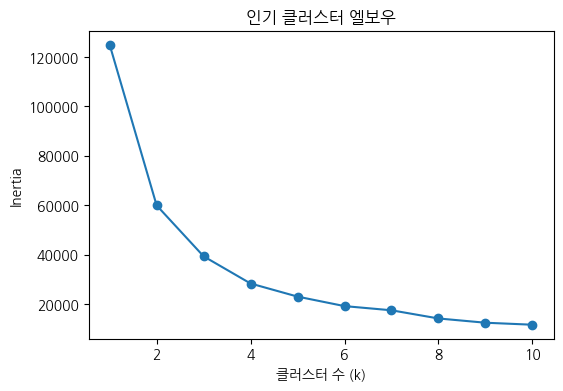

In [ ]:
# 인기 클러스터링 개수 찾기
X_pop = company_df[['view_count', 'follow_count', 'reference_count']].copy()

# 로그 변환
X_pop = np.log1p(X_pop)

# 스케일링
scaler = StandardScaler()
X_pop_scaled = scaler.fit_transform(X_pop)

inertia_list = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pop_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia_list, marker='o')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.title('인기 클러스터 엘보우')
plt.show()

In [ ]:

# 인기 변수 3개 선택
X_pop = company_df[['view_count', 'follow_count', 'reference_count']].copy()

# 로그 변환
X_pop = np.log1p(X_pop)

# 스케일링
scaler = StandardScaler()
X_pop_scaled = scaler.fit_transform(X_pop)

# 클러스터링
kmeans_pop = KMeans(n_clusters=4, random_state=42)
company_df['pop_cluster'] = kmeans_pop.fit_predict(X_pop_scaled)

# 클러스터별 평균 확인
company_df.groupby('pop_cluster')[['view_count', 'follow_count', 'reference_count']].mean()

,view_count,follow_count,reference_count
pop_cluster,,,
0,866.623499,0.503623,0.067288
1,3190.207025,11.521803,0.905103
2,72.473671,0.075285,0.025206
3,9932.702488,117.588893,8.098089


In [ ]:
pop_label_map = {
    0: '조회형',
    1: '관심형',
    2: '저인기형',
    3: '고인기형'
}

company_df['pop_cluster_name'] = company_df['pop_cluster'].map(pop_label_map)
pop_cluster = company_df.groupby('pop_cluster_name')['company_uuid'].count().reset_index(name='count')

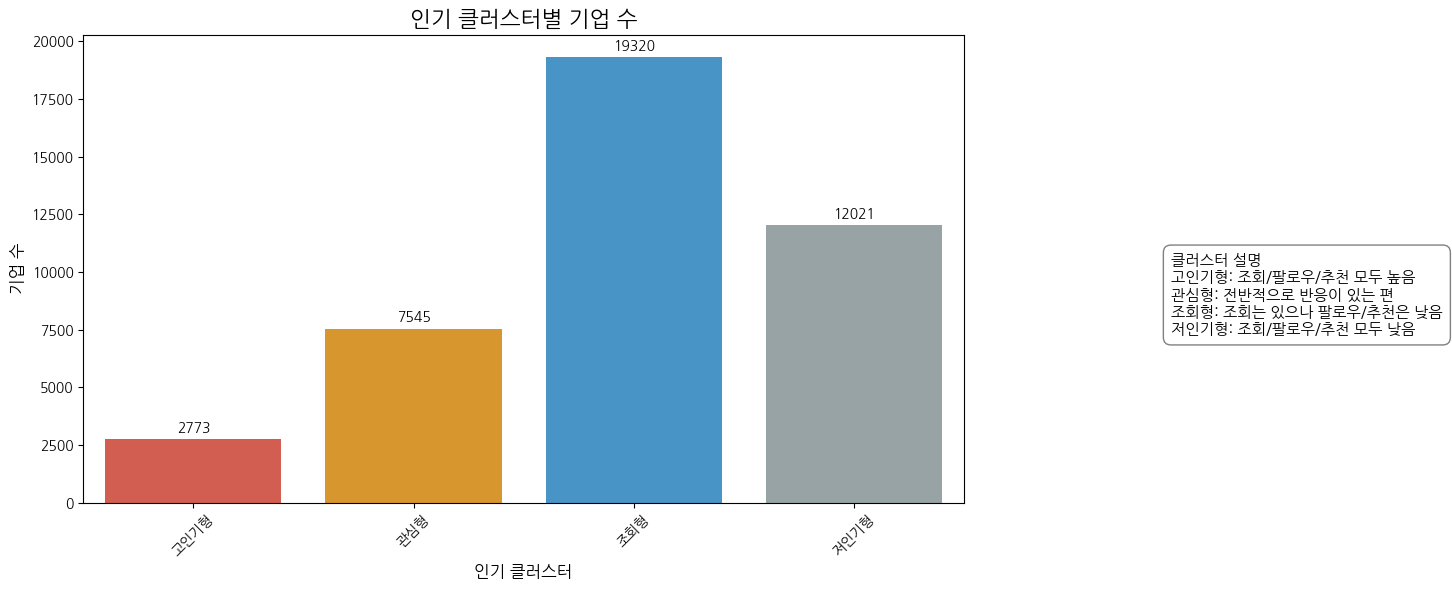

In [ ]:
order_list = ['고인기형', '관심형', '조회형', '저인기형']

# 카테고리 순서 지정
pop_cluster['pop_cluster_name'] = pd.Categorical(
    pop_cluster['pop_cluster_name'],
    categories=order_list,
    ordered=True
)

# 정렬
pop_cluster = pop_cluster.sort_values('pop_cluster_name')

# 군집별 색 지정
palette_map = {
    '고인기형': '#E74C3C',
    '관심형': '#F39C12',
    '조회형': '#3498DB',
    '저인기형': '#95A5A6'
}

# 그래프
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=pop_cluster,
    x='pop_cluster_name',
    y='count',
    hue='pop_cluster_name',
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=ax
)

# 막대 위에 개수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

# 제목/축 라벨
ax.set_title('인기 클러스터별 기업 수', fontsize=16)
ax.set_xlabel('인기 클러스터', fontsize=12)
ax.set_ylabel('기업 수', fontsize=12)

# x축 글자 기울이기
plt.xticks(rotation=45)

# 오른쪽 설명 텍스트
cluster_desc = (
    "클러스터 설명\n"
    "고인기형: 조회/팔로우/추천 모두 높음\n"
    "관심형: 전반적으로 반응이 있는 편\n"
    "조회형: 조회는 있으나 팔로우/추천은 낮음\n"
    "저인기형: 조회/팔로우/추천 모두 낮음"
)

fig.text(
    0.98, 0.5, cluster_desc,
    ha='left', va='center',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray')
)

# 오른쪽 여백 확보
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

### 관리 클러스터링 (공고 제외)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

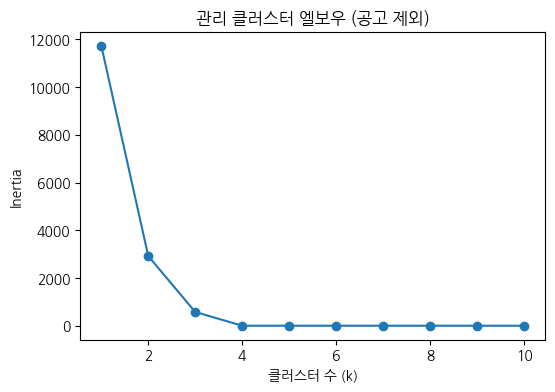

In [ ]:
# 공고를 제외한 관리 변수 2개만 선택
# invest: 투자 정보 작성 여부(0/1)
# address: 주소 등록 여부(0/1)
X_manage_x = company_df[['invest', 'address']].copy()

# 각 k별 inertia 값을 저장할 리스트
# inertia는 군집 내부 오차라고 보면 됨
inertia_list = []

# k를 1부터 10까지 바꿔가며 확인
K_range = range(1, 11)

for k in K_range:
    # 군집 수가 k개인 KMeans 모델 생성
    kmeans = KMeans(n_clusters=k, random_state=42)

    # 데이터 학습
    kmeans.fit(X_manage_x)

    # 학습 결과의 inertia 값을 저장
    inertia_list.append(kmeans.inertia_)

# 엘보우 그래프 그리기
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia_list, marker='o')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.title('관리 클러스터 엘보우 (공고 제외)')
plt.show()

In [ ]:
# 기업 관리 클러스터링 (공고 제외)
# 관리 변수 2개만 선택
X_manage_x = company_df[['invest', 'address']].copy()

# KMeans 모델 생성
# n_clusters=4는 군집을 4개로 나누겠다는 뜻
# 공고를 제외하면 invest/address 조합이 4개라서 보통 4개가 자연스러움
kmeans_manage_x = KMeans(n_clusters=4, random_state=42)

# fit_predict():
# 1. 데이터를 학습하고
# 2. 각 기업이 어느 군집에 속하는지 예측해서 번호를 반환
company_df['manage_cluster_x'] = kmeans_manage_x.fit_predict(X_manage_x)

# 각 군집의 invest/address 평균 확인
# 이 표를 보고 군집 이름을 붙임
company_df.groupby('manage_cluster_x')[['invest', 'address']].mean()

,invest,address
manage_cluster_x,,
0,0.0,0.0
1,0.0,1.0
2,1.0,1.0
3,1.0,0.0


In [ ]:
# 클러스터 이름 매핑
# 주의: 아래 번호는 groupby 평균 결과를 확인하고 맞춰야 함
manage_label_map_x = {
    0: '미등록형',
    1: '주소등록형',
    2: '완전관리형',
    3: '투자등록형'
}

# 군집 번호를 이름으로 변환해서 새 컬럼에 저장
company_df['manage_cluster_name_x'] = company_df['manage_cluster_x'].map(manage_label_map_x)

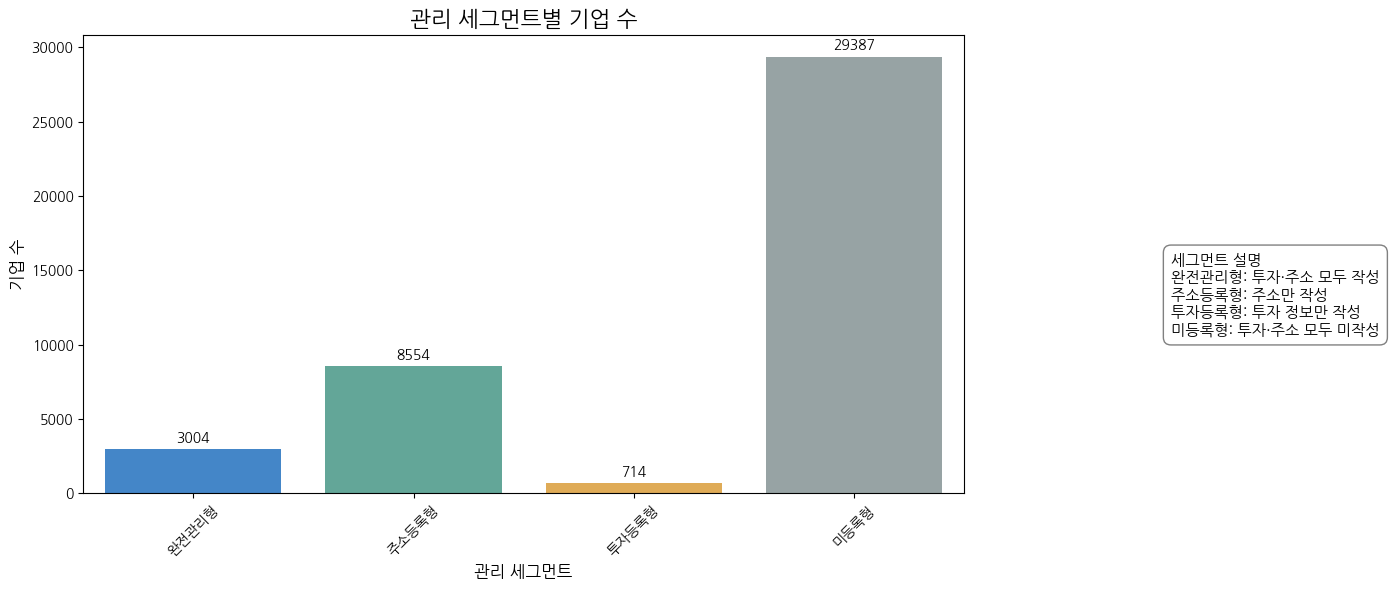

In [ ]:
# 군집 이름별 기업 수 집계
manage_cluster_x = (
    company_df
    .groupby('manage_cluster_name_x')['company_uuid']
    .count()
    .reset_index(name='count')
)

# 그래프에서 보여줄 순서 지정
order_list = ['완전관리형', '주소등록형', '투자등록형', '미등록형']

# 문자열 순서가 아니라 내가 정한 순서대로 정렬되게 카테고리 설정
manage_cluster_x['manage_cluster_name_x'] = pd.Categorical(
    manage_cluster_x['manage_cluster_name_x'],
    categories=order_list,
    ordered=True
)

# 지정한 순서대로 정렬
manage_cluster_x = manage_cluster_x.sort_values('manage_cluster_name_x')

# 군집별 색 지정
palette_map = {
    '완전관리형': '#2E86DE',
    '주소등록형': '#58B19F',
    '투자등록형': '#F5B041',
    '미등록형': '#95A5A6'
}

# 그래프 영역 생성
fig, ax = plt.subplots(figsize=(12, 6))

# 막대그래프 그리기
sns.barplot(
    data=manage_cluster_x,
    x='manage_cluster_name_x',
    y='count',
    hue='manage_cluster_name_x',
    palette=palette_map,
    dodge=False,
    legend=False,
    ax=ax
)

# 각 막대 위에 개수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

# 제목과 축 이름 설정
ax.set_title('관리 세그먼트별 기업 수', fontsize=16)
ax.set_xlabel('관리 세그먼트', fontsize=12)
ax.set_ylabel('기업 수', fontsize=12)

# x축 글자 기울이기
plt.xticks(rotation=45)

# 오른쪽에 설명 박스 넣기
cluster_desc = (
    "세그먼트 설명\n"
    "완전관리형: 투자·주소 모두 작성\n"
    "주소등록형: 주소만 작성\n"
    "투자등록형: 투자 정보만 작성\n"
    "미등록형: 투자·주소 모두 미작성"
)

fig.text(
    0.98, 0.5, cluster_desc,
    ha='left', va='center',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray')
)

# 오른쪽 설명이 잘리지 않게 여백 확보
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

### 인기클러스터와 관리 클러스터 비교 분석

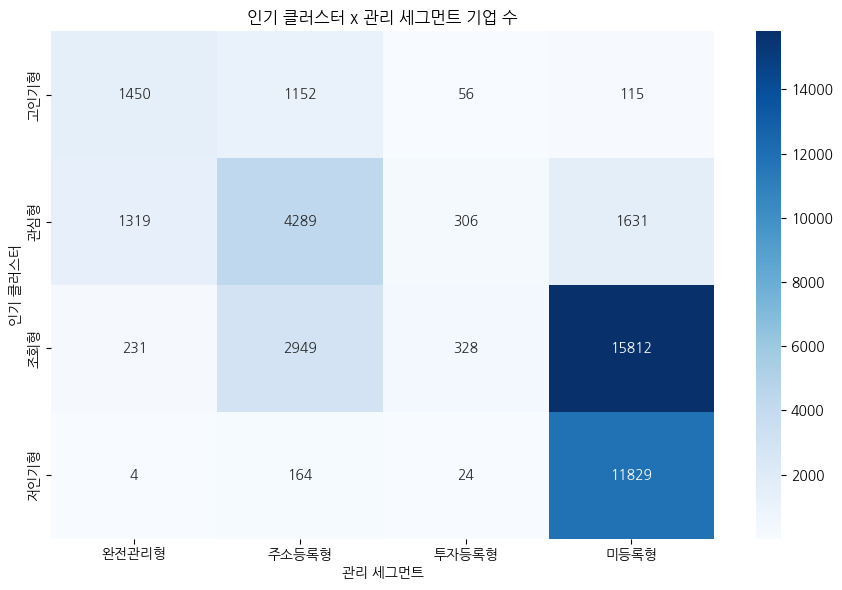

In [ ]:
# 의도: 인기 클러스터 x 관리 세그먼트의 실제 기업 수 교차표 만들기
cross_count = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x']
)

# 의도: 원하는 순서로 정렬
pop_order = ['고인기형', '관심형', '조회형', '저인기형']
manage_order_x = ['완전관리형', '주소등록형', '투자등록형', '미등록형']

cross_count = cross_count.reindex(index=pop_order, columns=manage_order_x, fill_value=0)

# 의도: 실제 기업 수 기준 히트맵 시각화
plt.figure(figsize=(9, 6))

sns.heatmap(
    cross_count,
    annot=True,     # 칸 안에 기업 수 표시
    fmt='.0f',      # 정수 형태로 표시
    cmap='Blues'
)

plt.title('인기 클러스터 x 관리 세그먼트 기업 수')
plt.xlabel('관리 세그먼트')
plt.ylabel('인기 클러스터')
plt.tight_layout()
plt.show()

In [ ]:
# 의도: 관리 세그먼트 순서 지정
manage_order_x = ['완전관리형', '주소등록형', '투자등록형', '미등록형']

company_df['manage_cluster_name_x'] = pd.Categorical(
    company_df['manage_cluster_name_x'],
    categories=manage_order_x,
    ordered=True
)

# 의도: 인기 클러스터 순서 지정
pop_order = ['고인기형', '관심형', '조회형', '저인기형']

company_df['pop_cluster_name'] = pd.Categorical(
    company_df['pop_cluster_name'],
    categories=pop_order,
    ordered=True
)

# 의도: 교차표 생성
cross_table_x = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x']
)

cross_table_x

manage_cluster_name_x,완전관리형,주소등록형,투자등록형,미등록형
pop_cluster_name,,,,
고인기형,1450,1152,56,115
관심형,1319,4289,306,1631
조회형,231,2949,328,15812
저인기형,4,164,24,11829


In [ ]:
# 의도: 각 인기 클러스터 안에서 관리 클러스터 비율(%) 계산
cross_ratio_x = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x'],
    normalize='index'   # 행 기준 비율
) * 100

cross_ratio_x

manage_cluster_name_x,완전관리형,주소등록형,투자등록형,미등록형
pop_cluster_name,,,,
고인기형,52.289939,41.543455,2.019473,4.147133
관심형,17.481776,56.845593,4.055666,21.616965
조회형,1.195652,15.263975,1.697723,81.842650
저인기형,0.033275,1.364279,0.199651,98.402795


In [ ]:
# 의도: 각 인기 클러스터 안에서 관리 클러스터 비율(%) 계산
cross_ratio_x = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x'],
    normalize='index'   # 행 기준 비율
) * 100

cross_ratio_x

manage_cluster_name_x,완전관리형,주소등록형,투자등록형,미등록형
pop_cluster_name,,,,
고인기형,52.289939,41.543455,2.019473,4.147133
관심형,17.481776,56.845593,4.055666,21.616965
조회형,1.195652,15.263975,1.697723,81.842650
저인기형,0.033275,1.364279,0.199651,98.402795


In [ ]:
# 의도: 각 관리 클러스터 안에서 인기 클러스터 비율(%) 계산
cross_ratio_col_x = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x'],
    normalize='columns'
) * 100

cross_ratio_col_x

manage_cluster_name_x,완전관리형,주소등록형,투자등록형,미등록형
pop_cluster_name,,,,
고인기형,48.268975,13.467384,7.843137,0.391329
관심형,43.908123,50.140285,42.857143,5.550073
조회형,7.689747,34.475099,45.938375,53.806105
저인기형,0.133156,1.917232,3.361345,40.252493


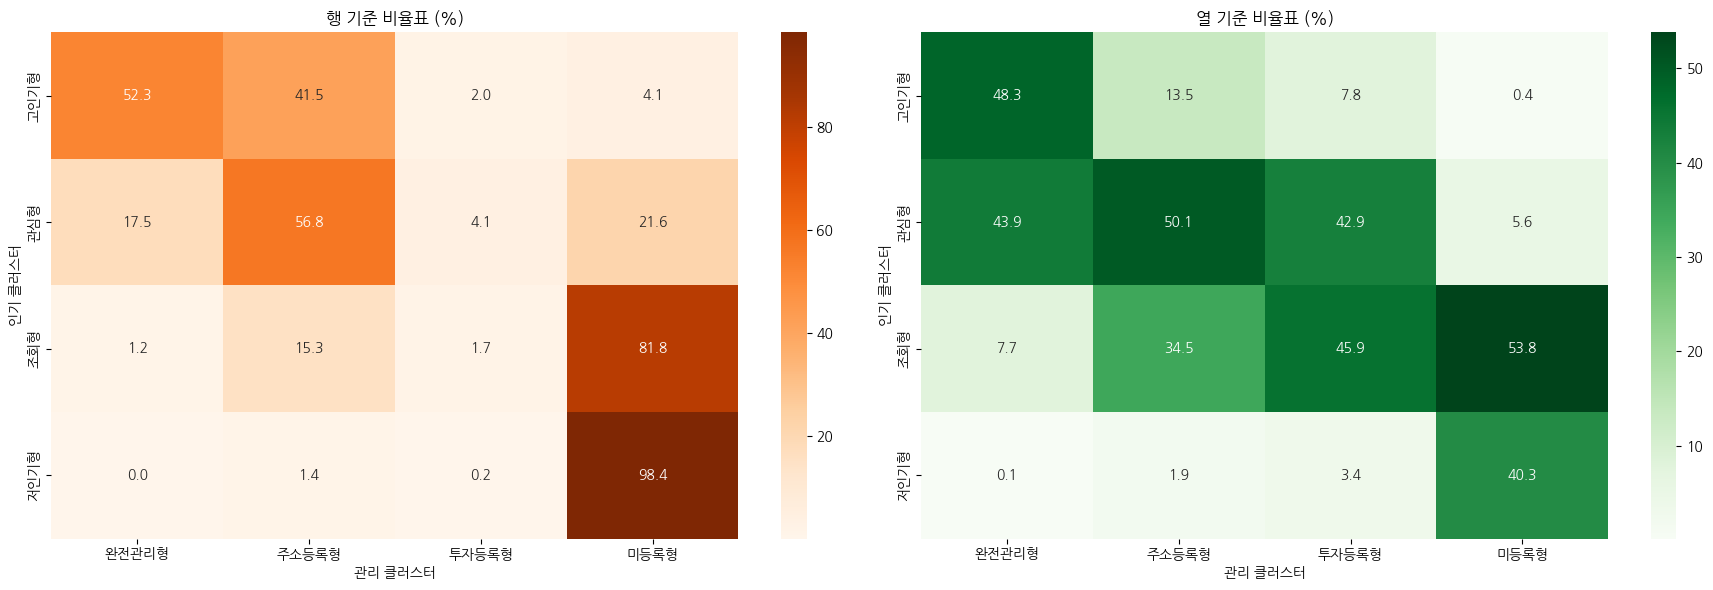

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. 행 기준 비율 히트맵
sns.heatmap(
    cross_ratio_x,
    annot=True,
    fmt='.1f',
    cmap='Oranges',
    ax=axes[0]
)
axes[0].set_title('행 기준 비율표 (%)')
axes[0].set_xlabel('관리 클러스터')
axes[0].set_ylabel('인기 클러스터')

# 2. 열 기준 비율 히트맵
sns.heatmap(
    cross_ratio_col_x,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('열 기준 비율표 (%)')
axes[1].set_xlabel('관리 클러스터')
axes[1].set_ylabel('인기 클러스터')

plt.tight_layout()
plt.show()

### 각 인기 클러스터 별 공고와 지원, 북마크 수 비교


- 기업별 공고 수(직무, 경력), 지원수, 북마크 수

### 클러스터 별 북마크, 지원 수

In [ ]:
company_df_1 = company_df[~(company_df['job'] == 0)]

In [ ]:
# 의도: 인기 클러스터별 평균, 중앙값, 표본 수를 같이 확인
pop_summary = (
    company_df_1
    .groupby('pop_cluster_name', observed=False)
    .agg({
        'bookmark_count': ['mean', 'median', 'count'],
        'application_count': ['mean', 'median', 'count'],
        'job_count': ['mean', 'median', 'count']
    })
)

pop_summary

bookmark_count              application_count               \
                           mean median count              mean median count   
pop_cluster_name                                                              
고인기형                  31.214976   13.0  1656        117.106884   58.0  1656   
관심형                    7.231487    4.0  1715         12.865889    7.0  1715   
조회형                    1.357947    1.0   799          0.902378    0.0   799   
저인기형                   0.821429    0.0    28          0.714286    0.0    28   

                  job_count               
                       mean median count  
pop_cluster_name                          
고인기형              10.573068    4.0  1656  
관심형                3.819242    2.0  1715  
조회형                1.692115    1.0   799  
저인기형               1.214286    1.0    28

In [ ]:
manage_summary = (
    company_df_1
    .groupby('manage_cluster_name_x', observed=False)
    .agg({
        'bookmark_count': ['mean', 'median', 'count'],
        'application_count': ['mean', 'median', 'count'],
        'job_count': ['mean', 'median', 'count']
    })
)

manage_summary.index.name = 'manage_segment_name'

manage_summary

bookmark_count              application_count         \
                              mean median count              mean median   
manage_segment_name                                                        
완전관리형                    25.511628    9.0  1333        102.800450   41.0   
주소등록형                    11.630225    3.0  2488         30.609325    6.0   
투자등록형                     6.649123    4.0    57         12.631579    5.0   
미등록형                      5.875000    2.0   320          8.831250    2.0   

                          job_count               
                    count      mean median count  
manage_segment_name                               
완전관리형                1333  8.173293    4.0  1333  
주소등록형                2488  5.481109    2.0  2488  
투자등록형                  57  2.140351    1.0    57  
미등록형                  320  2.471875    1.0   320

### 클러스터 검정

In [ ]:
# 의도: 인기 클러스터별 북마크 수 차이가 유의한지 검정
bookmark_groups = [
    group['bookmark_count'].dropna().values
    for _, group in company_df_1.groupby('pop_cluster_name', observed=False)
]

bookmark_stat, bookmark_p = kruskal(*bookmark_groups)
print('인기 클러스터 검정')
print('bookmark_count')
print(f'Kruskal-Wallis statistic: {bookmark_stat:.6f}')
print(f'p-value: {bookmark_p:.10f}')


# 의도: 인기 클러스터별 지원 수 차이가 유의한지 검정
application_groups = [
    group['application_count'].dropna().values
    for _, group in company_df_1.groupby('pop_cluster_name', observed=False)
]

application_stat, application_p = kruskal(*application_groups)

print('\napplication_count')
print(f'Kruskal-Wallis statistic: {application_stat:.6f}')
print(f'p-value: {application_p:.10f}')


# 의도: 인기 클러스터별 공고 수 차이가 유의한지 검정
job_groups = [
    group['job_count'].dropna().values
    for _, group in company_df_1.groupby('pop_cluster_name', observed=False)
]

job_stat, job_p = kruskal(*job_groups)
print('\njob_count')
print(f'Kruskal-Wallis statistic: {job_stat:.6f}')
print(f'p-value: {job_p:.10f}')

인기 클러스터 검정
bookmark_count
Kruskal-Wallis statistic: 1294.964162
p-value: 0.0000000000

application_count
Kruskal-Wallis statistic: 2742.498324
p-value: 0.0000000000

job_count
Kruskal-Wallis statistic: 886.222308
p-value: 0.0000000000


In [ ]:
# 의도: 관리(공고제외) 클러스터별 북마크 수 차이가 유의한지 검정
bookmark_groups = [
    group['bookmark_count'].dropna().values
    for _, group in company_df_1.groupby('manage_cluster_name_x', observed=False)
]

bookmark_stat, bookmark_p = kruskal(*bookmark_groups)
print('관리 세그먼트 검정')
print('bookmark_count')
print(f'Kruskal-Wallis statistic: {bookmark_stat:.6f}')
print(f'p-value: {bookmark_p:.10f}')


# 의도: 관리(공고제외) 클러스터별 지원 수 차이가 유의한지 검정
application_groups = [
    group['application_count'].dropna().values
    for _, group in company_df_1.groupby('manage_cluster_name_x', observed=False)
]

application_stat, application_p = kruskal(*application_groups)

print('\napplication_count')
print(f'Kruskal-Wallis statistic: {application_stat:.6f}')
print(f'p-value: {application_p:.10f}')


# 의도: 관리(공고제외) 클러스터별 공고 수 차이가 유의한지 검정
job_groups = [
    group['job_count'].dropna().values
    for _, group in company_df_1.groupby('manage_cluster_name_x', observed=False)
]

job_stat, job_p = kruskal(*job_groups)

print('\njob_count')
print(f'Kruskal-Wallis statistic: {job_stat:.6f}')
print(f'p-value: {job_p:.10f}')

관리 세그먼트 검정
bookmark_count
Kruskal-Wallis statistic: 308.899019
p-value: 0.0000000000

application_count
Kruskal-Wallis statistic: 791.634677
p-value: 0.0000000000

job_count
Kruskal-Wallis statistic: 276.701942
p-value: 0.0000000000


In [ ]:
cluster_company = company_df_1.groupby(
    ['pop_cluster_name', 'manage_cluster_name_x'],
    observed=False
).agg(company_count=('company_uuid','count'), job_count_mean=('job_count','mean')).reset_index()
cluster_company

,pop_cluster_name,manage_cluster_name_x,company_count,job_count_mean
0,고인기형,완전관리형,927,10.166127
1,고인기형,주소등록형,686,11.479592
2,고인기형,투자등록형,15,3.133333
3,고인기형,미등록형,28,5.821429
4,관심형,완전관리형,367,3.863760
5,관심형,주소등록형,1177,3.953271
6,관심형,투자등록형,28,1.928571
7,관심형,미등록형,143,2.972028
8,조회형,완전관리형,39,1.358974
9,조회형,주소등록형,605,1.790083


### 클러스터 검정 (인기x관리 클러스터)

In [ ]:
# 1. 인기 클러스터 x 관리 클러스터 교차표 만들기
cross_table_x = pd.crosstab(
    company_df['pop_cluster_name'],
    company_df['manage_cluster_name_x']
)

cross_table_x

manage_cluster_name_x,완전관리형,주소등록형,투자등록형,미등록형
pop_cluster_name,,,,
고인기형,1450,1152,56,115
관심형,1319,4289,306,1631
조회형,231,2949,328,15812
저인기형,4,164,24,11829


In [ ]:
# 2. 카이제곱 검정
# 귀무가설 \(H0\)인기 클러스터와 관리 클러스터는 서로 독립이다.
# 대립가설 \(H1\)인기 클러스터와 관리 클러스터는 서로 독립이 아니다.

chi2, p, dof, expected = chi2_contingency(cross_table_x)

print(f'카이제곱 통계량: {chi2:.5f}')
print(f'p-value: {p:.10f}')

카이제곱 통계량: 24969.80711
p-value: 0.0000000000


### 인기x관리 클러스터 특징

- 고인기형x완전관리형 기업 특징
- 관심형x주소등록형 기업 특징
- 조회형x미등록형 기업 특징
- 저인기형x미등록형 기업 특징

In [ ]:
company_1 = company_df[(company_df['pop_cluster_name'] == '고인기형') & (company_df['manage_cluster_name_x'] == '완전관리형')]
company_2 = company_df[(company_df['pop_cluster_name'] == '관심형') & (company_df['manage_cluster_name_x'] == '주소등록형')]
company_3 = company_df[(company_df['pop_cluster_name'] == '조회형') & (company_df['manage_cluster_name_x'] == '미등록형')]
company_4 = company_df[(company_df['pop_cluster_name'] == '저인기형') & (company_df['manage_cluster_name_x'] == '미등록형')]


company_1_job = company_df_1[(company_df_1['pop_cluster_name'] == '고인기형') & (company_df_1['manage_cluster_name_x'] == '완전관리형')]
company_2_job = company_df_1[(company_df_1['pop_cluster_name'] == '관심형') & (company_df_1['manage_cluster_name_x'] == '주소등록형')]
company_3_job = company_df_1[(company_df_1['pop_cluster_name'] == '조회형') & (company_df_1['manage_cluster_name_x'] == '미등록형')]
company_4_job = company_df_1[(company_df_1['pop_cluster_name'] == '저인기형') & (company_df_1['manage_cluster_name_x'] == '미등록형')]

In [ ]:
company_1 = company_1[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_2 = company_2[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_3 = company_3[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_4 = company_4[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]

company_1_job = company_1_job[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_2_job = company_2_job[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_3_job = company_3_job[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]
company_4_job = company_4_job[['company_uuid', 'employee_count', 'job_count', 'bookmark_count', 'application_count']]

In [ ]:
companyaddress_company

,company_uuid,count
0,0000fda1-54e9-43ff-8c7b-8dcdf5efdb2a,1
1,00027545-e75b-4b62-9d97-02eaa67618e7,1
2,00071b58-057a-4e1a-9265-cc6512e68f70,2
3,00093c2d-5734-4162-82e8-1def2a831408,1
4,000d1d80-ea10-447c-8e1e-d8f05c07031a,1
...,...,...
14028,ffd03b2d-e0e9-40b3-83f3-6b5ae0eba6ff,1
14029,ffdbcce5-b007-4097-a1dc-3164b6be9128,1
14030,ffe38340-b2f8-46d9-be85-ca84b652356c,1
14031,fff510e2-93ee-4aa6-8e31-b0fcfe6028bb,1


In [ ]:
# 의도: 기업별 주소 개수를 붙이고, 컬럼명을 address_count로 맞춤
company_1 = company_1.merge(
    companyaddress_company[['company_uuid', 'count']].rename(columns={'count': 'address_count'}),
    on='company_uuid',
    how='left'
)

company_2 = company_2.merge(
    companyaddress_company[['company_uuid', 'count']].rename(columns={'count': 'address_count'}),
    on='company_uuid',
    how='left'
)

company_3 = company_3.merge(
    companyaddress_company[['company_uuid', 'count']].rename(columns={'count': 'address_count'}),
    on='company_uuid',
    how='left'
)

company_4 = company_4.merge(
    companyaddress_company[['company_uuid', 'count']].rename(columns={'count': 'address_count'}),
    on='company_uuid',
    how='left'
)

# 의도: 주소 정보가 없는 기업은 0으로 처리
company_1['address_count'] = company_1['address_count'].fillna(0).astype(int)
company_2['address_count'] = company_2['address_count'].fillna(0).astype(int)
company_3['address_count'] = company_3['address_count'].fillna(0).astype(int)
company_4['address_count'] = company_4['address_count'].fillna(0).astype(int)

In [ ]:
# 의도: employee_count를 작은 순서대로 보기 위해 순서 지정
employee_order = ['0명', '1-10명', '11-50명', '51-200명', '201-500명', '501-1000명']

for df in [company_1, company_2, company_3, company_4]:
    df['employee_count'] = pd.Categorical(
        df['employee_count'],
        categories=employee_order,
        ordered=True
    )

# 의도: 전체 기업 기준으로 공고와 무관한 변수만 요약
employee_summary_1_all = (
    company_1
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count')
    )
    .sort_values('employee_count')
)

employee_summary_2_all = (
    company_2
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count')
    )
    .sort_values('employee_count')
)

employee_summary_3_all = (
    company_3
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count')
    )
    .sort_values('employee_count')
)

employee_summary_4_all = (
    company_4
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count'))
    .sort_values('employee_count')
)

In [ ]:
employee_summary_1_all

,company_count
employee_count,
0명,342
1-10명,342
11-50명,568
51-200명,174
201-500명,19
501-1000명,1


In [ ]:
employee_summary_2_all

,company_count
employee_count,
0명,2084
1-10명,1110
11-50명,815
51-200명,191
201-500명,48
501-1000명,20


In [ ]:
employee_summary_3_all

,company_count
employee_count,
0명,15595
1-10명,135
11-50명,59
51-200명,12
201-500명,3
501-1000명,1


In [ ]:
employee_summary_4_all

,company_count
employee_count,
0명,11798
1-10명,22
11-50명,5
51-200명,2
201-500명,1
501-1000명,0


In [ ]:
# 의도: 공고를 올린 적 있는 기업 기준으로 공고 관련 변수만 요약
for df in [company_1_job, company_2_job, company_3_job, company_4_job]:
    df['employee_count'] = pd.Categorical(
        df['employee_count'],
        categories=employee_order,
        ordered=True
    )

employee_summary_1_job = (
    company_1_job
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count'),
        job_count_mean=('job_count', 'mean'),
        bookmark_count_mean=('bookmark_count', 'mean'),
        application_count_mean=('application_count', 'mean')
    )
    .sort_values('employee_count')
)

employee_summary_2_job = (
    company_2_job
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count'),
        job_count_mean=('job_count', 'mean'),
        bookmark_count_mean=('bookmark_count', 'mean'),
        application_count_mean=('application_count', 'mean')
    )
    .sort_values('employee_count')
)

employee_summary_3_job = (
    company_3_job
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count'),
        job_count_mean=('job_count', 'mean'),
        bookmark_count_mean=('bookmark_count', 'mean'),
        application_count_mean=('application_count', 'mean')
    )
    .sort_values('employee_count')
)

employee_summary_4_job = (
    company_4_job
    .groupby('employee_count', observed=False)
    .agg(
        company_count=('company_uuid', 'count'),
        job_count_mean=('job_count', 'mean'),
        bookmark_count_mean=('bookmark_count', 'mean'),
        application_count_mean=('application_count', 'mean')
    )
    .sort_values('employee_count')
)

In [ ]:
employee_summary_1_job

,company_count,job_count_mean,bookmark_count_mean,application_count_mean
employee_count,,,,
0명,195,11.882051,29.179487,108.625641
1-10명,207,5.922705,27.603865,76.903382
11-50명,383,8.728460,33.574413,144.509138
51-200명,125,12.384000,41.544000,231.600000
201-500명,12,24.666667,38.500000,667.250000
501-1000명,1,645.000000,635.000000,1147.000000


In [ ]:
employee_summary_2_job

,company_count,job_count_mean,bookmark_count_mean,application_count_mean
employee_count,,,,
0명,534,4.013109,7.567416,12.835206
1-10명,279,3.232975,6.548387,11.799283
11-50명,245,4.032653,5.604082,12.195918
51-200명,79,5.202532,8.468354,12.987342
201-500명,24,5.583333,7.666667,13.750000
501-1000명,7,7.000000,6.142857,10.571429


In [ ]:
employee_summary_3_job

,company_count,job_count_mean,bookmark_count_mean,application_count_mean
employee_count,,,,
0명,127,1.393701,1.204724,0.913386
1-10명,6,1.166667,3.666667,3.000000
11-50명,5,1.000000,0.600000,0.200000
51-200명,1,1.000000,0.000000,1.000000
201-500명,0,NaN,NaN,NaN
501-1000명,0,NaN,NaN,NaN


In [ ]:
employee_summary_4_job

,company_count,job_count_mean,bookmark_count_mean,application_count_mean
employee_count,,,,
0명,8,1.0,0.375,0.125
1-10명,0,NaN,NaN,NaN
11-50명,0,NaN,NaN,NaN
51-200명,0,NaN,NaN,NaN
201-500명,0,NaN,NaN,NaN
501-1000명,0,NaN,NaN,NaN


### 스피어만 상관분석

In [ ]:
# 의도: 공고 수(job_count)와 인기 변수(view, follow, reference)가 같이 움직이는지 확인
pop_corr_df = company_df_1[[
    'job_count',
    'view_count',
    'follow_count',
    'reference_count'
]].corr(method='spearman')

pop_corr_df

,job_count,view_count,follow_count,reference_count
job_count,1.000000,0.421278,0.539620,0.380622
view_count,0.421278,1.000000,0.806006,0.731244
follow_count,0.539620,0.806006,1.000000,0.733667
reference_count,0.380622,0.731244,0.733667,1.000000


In [ ]:
# 의도: 공고 수와 인기 변수의 상관만 따로 보기
pop_corr_df['job_count'].sort_values(ascending=False)

,job_count
job_count,1.000000
follow_count,0.539620
view_count,0.421278
reference_count,0.380622


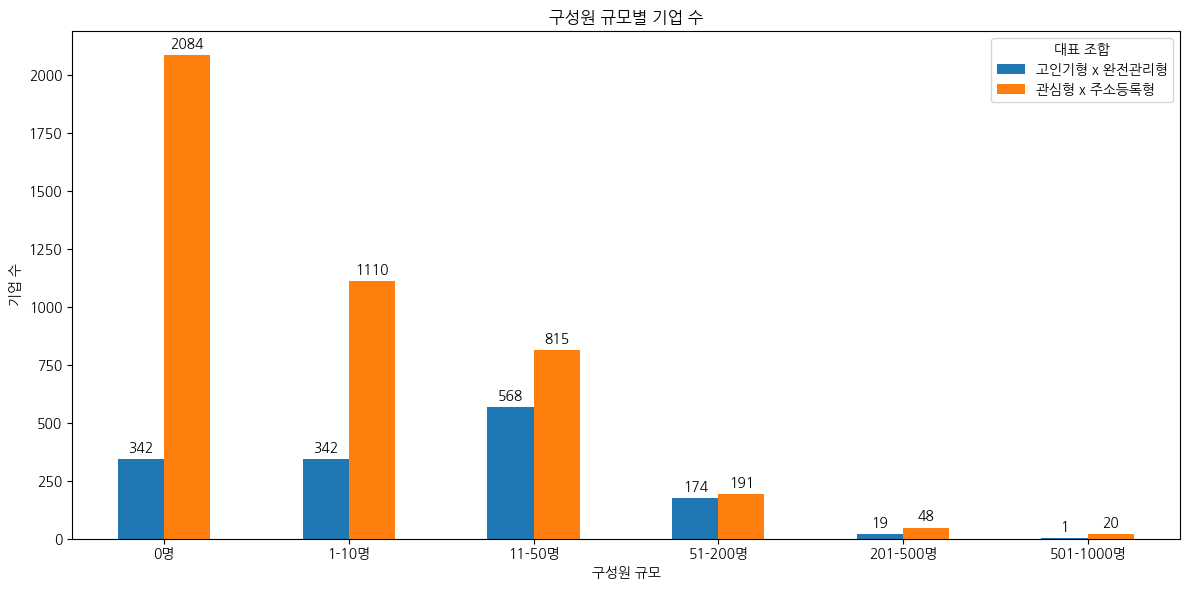

In [ ]:
company_count_df = pd.DataFrame({
    '고인기형 x 완전관리형': employee_summary_1_all['company_count'],
    '관심형 x 주소등록형': employee_summary_2_all['company_count']
})

ax = company_count_df.plot(kind='bar', figsize=(12, 6))

# 의도: 각 막대 위에 기업 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('구성원 규모별 기업 수')
plt.xlabel('구성원 규모')
plt.ylabel('기업 수')
plt.xticks(rotation=0)
plt.legend(title='대표 조합')
plt.tight_layout()
plt.show()

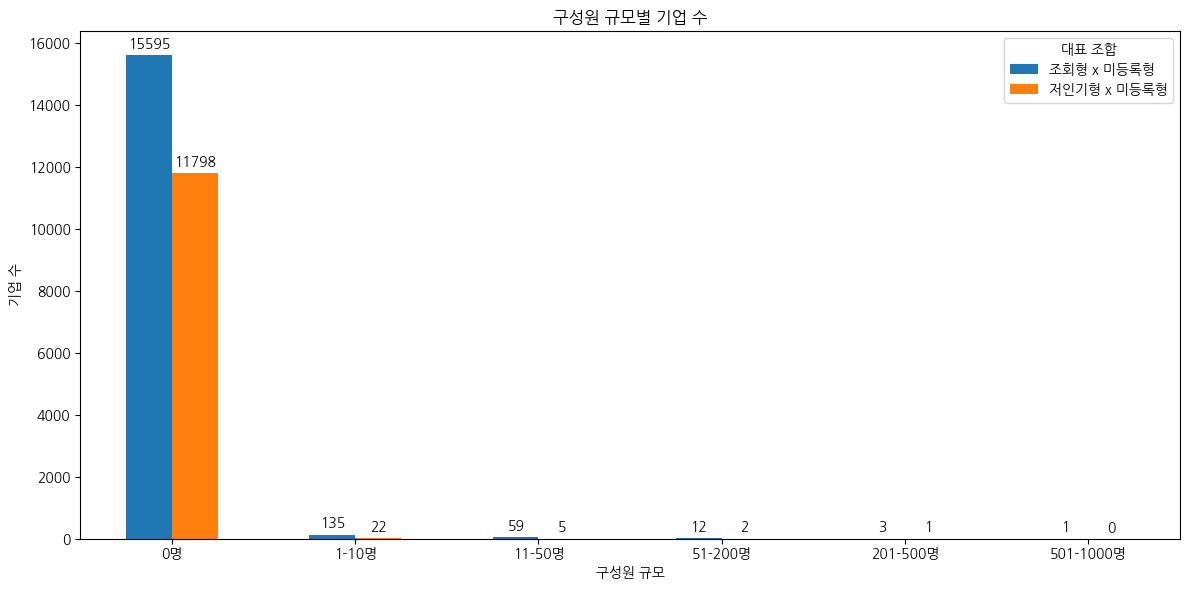

In [ ]:
company_count_df = pd.DataFrame({
    '조회형 x 미등록형': employee_summary_3_all['company_count'],
    '저인기형 x 미등록형': employee_summary_4_all['company_count']
})

ax = company_count_df.plot(kind='bar', figsize=(12, 6))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)


plt.title('구성원 규모별 기업 수')
plt.xlabel('구성원 규모')
plt.ylabel('기업 수')
plt.xticks(rotation=0)
plt.legend(title='대표 조합')
plt.tight_layout()
plt.show()

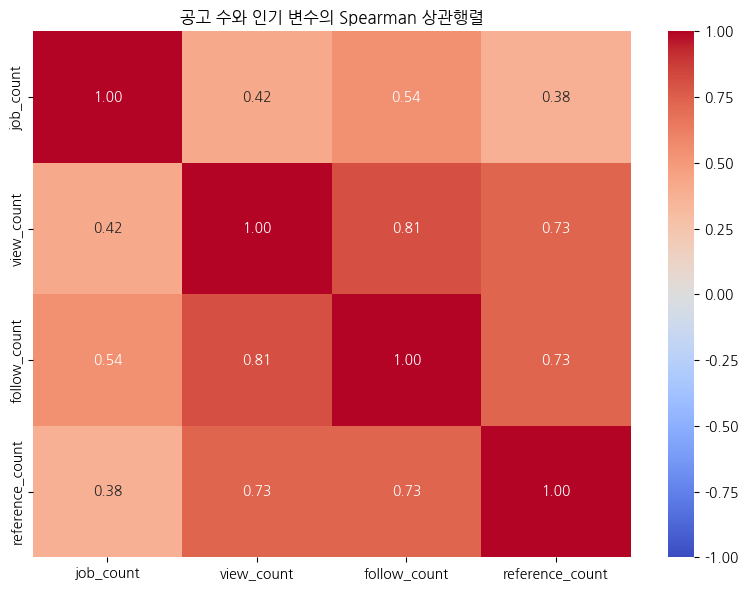

In [ ]:
# 의도: 공고 수와 인기 변수의 스피어만 상관행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))

sns.heatmap(
    pop_corr_df,
    annot=True,      # 각 칸에 상관계수 표시
    fmt='.2f',       # 소수점 둘째 자리까지 표시
    cmap='coolwarm', # 양/음 상관 구분이 잘 되는 색상
    vmin=-1,         # 상관계수 최소값
    vmax=1           # 상관계수 최대값
)

plt.title('공고 수와 인기 변수의 Spearman 상관행렬')
plt.tight_layout()
plt.show()

# C)공고 분석

In [ ]:
app_df = pd.read_csv("/content/drive/MyDrive/application.csv")
job_df = pd.read_csv("/content/drive/MyDrive/공고_clean.csv")
jobbookmark = pd.read_csv("/content/drive/MyDrive/jobbookmark.csv")
jobaddress = pd.read_csv("/content/drive/MyDrive/jobaddress.csv")
company = pd.read_csv("/content/drive/MyDrive/기업_클러스터링.csv")
companyaddress = pd.read_csv("/content/drive/MyDrive/companyaddress.csv")

In [ ]:
job_df.shape

(139764, 10)

In [ ]:
app_df.shape

(340730, 5)

In [ ]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340730 entries, 0 to 340729
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   cdate             340730 non-null  object
 1   company_uuid      340730 non-null  object
 2   job_uuid          340730 non-null  object
 3   user_uuid         340730 non-null  object
 4   application_uuid  340730 non-null  object
dtypes: object(5)
memory usage: 13.0+ MB


In [ ]:
job_df['mdate'] = pd.to_datetime(job_df['mdate'])

# 2022-01-01 이전 or 2024-01-01 이후 삭제

job = job_df[(job_df['mdate'] >= '2022-01-01') & (job_df['mdate'] < '2024-01-01')]

In [ ]:
app_df['cdate'] = pd.to_datetime(app_df['cdate'])

# 2022-01-01 이전 or 2024-01-01 이후 삭제

app = app_df[(app_df['cdate'] >= '2022-01-01') & (app_df['cdate'] < '2024-01-01')]

📊 [job 테이블] 직무 분야별 공고 분포 및 비중
▶ 전체 분석 대상 공고 수: 35,580건

 - SW 개발: 14,827건 (41.67%)
 - 기획/PM: 4,356건 (12.24%)
 - 마케팅: 4,271건 (12.00%)
 - 디자인: 4,231건 (11.89%)
 - 운영: 2,696건 (7.58%)
 - 경영지원: 2,391건 (6.72%)
 - 비즈니스: 2,098건 (5.90%)
 - HW 개발: 295건 (0.83%)
 - 게임 개발: 241건 (0.68%)
 - 투자: 174건 (0.49%)


/tmp/ipykernel_1211/3831305444.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


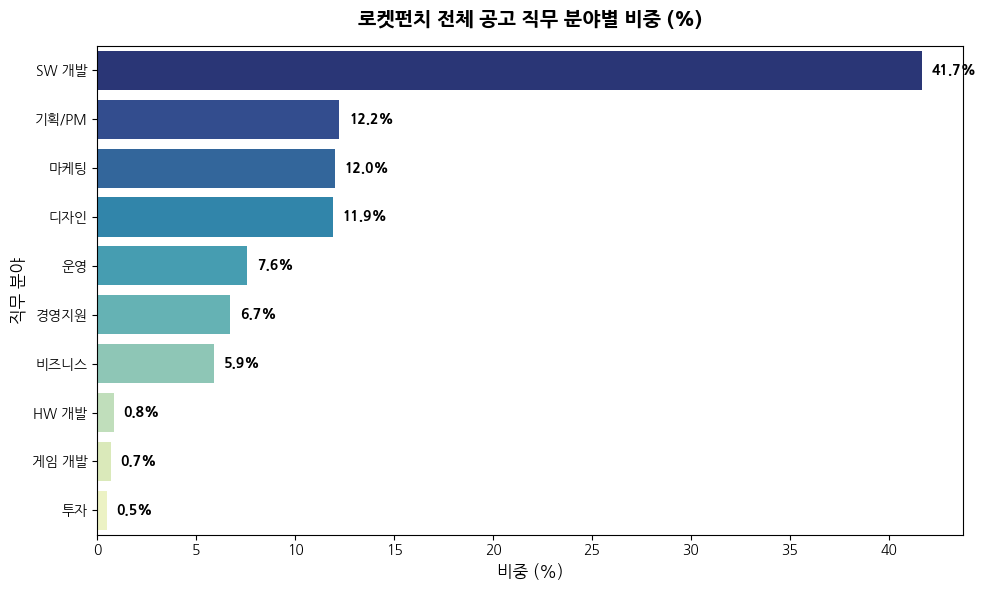

In [ ]:
# 1. job 테이블에서 job_field별 건수와 비중(%) 계산
field_counts = job['job_field'].value_counts()
field_pct = job['job_field'].value_counts(normalize=True) * 100

# 원본 컬럼명 'job_field'를 그대로 유지하면서 데이터프레임 생성!
df_field_share = pd.DataFrame({
    'count': field_counts,
    'pct': field_pct
}).reset_index().rename(columns={'index': 'job_field'})

# 2. 텍스트 결과 출력
print("==================================================")
print("📊 [job 테이블] 직무 분야별 공고 분포 및 비중")
print("==================================================")
print(f"▶ 전체 분석 대상 공고 수: {len(job):,}건\n")
for idx, row in df_field_share.iterrows():
    print(f" - {row['job_field']}: {row['count']:,}건 ({row['pct']:.2f}%)")
print("==================================================")

# 3. 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='pct',
    y='job_field',
    data=df_field_share,
    palette='YlGnBu_r'
)

plt.title('로켓펀치 전체 공고 직무 분야별 비중 (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('비중 (%)', fontsize=12)
plt.ylabel('직무 분야', fontsize=12)

# 퍼센트 수치 적어주기
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2.,
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

## 지원 2022-2023년만 뽑은 후 지원에 job left 조인



In [ ]:
app.head()

,cdate,company_uuid,job_uuid,user_uuid,application_uuid
163,2022-01-23 10:50:16,de4b3596-b4ab-47cd-b8ea-6f9e14170064,bc4a29a5-644b-479a-8280-b55c55e0f145,2ece8d7d-79b6-4522-928b-8dbae8843fab,183af487-0e1f-44c8-9253-c0335de1310a
176,2022-01-10 06:27:37,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,332926ba-57aa-4b8f-ad55-316f56911c5a
177,2022-01-10 07:19:31,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,dd4a186d-1e73-4123-8097-5c33b128ffb2
178,2022-01-10 10:59:26,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,4d5bedd2-5b63-4d05-a7b3-d74e45f61cd0
179,2022-08-21 08:48:00,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,067bb1a8-ee8f-4bd2-97fa-0e39321ab797


In [ ]:
app.shape

(92514, 5)

In [ ]:
df_merge = app.merge(job, on='job_uuid', how='left')

In [ ]:
df_merge['app_count'] = df_merge.groupby('job_uuid')['job_uuid'].transform('count')

In [ ]:
df_merge.head()

,cdate_x,company_uuid_x,job_uuid,user_uuid,application_uuid,cdate_y,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,company_uuid_y,app_count
0,2022-01-23 10:50:16,de4b3596-b4ab-47cd-b8ea-6f9e14170064,bc4a29a5-644b-479a-8280-b55c55e0f145,2ece8d7d-79b6-4522-928b-8dbae8843fab,183af487-0e1f-44c8-9253-c0335de1310a,2020-06-29 16:09:15,2022-11-07 00:06:13,SW 개발,경력,2022-07-01,2022-11-07,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,8
1,2022-01-10 06:27:37,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,332926ba-57aa-4b8f-ad55-316f56911c5a,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32
2,2022-01-10 07:19:31,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,dd4a186d-1e73-4123-8097-5c33b128ffb2,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32
3,2022-01-10 10:59:26,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,4d5bedd2-5b63-4d05-a7b3-d74e45f61cd0,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32
4,2022-08-21 08:48:00,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,067bb1a8-ee8f-4bd2-97fa-0e39321ab797,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32


### 지원 평균수, (+ 상위 25%, 20%)

In [ ]:
df_merge['app_count'].mean()

np.float64(36.122770607691805)

In [ ]:
df_merge['app_count'].max()

553

In [ ]:
df_merge['app_count'].quantile(0.75)

np.float64(34.0)

In [ ]:
df_merge['app_count'].quantile(0.8)

np.float64(44.0)

## 지원 수로 지원 많은 공고, 지원 적은 공고 나누기(상위 20%로 나눔)

In [ ]:
# 상위 20%는 '많음', 나머지는 '적음'으로 분류
quantile_80 = df_merge['app_count'].quantile(0.8)

df_merge['group'] = df_merge['app_count'].apply(lambda x: '많음' if x >= quantile_80 else '적음')

print(df_merge['group'].value_counts())

group
적음    73845
많음    18669
Name: count, dtype: int64


In [ ]:
df_merge.head()

,cdate_x,company_uuid_x,job_uuid,user_uuid,application_uuid,cdate_y,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,company_uuid_y,app_count,group
0,2022-01-23 10:50:16,de4b3596-b4ab-47cd-b8ea-6f9e14170064,bc4a29a5-644b-479a-8280-b55c55e0f145,2ece8d7d-79b6-4522-928b-8dbae8843fab,183af487-0e1f-44c8-9253-c0335de1310a,2020-06-29 16:09:15,2022-11-07 00:06:13,SW 개발,경력,2022-07-01,2022-11-07,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,8,적음
1,2022-01-10 06:27:37,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,332926ba-57aa-4b8f-ad55-316f56911c5a,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32,적음
2,2022-01-10 07:19:31,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,dd4a186d-1e73-4123-8097-5c33b128ffb2,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32,적음
3,2022-01-10 10:59:26,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,4d5bedd2-5b63-4d05-a7b3-d74e45f61cd0,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32,적음
4,2022-08-21 08:48:00,de4b3596-b4ab-47cd-b8ea-6f9e14170064,d4462e55-8358-4464-a85f-133138fbaf05,2ece8d7d-79b6-4522-928b-8dbae8843fab,067bb1a8-ee8f-4bd2-97fa-0e39321ab797,2020-10-14 09:47:24,2022-12-08 07:52:07,기획/PM,"신입,경력",2020-10-14,2022-12-31,1.0,1.0,de4b3596-b4ab-47cd-b8ea-6f9e14170064,32,적음


In [ ]:
# 그룹별 연봉공개 여부 비율 평균 비교해보기
print(df_merge.groupby('group')['can_show_salary'].mean())

# 그룹별 주로 어떤 업무분야(job_field)가 많은지 상위 5개 보기
print(df_merge.groupby('group')['job_field'].value_counts().groupby(level=0).head(5))

group
많음    0.404016
적음    0.354680
Name: can_show_salary, dtype: float64
group  job_field
많음     SW 개발        12644
       기획/PM          209
       경영지원            45
적음     SW 개발        42140
       디자인           5951
       기획/PM         5775
       마케팅           4606
       운영            2223
Name: count, dtype: int64


In [ ]:
jobaddress.head()

,name,job_uuid,address
0,NaN,a692afc9-6e7e-4781-81b3-fcee1f67182e,고양시 동구
1,NaN,a7d9b044-2728-488d-a935-e323727154ce,용인시
2,NaN,a371708e-6685-4059-941b-5fe624c4f24e,성남시
3,-,864f82ef-c240-42da-9333-0e1334652f00,서울특별시 강남구
4,F1,ba4ef2d0-ef0c-495c-921d-5a76ec97683c,안산시


In [ ]:
jobaddress.shape

(4997, 3)

## 지역별 공고 인기 정도 파악

In [ ]:
# 1. 주소 데이터에서 결측치를 제외하고 문자열로 변환
addresses = jobaddress['address'].dropna().astype(str)

# 2. 주소의 맨 앞 단어(시/도)만 추출해서 어떤 것들이 있는지 확인
print("=== 주소의 맨 앞 단어 기준 빈도수 ===")
print(addresses.apply(lambda x: x.split()[0] if len(x.split()) > 0 else '').value_counts().head(30))

# 3. 혹시 '고양시', '성남시'처럼 시/도가 생략되고 시/군/구부터 나오는 경우가 있는지 앞 두 단어까지 확인
print("\n=== 주소의 앞 두 단어 기준 빈도수 ===")
print(addresses.apply(lambda x: " ".join(x.split()[:2]) if len(x.split()) > 1 else x).value_counts().head(30))

=== 주소의 맨 앞 단어 기준 빈도수 ===
address
서울특별시    3728
성남시       290
부산광역시     106
인천광역시      88
대전광역시      87
안양시        64
수원시        62
고양시        43
용인시        35
대구광역시      35
제주시        27
광주광역시      22
부천시        20
안산시        20
화성시        19
파주시        16
울산광역시      16
서울         14
남양주시       14
하남시        13
의왕시        10
광명시         9
충청남도        9
천안시         9
평택시         8
시흥시         7
미국          7
포항시         7
서귀포시        7
아산시         7
Name: count, dtype: int64

=== 주소의 앞 두 단어 기준 빈도수 ===
address
서울특별시 강남구     1221
서울특별시 서초구      397
서울특별시 마포구      344
성남시            290
서울특별시 성동구      251
서울특별시 영등포구     206
서울특별시 중구       198
서울특별시 금천구      149
서울특별시 송파구      142
서울특별시 종로구      132
서울특별시 구로구      120
서울특별시 용산구       89
서울특별시 강서구       80
서울특별시 관악구       77
안양시             64
수원시             62
대전광역시 유성구       58
서울특별시 성북구       51
서울특별시 서대문구      51
서울특별시           47
인천광역시 연수구       42
서울특별시 광진구       41
용인시             35
부산광역시 해운대구      31
서울특별시 동대문구      29
제주시       

In [ ]:
output_text = """
서울특별시      3728
성남시         290
부산광역시       106
인천광역시        88
대전광역시        87
안양시          64
수원시          62
고양시          43
용인시          35
대구광역시        35
제주시          27
광주광역시        22
부천시          20
안산시          20
화성시          19
파주시          16
울산광역시        16
서울            14
남양주시         14
하남시          13
의왕시          10
광명시           9
충청남도          9
천안시           9
평택시           8
시흥시           7
미국            7
포항시           7
서귀포시          7
아산시           7
"""

# 2. 각 줄을 돌면서 가장 오른쪽에 있는 숫자만 뽑아서 더하기
total_sum = 0
for line in output_text.strip().split('\n'):
    if line.strip():  # 빈 줄이 아니면
        # 줄을 공백 기준으로 나누고 맨 마지막 요소(숫자)를 가져옴
        count = int(line.split()[-1])
        total_sum += count

print(f"상위 30개 지역의 총 지원 수 합계: {total_sum:,}건")

상위 30개 지역의 총 지원 수 합계: 4,799건


In [ ]:
def categorize_by_first_word(address):
    if pd.isna(address):
        return '기타/미지정'

    # 주소의 맨 앞 단어만 추출
    first_word = str(address).strip().split()[0]

    # 1. 서울
    if first_word in ['서울특별시', '서울', '서울시']:
        return '서울'

    # 2. 수도권 (경기도, 인천) - 확인된 경기 지역 시 이름 추가
    elif first_word in ['인천광역시', '인천시', '인천', '경기도', '경기',
                        '성남시', '안양시', '수원시', '고양시', '용인시',
                        '부천시', '안산시', '화성시', '파주시', '남양주시',
                        '하남시', '의왕시', '광명시', '평택시', '시흥시']:
        return '수도권(경기도)'

    # 3. 충청도 (대전, 세종, 천안, 아산 등)
    elif first_word in ['대전광역시', '대전시', '대전', '충청남도', '충청북도', '충남', '충북', '세종특별자치시', '세종시', '세종', '천안시', '아산시']:
        return '충청도'

    # 4. 경상도 (부산, 대구, 울산, 포항 등)
    elif first_word in ['부산광역시', '부산시', '부산', '대구광역시', '대구시', '대구', '울산광역시', '울산시', '울산', '경상북도', '경상남도', '경북', '경남', '포항시']:
        return '경상도'

    # 5. 전라도 (광주 및 전라 내 시/군)
    elif first_word in ['광주광역시', '광주시', '광주', '전라북도', '전라남도', '전북', '전남']:
        return '전라도'

    # 6. 강원도
    elif first_word in ['강원도', '강원특별자치도', '강원']:
        return '강원도'

    # 7. 제주시 (서귀포시 포함)
    elif first_word in ['제주시', '서귀포시', '제주도', '제주', '제주특별자치도']:
        return '제주시'

    # 미국 등 해외 및 매핑되지 않은 기타 지역
    else:
        return '기타/미지정'

# 1. jobaddress 테이블의 address 맨 앞 단어로 region 컬럼 생성
jobaddress['region'] = jobaddress['address'].apply(categorize_by_first_word)

# 2. 필요한 컬럼만 추출해서 중복 제거 (공고 하나당 지역 하나 매핑되도록)
df_region_mapping = jobaddress[['job_uuid', 'region']].drop_duplicates(subset=['job_uuid'])

# 3. 기존에 분석 중이던 df_merge에 지역 정보 left join으로 결합
df_merge = df_merge.merge(df_region_mapping, on='job_uuid', how='left')

# 4. 주소 데이터가 아예 누락된 공고는 '기타/미지정'으로 채우기
df_merge['region'] = df_merge['region'].fillna('기타/미지정')

# 5. 결과 확인! 범주가 잘 나뉘었는지 분포 출력해보기
print(df_merge['region'].value_counts())

region
기타/미지정      92393
서울            103
수도권(경기도)       18
Name: count, dtype: int64


In [ ]:
# 1. jobaddress 자체에서 지역 분류가 잘 되었는지 확인 (여기가 문제인지 체크)
print("=== 1. jobaddress 테이블 내 분류 분포 ===")
print(jobaddress['region'].value_counts())

# 2. df_region_mapping의 고유 job_uuid 개수 확인
print("\n=== 2. 매핑용 주소 데이터의 고유 공고 수 ===")
print(df_region_mapping['job_uuid'].nunique())

# 3. 결합하기 직전 df_merge의 고유 job_uuid 개수 확인
print("\n=== 3. 현재 분석 중인 df_merge의 고유 공고 수 ===")
print(df_merge['job_uuid'].nunique())

# 4. 결합했을 때 매칭되는 교집합 개수 확인
matching_uuids = set(df_merge['job_uuid']).intersection(set(df_region_mapping['job_uuid']))
print(f"\n=== 4. 양쪽 테이블에 동시에 존재하는 job_uuid 개수: {len(matching_uuids)}개 ===")

=== 1. jobaddress 테이블 내 분류 분포 ===
region
서울          3745
수도권(경기도)     722
기타/미지정       176
경상도          166
충청도          124
제주시           34
전라도           27
강원도            3
Name: count, dtype: int64

=== 2. 매핑용 주소 데이터의 고유 공고 수 ===
4898

=== 3. 현재 분석 중인 df_merge의 고유 공고 수 ===
18575

=== 4. 양쪽 테이블에 동시에 존재하는 job_uuid 개수: 15개 ===


In [ ]:
# 1. 양쪽 테이블의 job_uuid를 확실하게 문자열(str)로 바꾸고 양끝 공백 제거하기
df_merge['job_uuid'] = df_merge['job_uuid'].astype(str).str.strip()
df_region_mapping['job_uuid'] = df_region_mapping['job_uuid'].astype(str).str.strip()

# 2. 혹시 기존에 잘못 결합되어 생성된 region 컬럼이 있다면 삭제
if 'region' in df_merge.columns:
    df_merge = df_merge.drop(columns=['region'])

# 3. 다시 깨끗하게 결합(merge) 시도
df_merge = df_merge.merge(df_region_mapping, on='job_uuid', how='left')

# 4. 결합 후 매핑이 잘 되었는지 '기타/미지정' 제외하고 분포 확인해보기
print("=== 다시 결합 후 지역 분포 ===")
print(df_merge['region'].value_counts())

=== 다시 결합 후 지역 분포 ===
region
서울          103
수도권(경기도)     18
기타/미지정        2
Name: count, dtype: int64


In [ ]:
# 1. 아까 만든 함수를 companyaddress['address']에 적용해서 region 컬럼 만들기
companyaddress['region'] = companyaddress['address'].apply(categorize_by_first_word)

# 2. 기업 ID 기준 매핑 테이블 만들기 (중복 제거)
df_comp_region = companyaddress[['company_uuid', 'region']].drop_duplicates(subset=['company_uuid'])

# 3. 기존 df_merge에 혹시 region 컬럼이 남아있다면 삭제
if 'region' in df_merge.columns:
    df_merge = df_merge.drop(columns=['region'])

# 4. [수정 포인트] df_merge의 company_uuid_x를 기준으로 결합
# left_on에는 df_merge의 컬럼명, right_on에는 df_comp_region의 컬럼명 지정
df_merge = df_merge.merge(df_comp_region, left_on='company_uuid_x', right_on='company_uuid', how='left')

# 5. 주소 정보가 여전히 없는 곳은 결측치 채우기
df_merge['region'] = df_merge['region'].fillna('기타/미지정')

# 6. 최종 분포 확인
print("=== 기업 주소 기준 최종 지역 분포 ===")
print(df_merge['region'].value_counts())

=== 기업 주소 기준 최종 지역 분포 ===
region
서울          72958
수도권(경기도)     8622
기타/미지정       6002
충청도          2037
경상도          2036
전라도           571
제주시           286
강원도             2
Name: count, dtype: int64


=== 그룹별 지역 분포 비율 (%) ===
region  강원도   경상도  기타/미지정     서울  수도권(경기도)   전라도   제주시   충청도
group                                                       
많음      0.0  3.21    6.78  79.24      9.97  0.00  0.00  0.80
적음      0.0  1.94    6.41  78.77      9.16  0.77  0.39  2.56
--------------------------------------------------


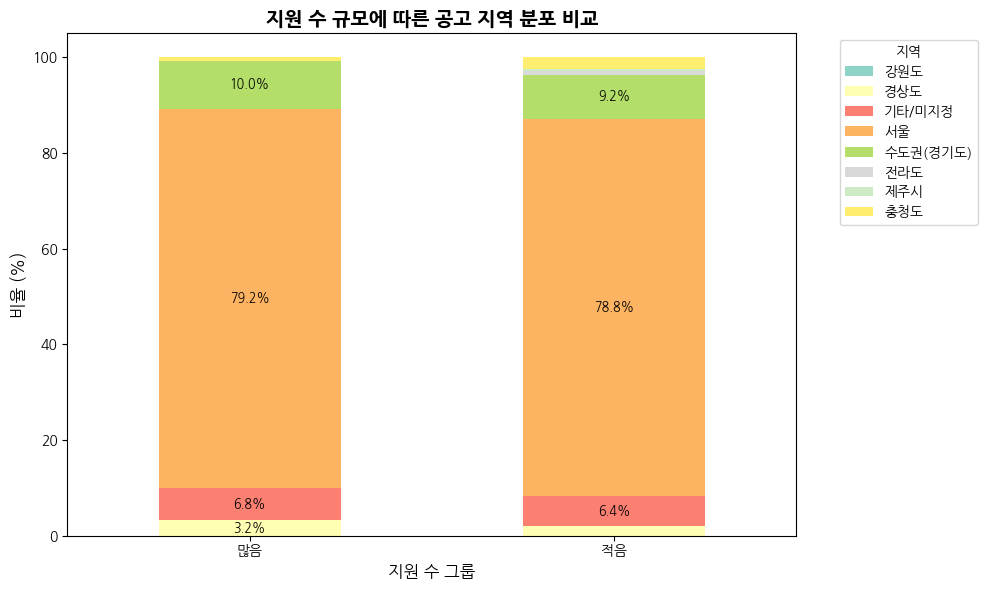

In [ ]:
# 1. 지원 수 그룹(group)과 지역(region) 간의 교차 표(Crosstab) 생성 (비율로 보기)
# normalize='index'를 주면 '많음' 그룹 안에서 각 지역이 차지하는 비율(%)을 계산
region_comparison = pd.crosstab(df_merge['group'], df_merge['region'], normalize='index') * 100
print("=== 그룹별 지역 분포 비율 (%) ===")
print(region_comparison.round(2))

print("-" * 50)

# 2. 누적 막대 그래프(Stacked Bar Chart)로 시각화하기
ax = region_comparison.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title('지원 수 규모에 따른 공고 지역 분포 비교', fontsize=14, fontweight='bold')
plt.xlabel('지원 수 그룹', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='지역', bbox_to_anchor=(1.05, 1), loc='upper left')

# 그래프 위에 비율 숫자 표시하기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 3: # 비율이 3% 이상인 것만 글자 표시 (너무 작으면 겹치니까)
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 지원 수가 상위 20%인 공고의 특징 분석

In [ ]:
# 1. 지원 수 상위 20% 공고(많음 그룹)만 필터링
df_popular = df_merge[df_merge['group'] == '많음']

print("==================================================")
print(f"📊 지원 수 상위 20% 인기 공고 종합 분석 (총 {len(df_popular):,}건 기준)")
print("==================================================")

# 1) 직무 분야 (job_field) 상위 5개
print("🔥 1. 어떤 직무가 가장 인기가 많을까? (상위 5개)")
field_counts = df_popular['job_field'].value_counts(normalize=True) * 100
for field, pct in field_counts.head(5).items():
    print(f" - {field}: {pct:.1f}%")

# 2) 경력 형태 (career_type_string) 상위 5개
print("\n💼 2. 신입 공고일까, 경력직 공고일까? (상위 5개)")
career_counts = df_popular['career_type_string'].value_counts(normalize=True) * 100
for career, pct in career_counts.head(5).items():
    print(f" - {career}: {pct:.1f}%")

# 3) 원격 근무 가능 여부 (allow_remote)
print("\n🏠 3. 원격 근무가 가능한 공고일까?")
remote_counts = df_popular['allow_remote'].value_counts(normalize=True) * 100
remote_yes = remote_counts.get(1, 0)
remote_no = remote_counts.get(0, 0)
print(f" - 원격 근무 가능: {remote_yes:.1f}%")
print(f" - 원격 근무 불가능: {remote_no:.1f}%")

# 4) 연봉 공개 여부 (can_show_salary)
print("\n💰 4. 연봉을 투명하게 공개했을까?")
salary_counts = df_popular['can_show_salary'].value_counts(normalize=True) * 100
salary_yes = salary_counts.get(1, 0)
salary_no = salary_counts.get(0, 0)
print(f" - 연봉 공개 공고: {salary_yes:.1f}%")
print(f" - 연봉 비공개 공고: {salary_no:.1f}%")

# 5) 근무 지역 분포 (region) 상위 3개
print("\n📍 5. 어느 지역에 있는 회사일까? (상위 3개)")
region_counts = df_popular['region'].value_counts(normalize=True) * 100
for reg, pct in region_counts.head(3).items():
    print(f" - {reg}: {pct:.1f}%")
print("==================================================")

📊 지원 수 상위 20% 인기 공고 종합 분석 (총 18,669건 기준)
🔥 1. 어떤 직무가 가장 인기가 많을까? (상위 5개)
 - SW 개발: 98.0%
 - 기획/PM: 1.6%
 - 경영지원: 0.3%

💼 2. 신입 공고일까, 경력직 공고일까? (상위 5개)
 - 신입,경력: 55.5%
 - 경력: 19.2%
 - 신입,경력,인턴: 16.2%
 - 신입: 7.1%
 - 신입,인턴: 1.2%

🏠 3. 원격 근무가 가능한 공고일까?
 - 원격 근무 가능: 20.2%
 - 원격 근무 불가능: 79.8%

💰 4. 연봉을 투명하게 공개했을까?
 - 연봉 공개 공고: 40.4%
 - 연봉 비공개 공고: 59.6%

📍 5. 어느 지역에 있는 회사일까? (상위 3개)
 - 서울: 79.2%
 - 수도권(경기도): 10.0%
 - 기타/미지정: 6.8%


/tmp/ipykernel_1211/90830085.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_field', y='pct', data=df_field, ax=axes[0, 0], palette='Oranges_r')
/tmp/ipykernel_1211/90830085.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pct', y='career_type_string', data=df_career, ax=axes[0, 1], palette='Purples_r')
/tmp/ipykernel_1211/90830085.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='pct', data=df_region, ax=axes[1, 1], palette='GnBu_r')


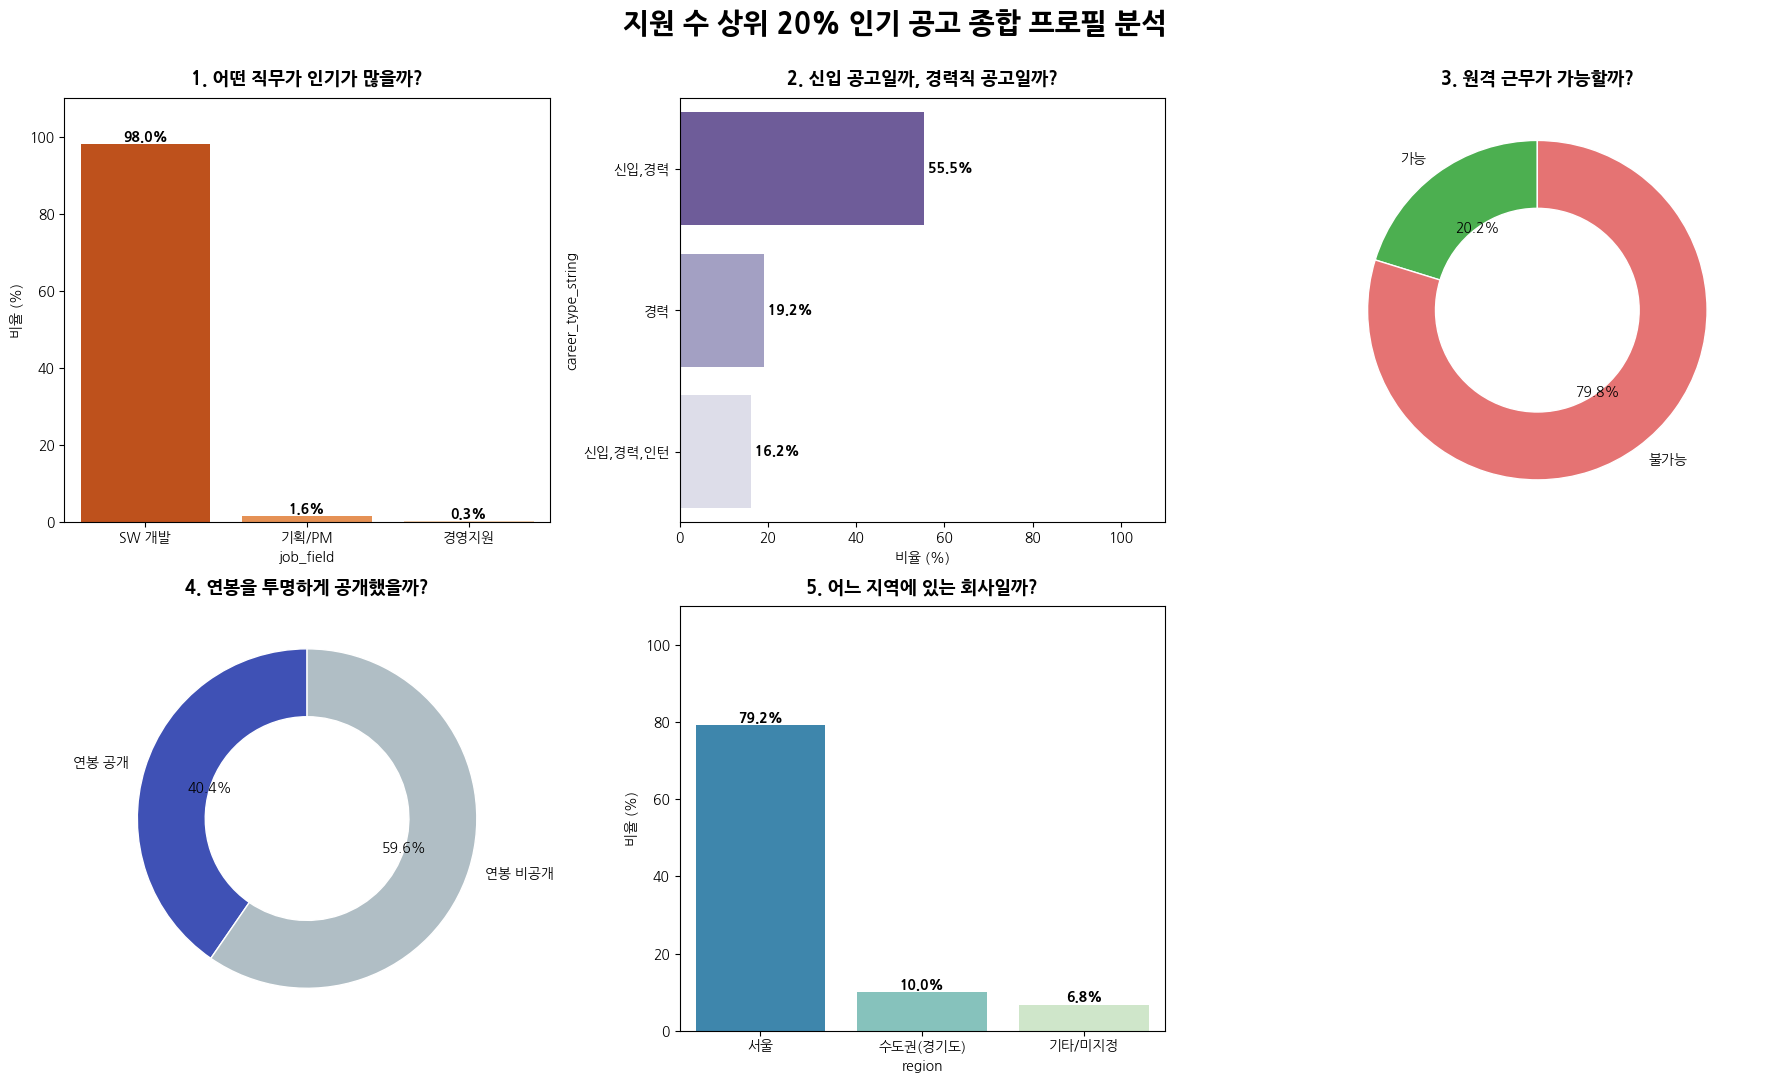

In [ ]:
# 1. % 단위로 변경
df_field = (df_popular['job_field'].value_counts(normalize=True) * 100).head(4).reset_index(name='pct')
df_career = (df_popular['career_type_string'].value_counts(normalize=True) * 100).head(3).reset_index(name='pct')
df_region = (df_popular['region'].value_counts(normalize=True) * 100).head(3).reset_index(name='pct')

# 원격 근무 및 연봉 공개 비율 데이터 (기존 유지)
remote_series = df_popular['allow_remote'].value_counts(normalize=True) * 100
remote_data = [remote_series.get(1.0, 0), remote_series.get(0.0, 0)]

salary_series = df_popular['can_show_salary'].value_counts(normalize=True) * 100
salary_data = [salary_series.get(1.0, 0), salary_series.get(0.0, 0)]


# 2. 도화지 설정 (2행 3열 구조)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('지원 수 상위 20% 인기 공고 종합 프로필 분석', fontsize=20, fontweight='bold', y=0.98)

# --------------------------------------------------
# [1] 인기 직무 Top 4 (세로 막대그래프)
# --------------------------------------------------
sns.barplot(x='job_field', y='pct', data=df_field, ax=axes[0, 0], palette='Oranges_r')
axes[0, 0].set_title('1. 어떤 직무가 인기가 많을까?', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('job_field')
axes[0, 0].set_ylabel('비율 (%)')
axes[0, 0].set_ylim(0, 110) # 텍스트가 잘리지 않게 y축 여유 공간 확보
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# --------------------------------------------------
# [2] 경력 형태 Top 3 (가로 막대그래프)
# --------------------------------------------------
sns.barplot(x='pct', y='career_type_string', data=df_career, ax=axes[0, 1], palette='Purples_r')
axes[0, 1].set_title('2. 신입 공고일까, 경력직 공고일까?', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('비율 (%)')
axes[0, 1].set_ylabel('career_type_string')
axes[0, 1].set_xlim(0, 110) # 텍스트가 잘리지 않게 x축 여유 공간 확보
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f" {p.get_width():.1f}%", (p.get_width(), p.get_y() + p.get_height()/2.),
                         ha='left', va='center', fontsize=10, fontweight='bold')

# --------------------------------------------------
# [3] 원격 근무 가능 여부 (도넛형 파이차트)
# --------------------------------------------------
axes[0, 2].pie(remote_data, labels=['가능', '불가능'], autopct='%1.1f%%', startangle=90,
               colors=['#4CAF50', '#E57373'], wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0, 2].set_title('3. 원격 근무가 가능할까?', fontsize=13, fontweight='bold', pad=10)

# --------------------------------------------------
# [4] 연봉 투명성 여부 (도넛형 파이차트)
# --------------------------------------------------
axes[1, 0].pie(salary_data, labels=['연봉 공개', '연봉 비공개'], autopct='%1.1f%%', startangle=90,
               colors=['#3F51B5', '#B0BEC5'], wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1, 0].set_title('4. 연봉을 투명하게 공개했을까?', fontsize=13, fontweight='bold', pad=10)

# --------------------------------------------------
# [5] 근무 지역 분포 Top 3 (세로 막대그래프)
# --------------------------------------------------
sns.barplot(x='region', y='pct', data=df_region, ax=axes[1, 1], palette='GnBu_r')
axes[1, 1].set_title('5. 어느 지역에 있는 회사일까?', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('region')
axes[1, 1].set_ylabel('비율 (%)')
axes[1, 1].set_ylim(0, 110) # y축 여유 공간 확보
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# --------------------------------------------------
# [6] 빈 칸 처리 (마지막 서브플롯은 비워두기)
# --------------------------------------------------
axes[1, 2].axis('off')

# 레이아웃 간격 조정 후 출력
plt.tight_layout()
plt.subplots_adjust(top=0.90) # 제목 공간 확보
plt.show()

### 공고 수명 & 타이밍 분석

In [ ]:
# 날짜 컬럼들을 datetime 타입으로 변환 (에러 방지를 위해 errors='coerce' 설정)
df_merge['start_date'] = pd.to_datetime(df_merge['start_date'], errors='coerce')
df_merge['end_date'] = pd.to_datetime(df_merge['end_date'], errors='coerce')

# 지원서 제출 시간 (application 테이블의 cdate)
df_merge['cdate_x'] = pd.to_datetime(df_merge['cdate_x'], errors='coerce')

# 공고 등록 날짜 (job 테이블의 cdate)
df_merge['cdate_y'] = pd.to_datetime(df_merge['cdate_y'], errors='coerce')


# [확인용] 제대로 변환되었는지 데이터 타입 출력하기
print(df_merge[['start_date', 'end_date', 'cdate_x', 'cdate_y']].dtypes)

start_date    datetime64[ns]
end_date      datetime64[ns]
cdate_x       datetime64[ns]
cdate_y       datetime64[ns]
dtype: object


In [ ]:
# 1. 원본 job 테이블의 날짜 컬럼들을 datetime 타입으로 변환
job['start_date'] = pd.to_datetime(job['start_date'], errors='coerce')
job['end_date'] = pd.to_datetime(job['end_date'], errors='coerce')

# 2. 공고별 모집 기간(수명) 계산 (단위: 일)
job['job_lifespan'] = (job['end_date'] - job['start_date']).dt.days

# 3. 마감일이 시작일보다 앞서는 데이터나 날짜가 없는 결측치 제외 (정상 공고만 필터링)
job_valid = job[job['job_lifespan'] >= 0].copy()

# 4. 요청하신 5개 구간으로 자르기 (bins와 labels 설정)
# 60일(1달)을 초과하는 모든 공고는 '상시채용'으로 분류되도록 최댓값을 9999로 지정
bins = [-1, 7, 14, 30, 60, 9999]
labels = ['1주일 이하', '2주 이하', '1달 이하', '2달 이하', '상시채용']

job_valid['recruitment_period'] = pd.cut(job_valid['job_lifespan'],
                                         bins=bins,
                                         labels=labels)

print("==================================================")
print("📦 [job 테이블] 공고 모집 기간별 전체 분포")
print("==================================================")

# 5. 전체 공고 중 각 모집 기간이 차지하는 건수와 비중(%) 출력
job_counts = job_valid['recruitment_period'].value_counts()
job_pct = job_valid['recruitment_period'].value_counts(normalize=True) * 100

print(f"▶ 분석 대상 공고 수: {len(job_valid):,}건 (날짜 정상 데이터 기준)\n")
print("■ 모집 기간별 공고 건수 및 비중:")
for label in labels:
    print(f" - {label}: {job_counts[label]:,}건 ({job_pct[label]:.2f}%)")
print("==================================================")

📦 [job 테이블] 공고 모집 기간별 전체 분포
▶ 분석 대상 공고 수: 35,580건 (날짜 정상 데이터 기준)

■ 모집 기간별 공고 건수 및 비중:
 - 1주일 이하: 9,790건 (31.43%)
 - 2주 이하: 3,058건 (9.82%)
 - 1달 이하: 10,489건 (33.68%)
 - 2달 이하: 3,289건 (10.56%)
 - 상시채용: 4,521건 (14.52%)


/tmp/ipykernel_1211/2713996943.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  job['start_date'] = pd.to_datetime(job['start_date'], errors='coerce')
/tmp/ipykernel_1211/2713996943.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  job['end_date'] = pd.to_datetime(job['end_date'], errors='coerce')
/tmp/ipykernel_1211/2713996943.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [ ]:
# 1. 공고 수명(게재 기간) 계산
df_merge['job_lifespan'] = (df_merge['end_date'] - df_merge['start_date']).dt.days

# 2. 공고별 고유 데이터셋 생성
df_job_lifespan = df_merge.drop_duplicates(subset=['job_uuid']).copy()


# 3. 요청한 5개 구간으로 자르기 (bins와 labels 설정)
# -1부터 시작해야 0일(당일 마감) 공고까지 포함
# 60일(2달)을 초과하는 모든 공고는 '상시채용' 그룹으로 묶기 위해 최댓값을 9999로 설정
bins = [-1, 7, 14, 30, 60, 9999]
labels = ['1주일 이하', '2주 이하', '1달 이하', '2달 이하', '상시채용']

df_job_lifespan['recruitment_period'] = pd.cut(df_job_lifespan['job_lifespan'],
                                              bins=bins,
                                              labels=labels)

print("==================================================")
print("📦 공고 모집 기간별 분포 및 평균 지원 수")
print("==================================================")

# 5. 각 모집 기간별 공고가 몇 개나 있는지 확인 (비율 포함)
print("■ [분석 A] 모집 기간별 공고 건수 및 비중:")
period_counts = df_job_lifespan['recruitment_period'].value_counts()
period_pct = df_job_lifespan['recruitment_period'].value_counts(normalize=True) * 100
for label in labels:
    print(f" - {label}: {period_counts[label]:,}건 ({period_pct[label]:.1f}%)")

print("\n" + "-"*50 + "\n")

# 6. 모집 기간별 평균 지원 수 확인
print("■ [분석 B] 모집 기간별 평균 지원 수:")
print(df_job_lifespan.groupby('recruitment_period', observed=False)['app_count'].mean().round(2))
print("==================================================")

📦 공고 모집 기간별 분포 및 평균 지원 수
■ [분석 A] 모집 기간별 공고 건수 및 비중:
 - 1주일 이하: 4,670건 (33.6%)
 - 2주 이하: 954건 (6.9%)
 - 1달 이하: 3,861건 (27.8%)
 - 2달 이하: 1,648건 (11.9%)
 - 상시채용: 2,770건 (19.9%)

--------------------------------------------------

■ [분석 B] 모집 기간별 평균 지원 수:
recruitment_period
1주일 이하    5.06
2주 이하     2.95
1달 이하     3.05
2달 이하     3.58
상시채용      6.46
Name: app_count, dtype: float64


In [ ]:
# 1. 공고 수명(게재 기간) 계산 (단위: 일)
df_merge['job_lifespan'] = (df_merge['end_date'] - df_merge['start_date']).dt.days

# 2. 공고별로 중복 없는 데이터셋 만들기
# (공고 자체의 수명과 총 지원수를 비교해야 하므로 중복을 제거해줘야 정확)
df_job_lifespan = df_merge.drop_duplicates(subset=['job_uuid'])

# 3. 게재 기간과 총 지원 수(app_count)의 상관계수 구하기
correlation = df_job_lifespan['job_lifespan'].corr(df_job_lifespan['app_count'])
print(f"■ 공고 게재 기간과 지원 수의 상관계수: {correlation:.4f}")
print("   (1에 가까울수록 비례, -1에 가까울수록 반비례, 0에 가까우면 관계없음)")

■ 공고 게재 기간과 지원 수의 상관계수: 0.0471
   (1에 가까울수록 비례, -1에 가까울수록 반비례, 0에 가까우면 관계없음)


In [ ]:
# 1. 공고별 고유 데이터셋 생성 (공고 등록 시점당 총 지원수를 봐야 하므로 복사본 생성)
df_job_timing = df_merge.drop_duplicates(subset=['job_uuid']).copy()

# 2. cdate_y(공고 등록일)에서 요일(영어) 및 월 추출
df_job_timing['reg_month'] = df_job_timing['cdate_y'].dt.month
df_job_timing['reg_day_of_week'] = df_job_timing['cdate_y'].dt.day_name()

# 3. 요일이 월요일부터 일요일 순서로 예쁘게 정렬되도록 카테고리 순서 지정
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_job_timing['reg_day_of_week'] = pd.Categorical(df_job_timing['reg_day_of_week'], categories=day_order, ordered=True)

print("==================================================")
print("📅 2단계: 공고 등록 시점(요일/월) 타이밍 분석")
print("==================================================")

# 4. 등록 요일별 평균 지원 수 출력
print("■ [분석 A] 공고 등록 요일별 평균 지원 수:")
print(df_job_timing.groupby('reg_day_of_week', observed=False)['app_count'].mean().round(2))

print("\n" + "-"*50 + "\n")

# 5. 등록 월별 평균 지원 수 출력
print("■ [분석 B] 공고 등록 월별(1월~12월) 평균 지원 수:")
print(df_job_timing.groupby('reg_month' , observed=False)['app_count'].mean().round(2))
print("==================================================")

📅 2단계: 공고 등록 시점(요일/월) 타이밍 분석
■ [분석 A] 공고 등록 요일별 평균 지원 수:
reg_day_of_week
Monday       4.74
Tuesday      4.56
Wednesday    4.66
Thursday     4.56
Friday       4.47
Saturday     6.67
Sunday       5.26
Name: app_count, dtype: float64

--------------------------------------------------

■ [분석 B] 공고 등록 월별(1월~12월) 평균 지원 수:
reg_month
1.0     4.47
2.0     5.35
3.0     4.57
4.0     4.37
5.0     4.10
6.0     4.39
7.0     4.58
8.0     4.53
9.0     4.33
10.0    4.82
11.0    5.16
12.0    5.07
Name: app_count, dtype: float64


/tmp/ipykernel_1211/1043832138.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1211/1043832138.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


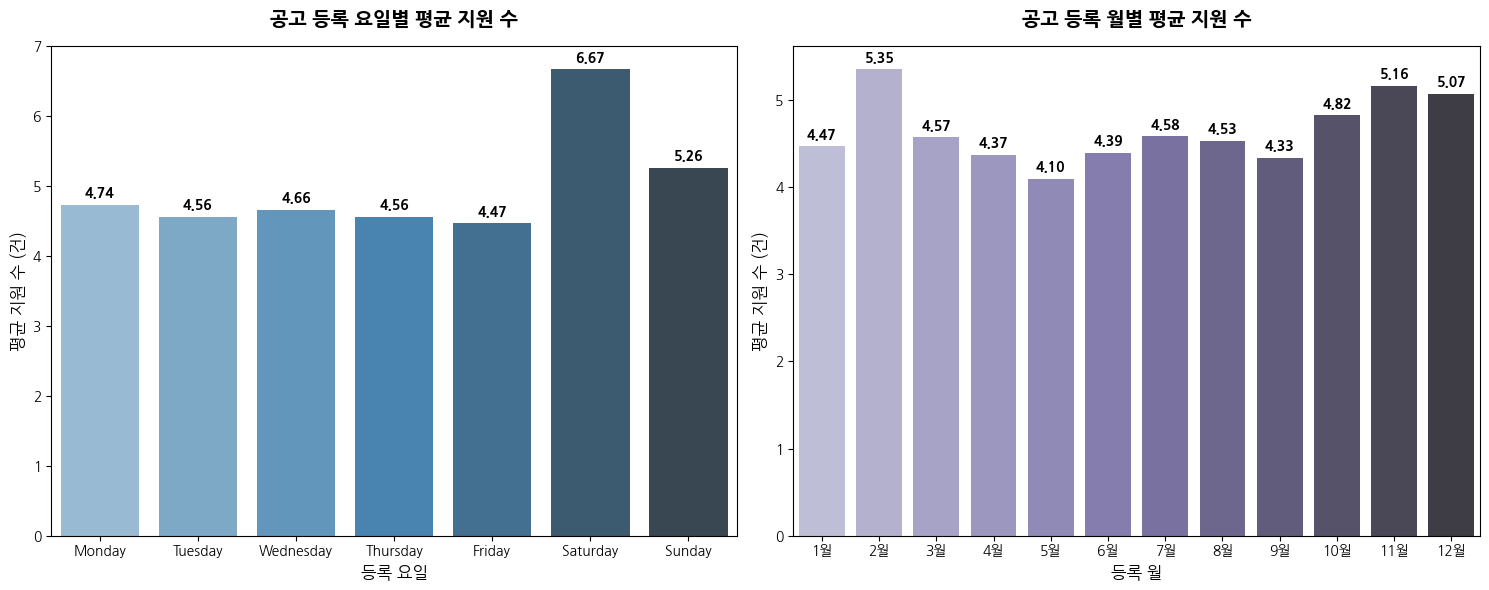

In [ ]:
df_weekday = df_job_timing.groupby('reg_day_of_week', observed=False)['app_count'].mean().reset_index()
df_month = df_job_timing.groupby('reg_month', observed=False)['app_count'].mean().reset_index()

# 월 데이터를 소수점 없는 정수형(int)으로 바꾸고 '월' 글자 붙이기
# 결측치(NaN)가 있으면 정수 변환 시 에러가 나므로 dropna() 후 변환
df_month = df_month.dropna(subset=['reg_month']).copy()
df_month['reg_month'] = df_month['reg_month'].astype(int).astype(str) + '월'

# 3. 도화지 그리기 (1행 2열 구조)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------------------------
# [왼쪽 그래프] 요일별 평균 지원 수
# --------------------------------------------------
sns.barplot(
    x='reg_day_of_week',
    y='app_count',
    data=df_weekday,
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('공고 등록 요일별 평균 지원 수', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('등록 요일', fontsize=12)
axes[0].set_ylabel('평균 지원 수 (건)', fontsize=12)

# 요일 그래프 막대 위 숫자 표시
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 8),
                     textcoords='offset points',
                     fontsize=10, fontweight='bold', color='black')

# --------------------------------------------------
# [오른쪽 그래프] 월별 평균 지원 수
# --------------------------------------------------
sns.barplot(
    x='reg_month',
    y='app_count',
    data=df_month,
    ax=axes[1],
    palette='Purples_d'
)
axes[1].set_title('공고 등록 월별 평균 지원 수', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('등록 월', fontsize=12)
axes[1].set_ylabel('평균 지원 수 (건)', fontsize=12)

# 월별 그래프 막대 위 숫자 표시
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 8),
                     textcoords='offset points',
                     fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [ ]:
# 1. datetime 상태에서 바로 뺀 뒤에 .dt.days로 일수만 추출
df_merge['days_before_deadline'] = (df_merge['end_date'] - df_merge['cdate_x']).dt.days

# 2. 마감일 정보가 없거나, 마감 이후에 들어온 데이터 제외 (0일 이상 남은 정상 지원만)
df_deadline_analysis = df_merge[df_merge['days_before_deadline'] >= 0].copy()

print("==================================================")
print("⏳ 3단계: 마감 임박 효과 (D-Day 분석)")
print("==================================================")

# 3. 마감 D-Minus 몇 일에 가장 지원을 많이 하는지 상위 10개 일수 보기
print("■ [분석 A] 가장 지원이 몰리는 마감 전 일수 (상위 10개):")
print(df_deadline_analysis['days_before_deadline'].value_counts().head(10))

print("\n" + "-"*50 + "\n")

# 4. 구간별 범주화 함수
def categorize_deadline(days):
    if days == 0:
        return 'D-Day (마감 당일)'
    elif days <= 3:
        return 'D-1 ~ D-3 (마감 임박)'
    elif days <= 7:
        return 'D-4 ~ D-7 (1주일 전)'
    else:
        return '상시 채용 기간 (일주일 초과)'

df_deadline_analysis['deadline_status'] = df_deadline_analysis['days_before_deadline'].apply(categorize_deadline)

# 5. 마감 시점 구간별 실제 지원 건수 비율 출력
print("■ [분석 B] 마감 시점 구간별 실제 지원 건수 비율 (%):")
print((df_deadline_analysis['deadline_status'].value_counts(normalize=True) * 100).round(2))
print("==================================================")

⏳ 3단계: 마감 임박 효과 (D-Day 분석)
■ [분석 A] 가장 지원이 몰리는 마감 전 일수 (상위 10개):
days_before_deadline
0.0     1564
1.0     1131
28.0    1117
7.0     1110
4.0     1100
2.0     1073
6.0     1068
3.0     1029
5.0     1017
9.0      992
Name: count, dtype: int64

--------------------------------------------------

■ [분석 B] 마감 시점 구간별 실제 지원 건수 비율 (%):
deadline_status
상시 채용 기간 (일주일 초과)    88.25
D-4 ~ D-7 (1주일 전)     5.55
D-1 ~ D-3 (마감 임박)     4.18
D-Day (마감 당일)         2.02
Name: proportion, dtype: float64


# A/B 테스트: '가장 인기있는 공고' 클릭률 개선하기


## 최근 6개월 '가장 인기있는 공고' 클릭률 보기

In [ ]:
# 구글 드라이브 내 폴더 경로 고정
base_dir = '/content/drive/MyDrive/log_2023_clean'

# 하반기 파일 6개의 전체 경로
explicit_files = [
    f"{base_dir}/log_2023_clean_07.csv",
    f"{base_dir}/log_2023_clean_08.csv",
    f"{base_dir}/log_2023_clean_09.csv",
    f"{base_dir}/log_2023_clean_10.csv",
    f"{base_dir}/log_2023_clean_11.csv",
    f"{base_dir}/log_2023_clean_12.csv"
]

# on_bad_lines='skip'을 넣어 형식이 망가진 줄(74061번째 줄 등)은 건너뛰고 읽어옵니다.
df_list = [pd.read_csv(f, on_bad_lines='skip') for f in explicit_files]

# 하나로 합치기
recent_6months = pd.concat(df_list, ignore_index=True)

print(f"✅ 통합 완료! 총 행 수: {recent_6months.shape[0]}개")

/tmp/ipykernel_1760/3969102067.py:15: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f, on_bad_lines='skip') for f in explicit_files]


✅ 통합 완료! 총 행 수: 2387271개


In [ ]:
# 1. 불필요한 컬럼 삭제하기
recent_6months = recent_6months.drop(columns= ['date', 'response_code', 'method'])

# 2. 결과 확인하기 (상위 5개 데이터와 남은 컬럼 목록 출력)
print("✅ 컬럼 삭제 완료!")
print("\n=== 현재 남은 컬럼 목록 ===")
print(recent_6months.columns.tolist())

✅ 컬럼 삭제 완료!

=== 현재 남은 컬럼 목록 ===
['user_uuid', 'URL', 'timestamp']


In [ ]:
recent_6months.head()

,user_uuid,URL,timestamp
0,5ce8f5ca-3476-4623-a60c-00c98eef3b62,companies/company_id,2023-07-02 12:33:10.191905 UTC
1,5ce8f5ca-3476-4623-a60c-00c98eef3b62,suggest?q=,2023-07-02 12:37:24.841725 UTC
2,5ce8f5ca-3476-4623-a60c-00c98eef3b62,companies/company_id,2023-07-02 12:36:40.148643 UTC
3,5ce8f5ca-3476-4623-a60c-00c98eef3b62,companies/company_id,2023-07-02 12:37:20.307064 UTC
4,5ce8f5ca-3476-4623-a60c-00c98eef3b62,suggest?q=epdlxj,2023-07-02 12:37:27.58173 UTC


In [ ]:
# 1. 현재 데이터에 가장 많이 등장하는 URL 상위 30개 찍어보기
print("=== 가장 많이 수집된 URL 상위 30개 ===")
print(recent_6months['URL'].value_counts().head(30))

=== 가장 많이 수집된 URL 상위 30개 ===
URL
api/users/id/template                       187362
jobs/id/id_title                            160127
@user_id                                    132836
api/recommend_specialty                     123625
api/jobs/id/other_jobs                       92324
companies/company_id/jobs                    63506
api/companies/id/view                        61412
api/current_guided_action/id                 54866
companies/company_id                         54389
api/users/id/experience/form?type=apply      52473
jobs                                         51656
api/jobs/id/other_jobs?offset=0&limit=5      49842
@user_id/applications                        47628
api/jobs/job_title?job=1                     33122
jobs/id/apply/step1                          31010
suggest?q=                                   27219
jobs/id/apply/step2                          26767
api/jobs/id/apply/step2                      24316
api/jobs/id/apply/step1                      2387

In [ ]:
result = recent_6months[recent_6months['URL'].str.contains('template_oneclick')]
print(result)

                                    user_uuid                            URL  \
427      d1ea49d3-a0b5-4388-888a-dc7232f5e1a2  api/jobs/id/template_oneclick   
428      d1ea49d3-a0b5-4388-888a-dc7232f5e1a2  api/jobs/id/template_oneclick   
1108     57e28997-6198-4df7-aab9-f33fb1ceee1c  api/jobs/id/template_oneclick   
1109     57e28997-6198-4df7-aab9-f33fb1ceee1c  api/jobs/id/template_oneclick   
1149     57e28997-6198-4df7-aab9-f33fb1ceee1c  api/jobs/id/template_oneclick   
...                                       ...                            ...   
2384844  fbe3c2f6-92ab-47a9-8c9a-93d6bf88db5c  api/jobs/id/template_oneclick   
2386110  1cbcce95-0aac-45b8-b1df-cc9dd60eec8f  api/jobs/id/template_oneclick   
2386153  44625af3-9f7f-49e3-802c-4aa683733713  api/jobs/id/template_oneclick   
2386586  2bf41c96-9898-458d-ab7a-ca4a102563a6  api/jobs/id/template_oneclick   
2387089  9619197d-f6c3-4ea4-bbc6-477b40d02c3e  api/jobs/id/template_oneclick   

                              timestamp

CTR = (클릭수/노출수) *100


노출 수 (Denominator): 홈 위젯 배너가 노출된 유니크 유저 수 (URL == 'api/jobs/widget/widget_templates')

클릭 수 (Numerator): 공고 상세 페이지에 진입한 유니크 유저 수 (URL == 'api/jobs/job_title')

### 노출 / *클릭*

원클릭 / id_title & job_title

In [ ]:
# 0. timestamp 컬럼을 날짜 형식으로 변환 (불량 데이터는 NaT로 변환)
recent_6months['timestamp'] = pd.to_datetime(recent_6months['timestamp'], errors='coerce')

# 1. 1단계: 배너 노출(A) - 'template_oneclick'이 포함된 로그의 유저별 최초 시점 구하기
step_A = recent_6months[recent_6months['URL'].str.contains('template_oneclick', na=False)]
first_A = step_A.groupby('user_uuid')['timestamp'].min().reset_index(name='timestamp_A')

# 2. 2단계: 공고 클릭(B) - 가장 지배적인 상세페이지 주소인 'id_title' 최초 진입 시점 구하기
step_B = recent_6months[
    recent_6months['URL'].str.contains('id_title', na=False) |
    recent_6months['URL'].str.contains('job_title', na=False)
]
first_B = step_B.groupby('user_uuid')['timestamp'].min().reset_index(name='timestamp_B')


# 3. 두 데이터 병합 (Merge)
funnel_merge = pd.merge(first_A, first_B, on='user_uuid', how='left')

# 4. 비교 대상 컬럼들을 날짜 형식으로 재고정 및 결측치 처리
funnel_merge['timestamp_A'] = pd.to_datetime(funnel_merge['timestamp_A'], errors='coerce')
funnel_merge['timestamp_B'] = pd.to_datetime(funnel_merge['timestamp_B'], errors='coerce')

# 5. 분모 가드: 1단계 시점(timestamp_A)이 깨졌거나 비어있는 행은 완전히 제외
funnel_merge = funnel_merge.dropna(subset=['timestamp_A'])

# 6. 전체 분모 (인기 공고 배너를 본 총 유니크 유저 수)
total_impression_users = funnel_merge['user_uuid'].nunique()

# 7. 시간 순서 비교 (배너를 본 시점 A보다 공고를 클릭한 시점 B가 더 미래인 진짜 순방향 유저만 필터링)
true_click_users_df = funnel_merge[funnel_merge['timestamp_B'] > funnel_merge['timestamp_A']]
total_true_click_users = true_click_users_df['user_uuid'].nunique()

# 8. 최종 순방향 전환율(CTR) 계산
if total_impression_users > 0:
    funnel_ctr = (total_true_click_users / total_impression_users) * 100
else:
    funnel_ctr = 0.0

# 9. 결과 리포트 출력
print("====================================================")
print("'가장 인기있는 공고' 데이터 기반 최종 퍼널 분석")
print("====================================================")
print(f"• 1단계 인기 공고 배너 노출 유저 (Impression) : {total_impression_users:,} 명")
print(f"• 2단계 배너 확인 후 공고 진입 유저 (Click)      : {total_true_click_users:,} 명")
print(f"최근 6개월 기준 기본 진입률 (Baseline CTR) : {funnel_ctr:.2f} %")
print("====================================================")

'가장 인기있는 공고' 데이터 기반 최종 퍼널 분석
• 1단계 인기 공고 배너 노출 유저 (Impression) : 2,541 명
• 2단계 배너 확인 후 공고 진입 유저 (Click)      : 18 명
최근 6개월 기준 기본 진입률 (Baseline CTR) : 0.71 %


In [ ]:
# 두 주소의 순수 방문 유저 수 눈으로 직접 비교해보기
print("widget_templates 유저 수:", recent_6months[recent_6months['URL'].str.contains('widget_templates', na=False)]['user_uuid'].nunique())
print("template_oneclick 유저 수:", recent_6months[recent_6months['URL'].str.contains('template_oneclick', na=False)]['user_uuid'].nunique())

widget_templates 유저 수: 127
template_oneclick 유저 수: 2541
